# Lesson164 · Griffin

Standalone lab: three live mechanisms, a complete visible model, cached real checkpoint attention and the pinned full release experiment. Default lane needs CPU PyTorch/NumPy only. No paid service is contacted. Author preparation is not learner mastery. Website links become available after publication.

<div class="lab-access"><strong>Lesson package</strong> · <a href="https://avistian.github.io/relational/labs/0164-griffin-graph-centric-rdb-fm.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0164-griffin-graph-centric-rdb-fm.html">Executed author preview</a> · <a href="https://avistian.github.io/relational/labs/solutions/0164-griffin-graph-centric-rdb-fm.ipynb">Solution</a><br><a href="https://avistian.github.io/relational/reference/griffin.html">Quick reference</a> · <a href="https://avistian.github.io/relational/labs/l164-reproduction.md">Full reproduction contract</a> · <a href="https://avistian.github.io/relational/labs/evidence/l164/report.md">Evidence and budget decision</a></div>

## 1 · One row need not have one permanent summary

**Your tangible win:** trace a Griffin prediction from individual cells through relational messages, then distinguish an architecture check from evidence that pretraining transfers.

**Reading route.** First trace one row through the architecture and the two-number attention example. Then trace the relation maximum. Read the training stages and reproduction protocol after you can explain those two operations; reserve the notebook for a separate practice session.

[Lesson 163](https://avistian.github.io/relational/lessons/0163-lm-encoders-for-rows.html) made one vector from a row before fitting a prediction head. That leaves a bottleneck: a fixed summary must preserve everything a later task might need. Predicting a driver's finishing status and predicting qualifying performance need not ask the same question of a row. Griffin keeps the **cell vectors** available and lets the graph model read them again as its task and relational context evolve.

Recall the [GNN–tabular stack](https://avistian.github.io/relational/lessons/0131-gnn-tabular-stack.html): an encoder represents each row, message passing adds related rows, and a head predicts a task. Griffin shares these operations across schemas and tasks. A shared interface makes transfer possible; only held-out experiments establish useful transfer. The foundation-model definition from [Lesson 161](https://avistian.github.io/relational/lessons/0161-what-is-a-foundation-model.html) still requires broad pretraining followed by adaptation.

A **cell** is a value in a named column. A **node** is a database row. A **relation** is a particular foreign-key connection, such as results→drivers. **Metadata** describes names and roles, not the outcome to be predicted. A **task embedding** is a vector representing what we want to predict. The prediction target must be removed when it is also an input feature.

Primary reading: Wang et al., [Griffin, §§3–4 and Table 12](https://arxiv.org/html/2505.05568v1). Read the architecture first, then the selected experiment. The [official implementation](https://github.com/yanxwb/Griffin/tree/b9d0e1fa8d89dfb1cd8bd5976b71de8a3b515427) is a second source: the compact paper equations omit some operations that affect checkpoint execution.

## 2 · Model architecture: retain cells, update context

> **In plain terms.** Instead of packing a row once and hoping the right details survive, Griffin repeatedly asks its cells what matters for the current task and neighborhood. Cell attention chooses information within a row; relational messages bring information from other rows.

**Shape and graph reminders.** C×D means C cell vectors, each with D coordinates. A primary key (PK) identifies a row; a foreign key (FK) supplies a link to another row. Two hops follow at most two links. The root is the row being scored, and its cutoff is the time beyond which information is unavailable to that prediction.

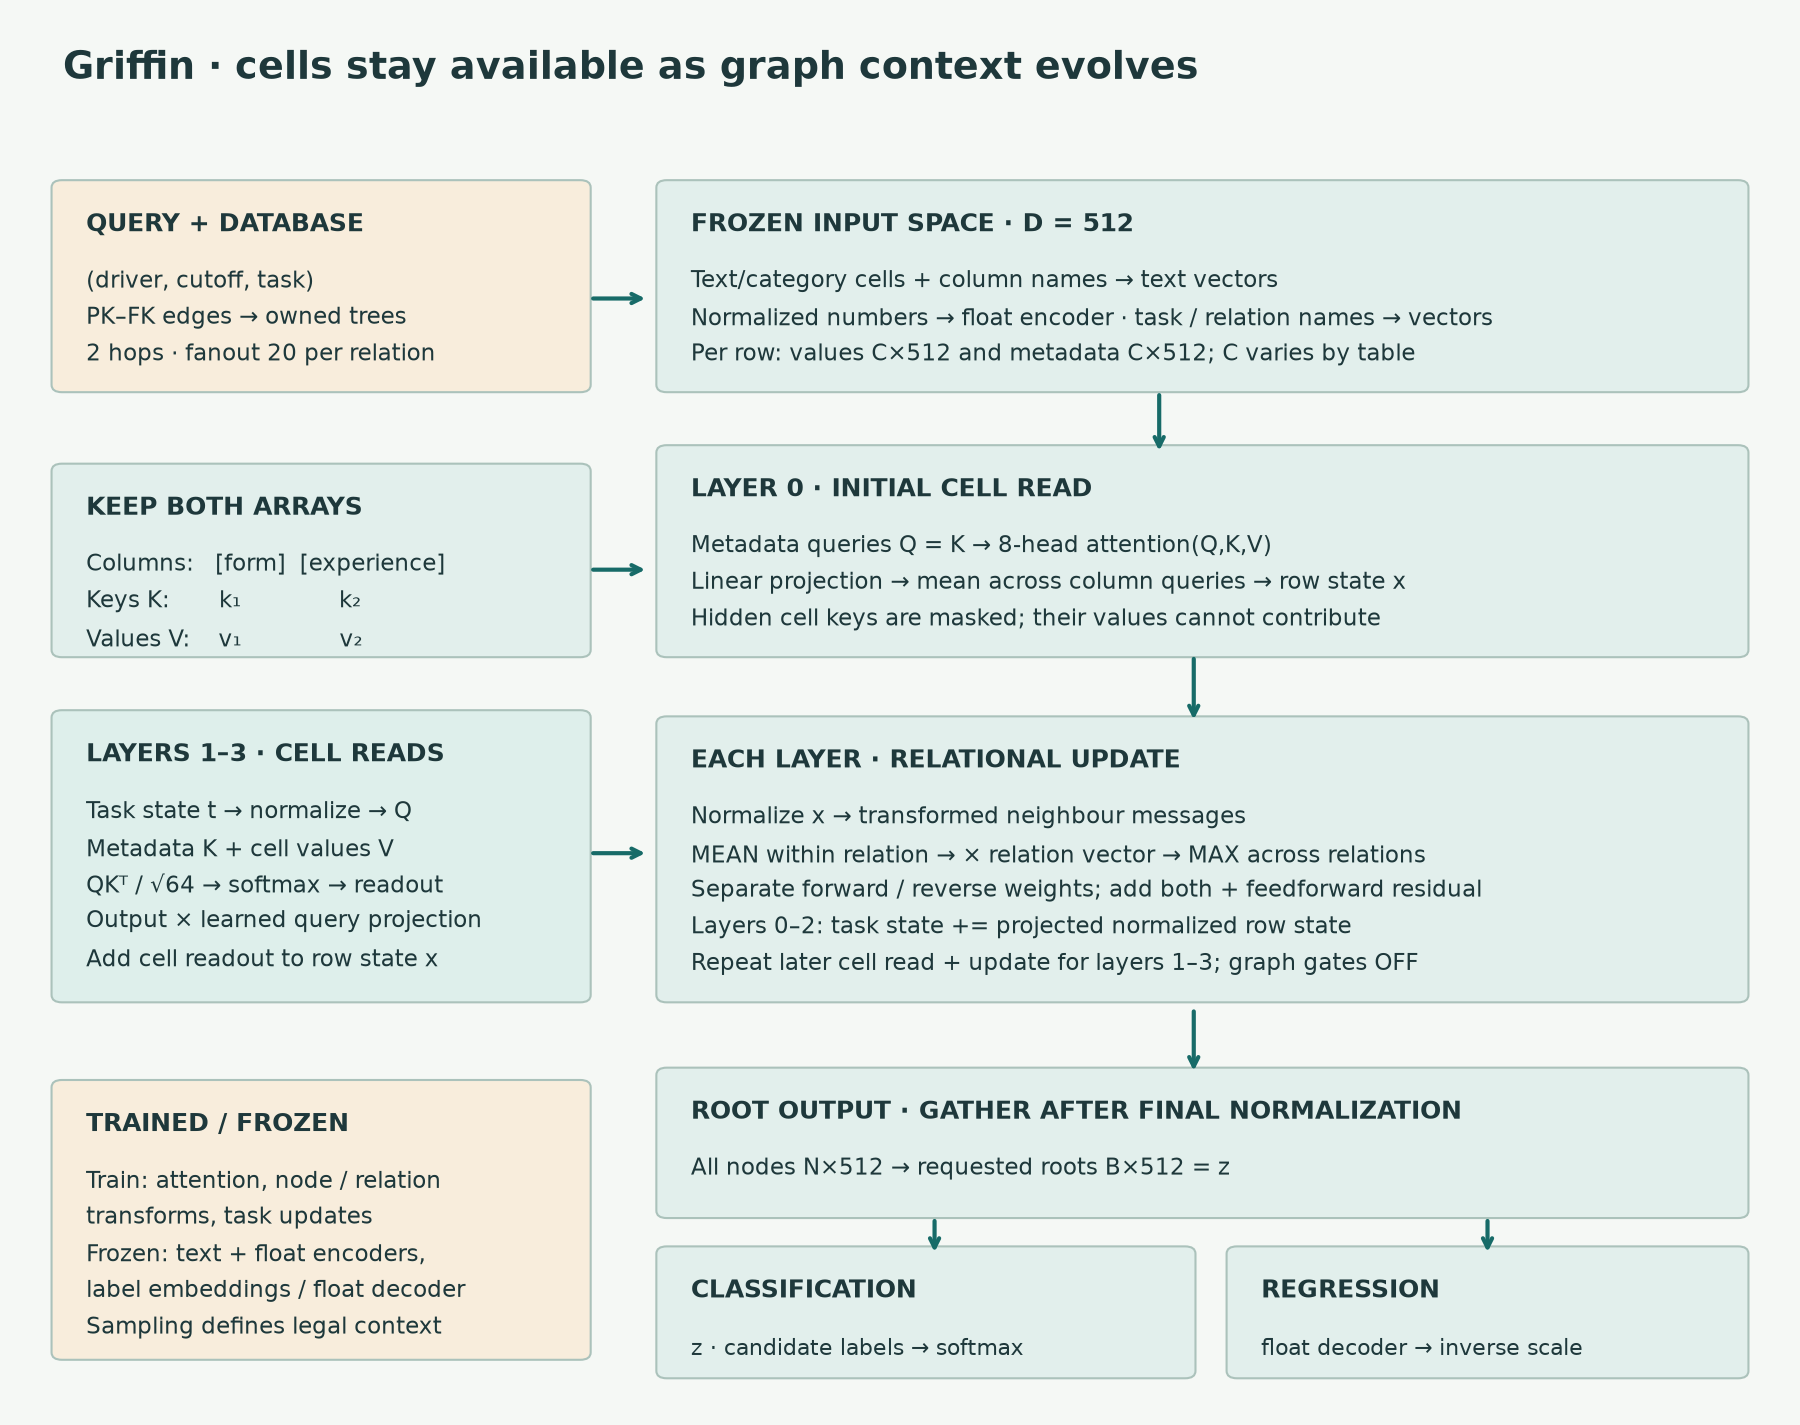

Released transfer variant: four message layers, eight attention heads, forward/reverse updates and graph gates off. C varies by table; shared width is512. Frozen inputs and decoder are separate from trainable shared updates.

**Inputs.** Each sampled row supplies a C×D matrix of cell vectors and a C×D matrix of column-name vectors. C varies by table; the release uses D=512. Category/text values and names use pretrained text embeddings. Numerical values are normalized and passed through a pretrained float encoder. These input encoders stay frozen during downstream adaptation. Our replay consumes the released processed representations; it does not re-create or prove the original normalizer's fitting scope. [Paper §3.1](https://arxiv.org/html/2505.05568v1#S3.SS1)

**Sampling.** A query is identified by both its entity and cutoff time. The main graph sampler builds a two-hop computation tree, with fanout 20 per relation. Fanout is a sampling limit, not a guarantee of 20 neighbours. Repeated appearances of a database row can remain separate computation nodes belonging to different queries. The owner's cutoff travels through every hop; one batch-wide maximum would expose later information to earlier queries.

**Four update layers.** The released model first uses column metadata as both attention queries and keys, cell vectors as values, then averages the resulting queries. Later layers form a query from the evolving task representation. They add the cell readout to the current node state, then add a pointwise feedforward update, forward relational messages and reverse relational messages. “Residual” means adding an update to the existing vector rather than replacing it. Layer normalization rescales each vector's coordinates before these updates. The task state itself receives a learned projection of the updated row state between layers. [Pinned forward pass](https://avistian.github.io/relational/labs/sources/l164/upstream/hmodel.py)

A **feedforward update** applies a small neural network to each node vector separately. A **projection** is a learned linear mapping between vector spaces. Forward and reverse messages traverse a relation in its two directions, with separate learned weights. The diagram's layer numbers 0–3 count four layers in total.

**Output.** A final layer normalization gives one D-dimensional vector per computation node. Gather the requested roots. For classification, take its dot product with each frozen candidate-label vector and apply softmax. For regression, pass it through the frozen float decoder and the appropriate inverse numerical transform. Our selected experiment is binary classification; it does not exercise regression's inverse transform. A unified decoder can accept different label vocabularies without a fresh output matrix per task, but the model still undergoes downstream fine-tuning.

**Shared does not mean weight-free.** Griffin-unpretrained fits this architecture separately on the downstream task. Griffin-pretrained starts from single-table pretraining. Griffin-RDB-SFT also receives joint supervised fine-tuning on other relational tasks. SFT means supervised fine-tuning: updating weights using labeled examples. Our transfer arm starts from the released Others-2 checkpoint and fine-tunes on F1. It is not a zero-shot or purely in-context prediction.

## 3 · Cross-attention asks which cells matter now

An attention **query** Q represents the information being requested. **Keys** K describe candidate information, and **values** V contain what is read. Griffin uses column metadata as keys and cell embeddings as values. The two must remain paired.

For one attention head with width d:

`score_j = dot(Q, K_j) / sqrt(d)`

`weight_j = exp(score_j) / sum(exp(score_visible))`

`readout = sum(weight_j × V_j)`

Softmax converts scores into nonnegative weights summing to 1. Division by √d keeps dot-product scale from growing automatically with head width. A mask removes unavailable cells before normalization. Eight heads in the release learn different projections into 64-dimensional subspaces; their readouts are concatenated and projected back to 512 dimensions. The released later-layer cell module also multiplies the attention output by a learned linear projection of its query. This elementwise modulation is separate from the optional graph-message gates, which the transfer script disables.

**Worked two-dimensional head.** Let keys for recent form and experience be [1,0] and [0,1]. Let their values be [2,0] and [0,4]. A query [√2,0] gives scores [1,0], weights [0.731,0.269], and readout **[1.462,1.076]**. A query [0,√2] instead gives **[0.538,2.924]**. These are invented projected vectors for arithmetic, not real racing features or trained predictions.

Notebook task: reverse paired keys/values, switch task queries, and mask a cell; predict each readout first.

Reverse complete key/value pairs: the sum stays the same. Reverse only values: the meanings become mismatched. The architecture is invariant to a joint permutation of cells and their metadata when masks move with them and dropout is disabled. That does not mean renaming metadata has no effect, or that training dropout yields identical individual samples.

The notebook's `cell_attention` TODO supplies this operation to the visible multihead module. You will also replay projected Q/K/V from one actual released checkpoint layer; those cached tensors are distinct from the invented two-dimensional example.

## 4 · Relation structure should survive aggregation

A node can have many results records but few teammates. A single average across all neighbours weights each relation by its number of neighbours. That may wash out a useful sparse relation. Griffin instead computes a mean **within each relation**, multiplies by a learned relation vector, and takes a coordinate-wise maximum **across relations**. This is a specific inductive bias, not a universal rule that max is best.

For receiver i, relation r and transformed neighbour vector u:

`relation_mean[i,r] = mean(u[j] for neighbours j of i under r)`

`message[i] = coordinate_max(relation_mean[i,r] * relation_vector[r])`

Here `*` multiplies matching coordinates. “Coordinate-wise” matters: different output coordinates can come from different relations. The release applies a learned linear transform to edge metadata before this multiplication and separately transforms node states before aggregation. Reverse messages have their own weights. Receivers with no incoming neighbours get a zero update; a nonempty set of negative messages must not accidentally be clamped to zero. [Paper §3.2](https://arxiv.org/html/2505.05568v1#S3.SS2), [released RMPNN](https://avistian.github.io/relational/labs/sources/l164/upstream/hmodel.py)

Before calculating: predict what repeating every neighbour in one relation does to its mean.

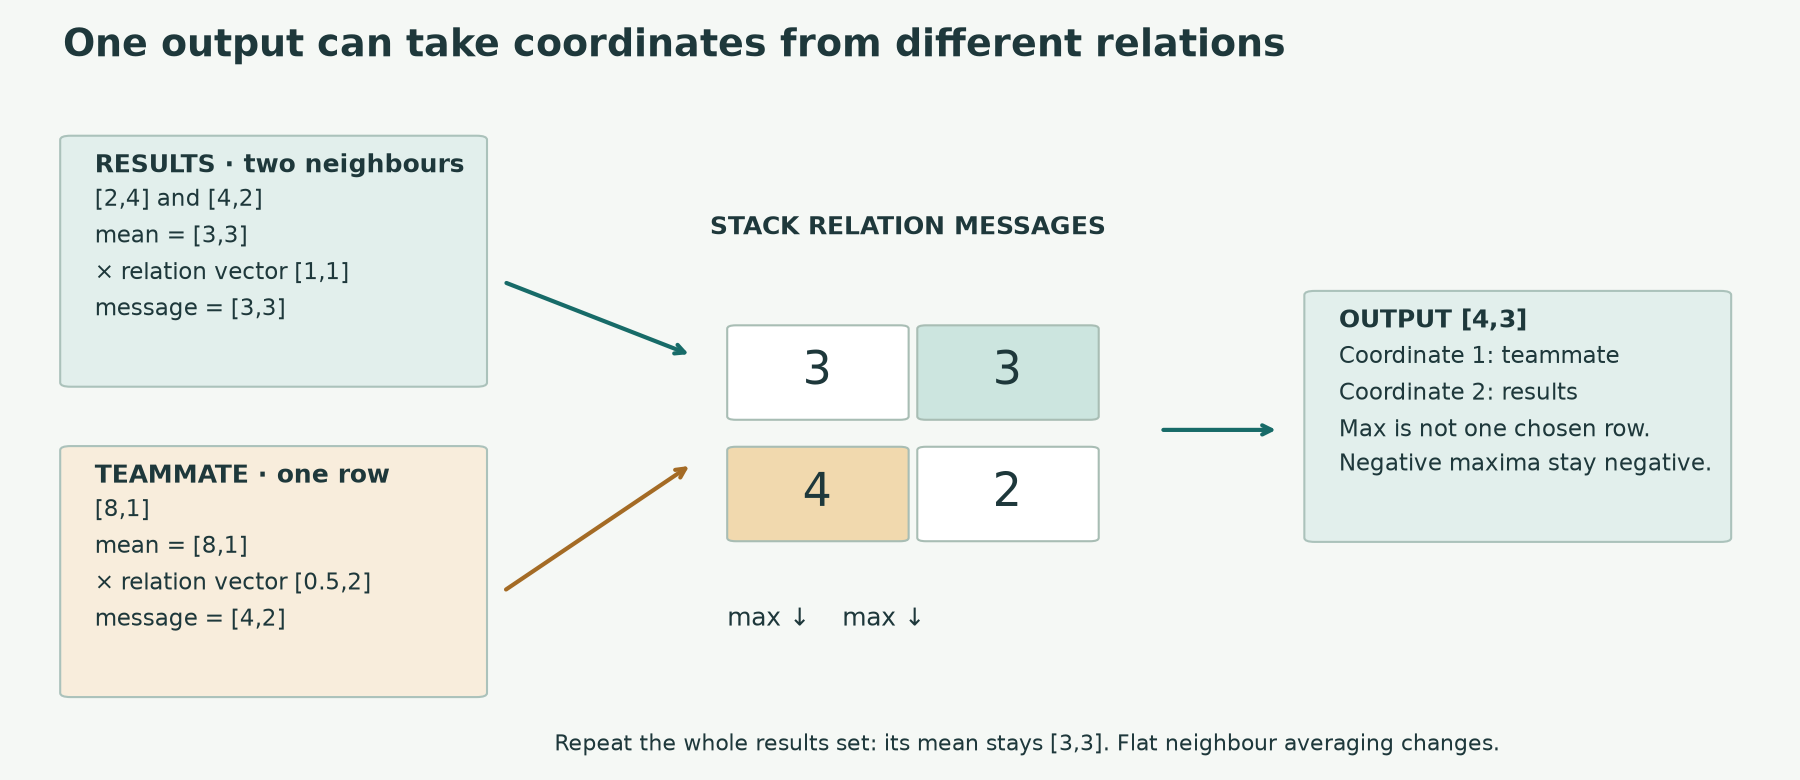

Synthetic already-transformed neighbour vectors at cutoff5. Multiply each relation mean by its vector, then maximize each coordinate. The output [4,3] combines two relations.

Our results neighbours [2,4] and [4,2] average to [3,3]. Their relation vector is [1,1], leaving [3,3]. A teammate [8,1] with relation vector [0.5,2] contributes [4,2]. The final maximum is **[4,3]**: the first coordinate comes from teammate context and the second from results context. Repeating the complete results-neighbour set changes neither its mean nor that final message. Duplicating just one unequal neighbour can change the mean.

Notebook task: compare cutoff5 with cutoff7; repeat every results neighbour and compare relation-balanced versus flat aggregation.

**An empty neighborhood is not the same as a negative message.** Consider already transformed, relation-weighted messages at one receiver:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Available messages</th><th>Coordinate maximum</th></tr></thead><tbody><tr><td>Relation A: [−3, −1]<br>Relation B: [−2, −4]</td><td>[−2, −1]</td></tr><tr><td>Only relation A</td><td>[−3, −1]</td></tr><tr><td>No incoming relation</td><td>[0, 0]</td></tr></tbody></table>

Initializing the maximum at zero would incorrectly turn the first two cases into `[0,0]`, erasing all negative evidence. The implementation uses negative infinity while reducing nonempty groups, then replaces the still-empty receivers with zero. **Try it:** change relation B to `[−2, +4]`. **Check:** the result is `[−2,+4]`; the first coordinate remains negative. This is an aggregation check, not a new trained result.

The later teammate [20,10] is timestamped 6. It is excluded at cutoff 5, included at cutoff 7. Once eligible, it changes the teammate mean to [14,5.5], the weighted message to [7,11], and the final result to [7,11]. Temporal eligibility is therefore part of the computation, not just bookkeeping around a dataset split.

**A source limitation worth keeping visible.** The main graph sampler passes strict owner cutoffs through its hops; our audit checked 1,494 sampled edges. A separate few-shot helper samples earlier **row indices** and ignores its timestamp argument. We demonstrated why that is unsafe for a generic time-stamped table. For the selected F1 task, those helper roots are static driver rows with sentinel timestamps earlier than every query and no task-label feature. The sampled F1 roots pass this narrow audit. It does not establish historical feature availability or make the helper safe on every database. [Audit receipt](https://avistian.github.io/relational/labs/evidence/l164/source-audit.json)

## 5 · Where the reusable weights come from

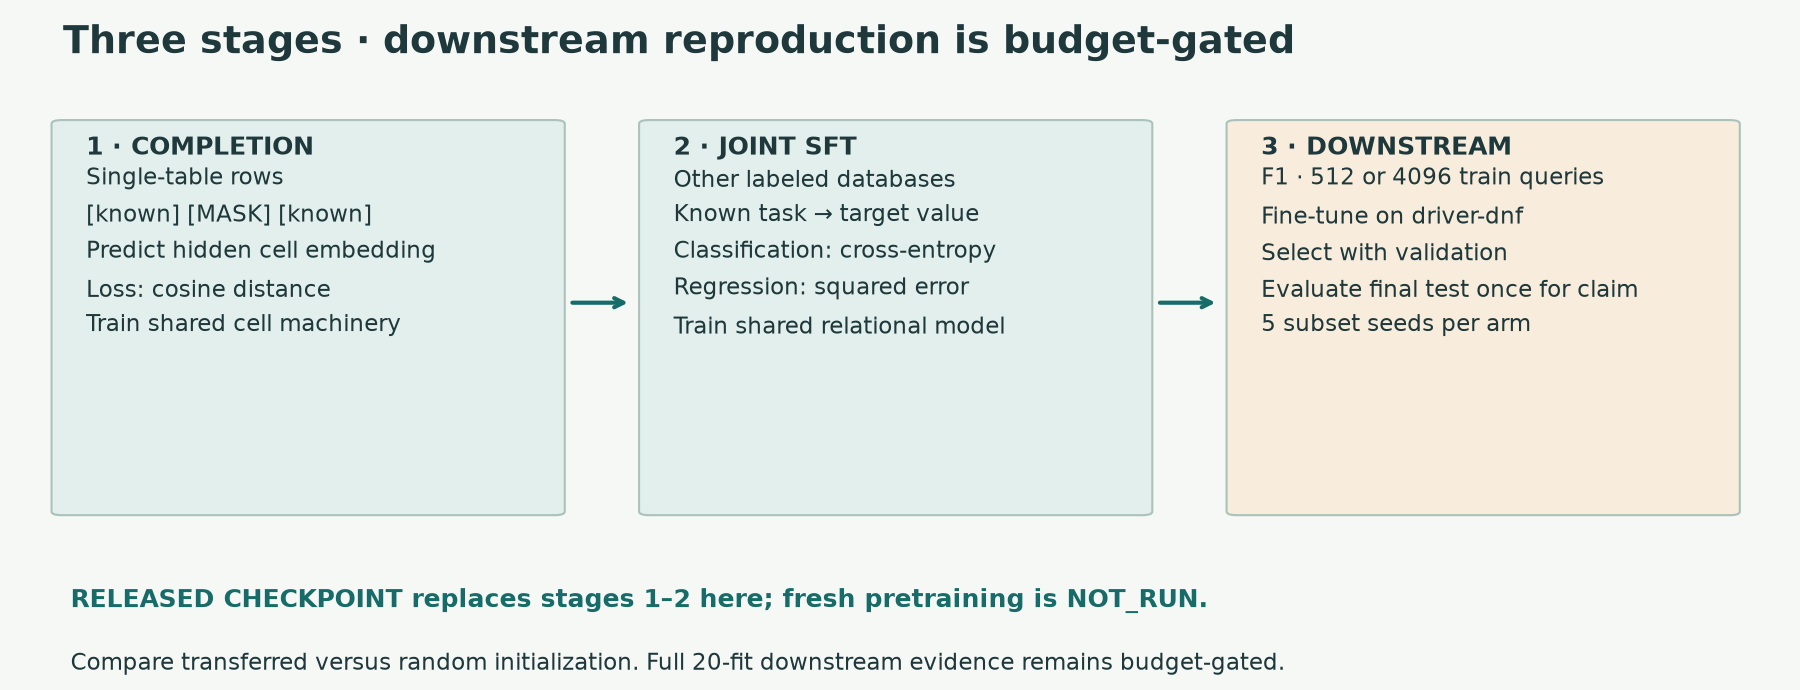

Conceptual training lifecycle. Our checkpoint-based downstream replay would reuse stages 1–2; it does not repeat pretraining. All20full fits remain unrun.

**Completion pretraining** hides a cell and predicts its frozen embedding from the remaining row. The paper uses cosine distance, `1 − dot(a,b)/(norm(a)×norm(b))`, which compares direction rather than magnitude. Single-table completion can train the cell-reading machinery without relational edges.

**Joint SFT** exposes the shared model to labeled tasks: classification uses cross-entropy, which penalizes low probability assigned to the correct class; regression uses squared error. **Downstream fine-tuning** then updates that pretrained model on a selected new task. The released data/float encoders remain frozen, while shared cell-attention and message-passing parameters train. [Paper §4](https://arxiv.org/html/2505.05568v1#S4)

For transfer, “new task” and “new database” are different claims. Others-2 contains Airbnb, trial, TalkingData and Telstra tasks; F1 belongs to Others-1. The released grouping separates these database families. That is a declared group split, not proof about every historical row in pretraining. The paper reports evaluations spanning more than 150 million nodes; this is not evidence that our lesson freshly pretrained on that population.

## 6 · Full reproduction: define the claim before the run

**Named target:** Table 12, Others-2 SFT→`rel-f1-driver-dnf`, compared with no-pretrain, at 512 and 4,096 labeled training queries. Five subset seeds 42–46 per arm/size give 20 fits. The model seed remains 42. Each pair receives the same sampled query subset. This tests the value of the released pretraining initialization on one task; it does not compare Griffin with every other architecture.

| Training queries | No-pretrain published AUROC | Others-2 SFT published AUROC | Fresh lesson result |
|---|---:|---:|---|
| 512 | 0.6558 | 0.7098 | NOT_RUN |
| 4,096 | 0.7176 | 0.7275 | NOT_RUN |

These are **published means**, not our measurements. AUROC measures how well scores rank positives above negatives; 0.5 is chance-level ranking and 1 is perfect. The released metric takes multiclass AUROC over the two candidate labels; our independent scorer uses the corresponding softmax probability for label index 1. The processed class-index semantics are retained rather than assumed to equal a current RelBench label convention. [Table 12](https://arxiv.org/html/2505.05568v1#A6.T12)

The source protocol permits 200 epochs, with full validation every 2 epochs and patience 10 under its exact `epoch − best_epoch > patience` condition. Batch 256, hidden 512, four message-passing layers, hop 2, fanout 20, three few-shot roots, AdamW learning rate 0.0003 and weight decay 0.0002. Validation nominates the checkpoint. The original code also logs test results whenever validation improves; those test results must not drive any decision. Our release replay retains that behavior and saves keyed predictions for independent rescoring. [Protocol and commands](https://avistian.github.io/relational/labs/l164-reproduction.md)

<div class="evidence-note"><strong>INCOMPLETE_BUDGET_GATE.</strong> The L4 probe completed 512 training queries (two optimizer steps) and all 566 validation queries, with 12.72 GB peak allocated GPU memory. It produced no final test score. A conservative 200-epoch scenario for all 20 fits projects USD51.11 compute, or USD63.89 with 25% margin, above the USD 7 fit/check allowance. Early stopping could reduce cost but is unmeasured. Paid work stopped. The retained reservation plus overhead allowance is USD0.86816; the measured worker-body estimate alone is USD0.006683, not an itemized invoice.</div>

A source-matching forward pass establishes implementation compatibility. A timing probe establishes resource observations. Neither establishes the Table 12 transfer gain. The full executable lane remains available with its budget gate; no seed, sample-size or validation-coverage reduction is silently substituted. Exact historical preprocessing and full pretraining remain `NOT_ESTABLISHED` / `NOT_RUN` respectively.

## 7 · Lab: make the mechanism yours

The standalone notebook has three live tasks, with immediate checks:

1. Implement masked, scaled cell attention. Your function supplies every head in the visible model, then recomputes the cached real checkpoint head.
2. Implement mean-within-relation, weighted-max-across-relations. Your function drives the model's forward and reverse message paths.
3. Implement strict owner-specific temporal eligibility. Your function controls the worked neighbour intervention and must reject a single batch cutoff.

Then run a small complete four-layer forward/backward pass, inspect the real source evidence, and write a 200–300 word defense. Explain why [4,3] can combine two different relations, which weights train, and what would be needed to claim transfer. A notebook that merely runs is author preparation, not learner mastery. [Defense template](https://avistian.github.io/relational/labs/l164-defense-template.md)

Explain the complete prediction path and the evidence boundary in your own words before comparing with the source.

**Exit check:** explain why column permutation, schema renaming, changing the task, and changing the cutoff are four different interventions. Ask your teacher a follow-up question about any step you cannot derive. Revisit this explanation after a few days without opening the answer.

**Next:** Lesson 165 examines relational in-context adaptation. Keep the distinction sharp: this Griffin experiment updates model weights for the downstream task; an in-context method instead conditions on examples supplied at prediction time under its own protocol.


## PROVIDED · Environment
The local author checks used PyTorch2.13.0 CPU. The cloud source probe used2.5.1/cu124. This default mechanism lane avoids PyG/datasets/Accelerate; the optional full lane has separate direct pins.

In [1]:
# @colab-bootstrap
import os,sys,subprocess,importlib.util
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if any(importlib.util.find_spec(n) is None for n in ['torch','numpy']):
    subprocess.check_call([sys.executable,'-m','pip','install','torch','numpy'])
import math,json,base64,hashlib,copy
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
torch.set_num_threads(1)
print('PyTorch',torch.__version__)

PyTorch 2.13.0+cpu


## PROVIDED · Cached real projected attention
Storage only: projected Q/K/V from the first validation root in the released Others-2 model’s second layer. The expected readout uses an independent PyTorch attention operator. Replaying these tensors does not rerun the full pretrained model.

In [2]:
trace_blob=base64.b64decode('...')
assert hashlib.sha256(trace_blob).hexdigest()=='cd75d2458ad34646bac887ff0df24b2b9ec8ce28ed977ba9343221fab97b38ed'
real_trace=json.loads(trace_blob)
print(real_trace["note"])

First validation root, second layer, eight heads, actual released Others-2 checkpoint; projected Q/K/V before output projection/gating. Replaying this is not fresh model evaluation.


In [3]:
def check_attention(fn):
    q=torch.tensor([[[1.,0.]]],dtype=torch.float64)
    k=torch.tensor([[[1.,0.],[0.,1.],[20.,20.]]],dtype=torch.float64)
    v=torch.tensor([[[2.,0.],[0.,4.],[999.,999.]]],dtype=torch.float64)
    blocked=torch.tensor([[[False,False,True]]])
    want=torch.tensor([[[1.339523098653314,1.320953802693373]]],dtype=torch.float64)
    torch.testing.assert_close(fn(q,k,v,blocked),want,atol=1e-12,rtol=1e-12)
    torch.testing.assert_close(fn(q,k[:,[1,0,2]],v[:,[1,0,2]],blocked),want,atol=1e-12,rtol=1e-12)
    try:fn(q,k,v,torch.ones_like(blocked))
    except ValueError:pass
    else:raise AssertionError('All-masked attention must be rejected')

In [4]:
def check_relations(fn):
    x=torch.tensor([[0.,0.],[2.,4.],[4.,2.],[8.,1.]])
    ei=torch.tensor([[0,0,0],[1,2,3]]);r=torch.tensor([0,0,1]);e=torch.tensor([[1.,1.],[.5,2.]])
    want=torch.tensor([[4.,3.],[0.,0.],[0.,0.],[0.,0.]])
    torch.testing.assert_close(fn(x,ei,r,e),want)
    # Repeat EVERY neighbour of one relation: its mean and final result stay fixed.
    ei2=torch.tensor([[0,0,0,0,0],[1,2,1,2,3]]);r2=torch.tensor([0,0,0,0,1])
    torch.testing.assert_close(fn(x,ei2,r2,e),want)
    torch.testing.assert_close(fn(x,torch.empty(2,0,dtype=torch.long),torch.empty(0,dtype=torch.long),e),torch.zeros_like(x))
    # Max over present negative messages must remain negative, not clamp to zero.
    torch.testing.assert_close(fn(-x,ei,r,e)[0],torch.tensor([-3.,-2.]))

In [5]:
def check_cutoffs(fn):
    times=torch.tensor([[4,5,6,-1],[4,5,6,-1]])
    cutoff=torch.tensor([5,7])
    assert torch.equal(fn(times,cutoff),torch.tensor([[True,False,False,False],[True,True,True,False]]))
    try:fn(times,torch.tensor([5]))
    except ValueError:pass
    else:raise AssertionError('A batch-wide cutoff must not broadcast silently')

In [6]:
def check_all(attention,pool,cutoffs):
    check_attention(attention);check_relations(pool);check_cutoffs(cutoffs)
    return 'PASS: masked attention, relation balance, per-owner time'

## TODO · Read the permitted cells

Implement scaled dot-product attention for[...,Q,d]queries,[...,C,d]keys and[...,C,v]values. blocked is a broadcastable boolean mask(True excludes). Reject an all-masked query. Normalize over cells; dropout applies to weights only when training=True. Preserve dtype,device and gradients.

Predict a counterexample before coding; use the equations above to derive the update.

In [7]:
def cell_attention(q,k,v,blocked=None,dropout=0.,training=False):
    if q.shape[-1] != k.shape[-1] or k.shape[-2] != v.shape[-2]:
        raise ValueError('Q/K width and K/V cell count must align')
    scores = q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])
    if blocked is not None:
        if blocked.dtype != torch.bool:
            raise ValueError('blocked must be boolean')
        blocked = torch.broadcast_to(blocked, scores.shape)
        if blocked.all(-1).any():
            raise ValueError('Each query needs at least one visible cell')
        scores = scores.masked_fill(blocked, -torch.inf)
    weights = scores.softmax(-1)
    return F.dropout(weights, p=dropout, training=training) @ v

In [8]:
# CHECK
check_attention(cell_attention)
print("Read the permitted cells: PASS")

Read the permitted cells: PASS


## TODO · Balance relations before combining them

Receive[N,D]neighbour states,edge_index[2,E]with receiver then sender,Erelation IDs,and[R,D]already-transformed relation vectors. Mean by(receiver,relation),multiply by that relation vector,then maximize over present relations per receiver. Empty receiver→zeros; negative messages remain negative. Preserve gradients.

Predict a counterexample before coding; use the equations above to derive the update.

In [9]:
def relation_pool(x,edge_index,relation,relation_vectors):
    if edge_index is None or edge_index.numel() == 0:
        return x * 0
    receiver, sender = edge_index
    pairs, inverse = torch.unique(torch.stack((receiver, relation)), dim=1, return_inverse=True)
    total = torch.zeros((pairs.shape[1], x.shape[1]), dtype=x.dtype, device=x.device)
    total.index_add_(0, inverse, x[sender])
    count = torch.bincount(inverse, minlength=pairs.shape[1]).to(x.dtype)
    messages = (total / count[:, None]) * relation_vectors[pairs[1]]
    out = torch.full_like(x, -torch.inf)
    out.scatter_reduce_(0, pairs[0, :, None].expand_as(messages), messages, reduce='amax', include_self=True)
    return torch.where(torch.isfinite(out), out, torch.zeros_like(out))

In [10]:
# CHECK
check_relations(relation_pool)
print("Balance relations before combining them: PASS")

Balance relations before combining them: PASS


## TODO · Carry the owner cutoff

Receive[B,F]timestamps and[B]owner cutoffs. Return a boolean strict-time mask. -1is padding in this teaching fixture; other negative times can be valid. Require exactly one cutoff per owner,without broadcasting a single global time.

Predict a counterexample before coding; use the equations above to derive the update.

In [11]:
def eligible_edges(times,owner_cutoffs):
    if times.ndim != 2 or owner_cutoffs.shape != (times.shape[0],):
        raise ValueError('One cutoff per owner; no implicit batch-wide broadcast')
    return (times != -1) & (times < owner_cutoffs[:, None])

In [12]:
# CHECK
check_cutoffs(eligible_edges)
print("Carry the owner cutoff: PASS")

Carry the owner cutoff: PASS


## PROVIDED · CellAttention
This is the checkpoint-compatible visible computation. CellAttention calls your cell_attention; RelationMessage calls your relation_pool. Study the forward pass,not just the class name.

In [13]:
class CellAttention(nn.Module):
    """Checkpoint names match release; kernel math is visible and learner-editable."""
    def __init__(self,hiddim,first=False):
        super().__init__();self.first=first
        self.linq=nn.Linear(hiddim,hiddim,bias=False)
        self.crossattention=nn.MultiheadAttention(hiddim,8,dropout=.1,bias=False,batch_first=True)

    def forward(self,metadata,values,task=None,blocked=None):
        b,c,d=values.shape;heads=8;width=d//heads
        keys=metadata.unsqueeze(0).expand(b,-1,-1)
        queries=keys if self.first else task.unsqueeze(1)
        wq,wk,wv=self.crossattention.in_proj_weight.chunk(3,dim=0)
        def split(x,w):return F.linear(x,w).reshape(b,-1,heads,width).transpose(1,2)
        mask=None if blocked is None else blocked[:,None,None,:]
        out=cell_attention(split(queries,wq),split(keys,wk),split(values,wv),mask,.1,self.training)
        out=out.transpose(1,2).reshape(b,-1,d)
        out=F.linear(out,self.crossattention.out_proj.weight)
        if self.first:return self.linq(out).mean(1)
        return (out*self.linq(queries)).squeeze(1)

## PROVIDED · RelationMessage
This is the checkpoint-compatible visible computation. CellAttention calls your cell_attention; RelationMessage calls your relation_pool. Study the forward pass,not just the class name.

In [14]:
class RelationMessage(nn.Module):
    def __init__(self,hiddim):
        super().__init__();self.rellin=nn.Sequential(nn.Linear(hiddim,hiddim))

    def forward(self,x,edge_index,relation,metadata):
        if edge_index is None or edge_index.numel()==0:
            return 0*self.rellin(x[0])  # exact release broadcast path
        return relation_pool(x,edge_index,relation,self.rellin(metadata))

## PROVIDED · GriffinMod
This is the checkpoint-compatible visible computation. CellAttention calls your cell_attention; RelationMessage calls your relation_pool. Study the forward pass,not just the class name.

In [15]:
class GriffinMod(nn.Module):
    """Released four-layer family, including optional gates and reverse messages.

    Frozen text/float encoders and root sampling live outside this module. Inputs
    are lists of (column metadata[C,D], values[N,C,D]), masks and task vectors.
    The classification decoder is explicit in classification_logits below.
    """
    def __init__(self,hiddim=512,num_mp=4,use_rev=True,use_gate=False):
        super().__init__();self.num_mp=num_mp;self.use_rev=use_rev;self.use_gate=use_gate
        self.nodefeataggr=nn.ModuleList([CellAttention(hiddim,first=i==0) for i in range(num_mp)])
        self.mpnn=nn.ModuleList([RelationMessage(hiddim) for _ in range(num_mp)])
        self.lintask=nn.ModuleList([nn.Linear(hiddim,hiddim,bias=False) for _ in range(num_mp-1)])
        self.mlp=nn.ModuleList([nn.Sequential(nn.Linear(hiddim,hiddim,bias=False),nn.SiLU(inplace=True)) for _ in range(num_mp)])
        self.mlp2=nn.ModuleList([nn.Sequential(nn.Linear(hiddim,hiddim,bias=False),nn.SiLU(inplace=True),nn.Linear(hiddim,hiddim,bias=False)) for _ in range(num_mp)])
        self.ln=nn.LayerNorm(hiddim,elementwise_affine=False)
        def gates():
            layers=nn.ModuleList([nn.Sequential(nn.Linear(hiddim,int(hiddim**.5)),nn.SiLU(inplace=True),nn.Linear(int(hiddim**.5),1,bias=False)) for _ in range(num_mp)])
            with torch.no_grad():
                for layer in layers:layer[2].weight.zero_()
            return layers
        self.gatelin=gates() if use_gate else None
        self.revmpnn=nn.ModuleList([RelationMessage(hiddim) for _ in range(num_mp)]) if use_rev else None
        self.revgatelin=gates() if use_rev and use_gate else None

    def forward(self,node,mask,taskfeat,edge_index,edge_attr_type,edge_attr):
        tasks=[]
        for task,(metadata,values) in zip(taskfeat,node):
            t=metadata.mean(0) if task is None else task
            tasks.append(t.expand(values.shape[0],-1) if t.ndim==1 else t)
        counts=[v.shape[0] for _,v in node]
        for layer in range(self.num_mp):
            cells=torch.cat([self.nodefeataggr[layer](m,v,self.ln(t),blocked) for (m,v),t,blocked in zip(node,tasks,mask)],dim=0)
            x=cells if layer==0 else x+cells
            normal=self.ln(x);messages=self.mlp[layer](normal)
            forward=self.mpnn[layer](messages,edge_index,edge_attr_type,edge_attr)
            if self.use_gate:forward=forward*self.gatelin[layer](normal)
            reverse=0
            if self.use_rev:
                reverse=self.revmpnn[layer](messages,None if edge_index is None else edge_index[[1,0]],edge_attr_type,edge_attr)
                if self.use_gate:reverse=reverse*self.revgatelin[layer](normal)
            x=x+self.mlp2[layer](normal)+forward+reverse
            if layer<self.num_mp-1:
                updates=self.lintask[layer](self.ln(x)).split(counts)
                tasks=[old+new for old,new in zip(tasks,updates)]
        return self.ln(x)

## PROVIDED · classification_logits
This is the checkpoint-compatible visible computation. CellAttention calls your cell_attention; RelationMessage calls your relation_pool. Study the forward pass,not just the class name.

In [16]:
def classification_logits(model,batch):
    node,mask,tasks,edges,relations,edge_vectors,labels,label_vectors,root_mapping=batch
    if label_vectors is None:raise ValueError('Classification requires candidate label embeddings')
    return model(node,mask,tasks,edges,relations,edge_vectors)[root_mapping] @ label_vectors.T

## CHECK · Complete model forward and backward
Small untrained four-layer model,D16,8heads,4nodes. This checks live integration and finite gradients; its logits are not an F1performance result. The exact512-wide pretrained-model parity is recorded separately in author evidence.

In [17]:
torch.manual_seed(164)
model=GriffinMod(hiddim=16,num_mp=4).double()
node=[(torch.randn(3,16,dtype=torch.float64),torch.randn(4,3,16,dtype=torch.float64))]
args=[node,[None],[torch.randn(16,dtype=torch.float64)],torch.tensor([[0,0,1,2],[1,2,2,3]]),torch.tensor([0,1,0,1]),torch.randn(2,16,dtype=torch.float64)]
output=model(*args)
assert output.shape==(4,16)
output.square().mean().backward()
assert all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters())
print('Four-layer live forward/backward PASS; no accuracy claim')

Four-layer live forward/backward PASS; no accuracy claim


## PROVIDED · Recompute the worked interventions
Both the synthetic and real cached attention paths call your function. The cutoff mask directly selects the worked graph edges before your relation_pool runs.

In [18]:
def worked_report(attention,pool,cutoffs,real_trace):
    q=torch.tensor([[[math.sqrt(2),0.]]],dtype=torch.float64)
    k=torch.eye(2,dtype=torch.float64)[None];v=torch.tensor([[[2.,0.],[0.,4.]]],dtype=torch.float64)
    a=attention(q,k,v);b=attention(q.flip(-1),k,v)
    torch.testing.assert_close(a,attention(q,k.flip(1),v.flip(1)))
    rows=torch.tensor([[0.,0.],[2.,4.],[4.,2.],[8.,1.],[20.,10.]],dtype=torch.float64)
    edges=torch.tensor([[0,0,0,0],[1,2,3,4]]);rel=torch.tensor([0,0,1,1]);emb=torch.tensor([[1.,1.],[.5,2.]],dtype=torch.float64)
    times=torch.tensor([[4,4,4,6]])
    out={}
    for time in [5,7]:
        keep=cutoffs(times,torch.tensor([time]))[0]
        out[str(time)]=pool(rows,edges[:,keep],rel[keep],emb)[0].tolist()
    real={n:torch.tensor(real_trace[n],dtype=torch.float32) for n in ['q','k','v','expected']}
    actual=attention(real['q'],real['k'],real['v'])
    torch.testing.assert_close(actual,real['expected'],atol=1e-5,rtol=1e-5)
    return dict(lane='SYNTHETIC_MECHANISM_AND_CACHED_REAL_ATTENTION',task_A=[round(x,9) for x in a.flatten().tolist()],task_B=[round(x,9) for x in b.flatten().tolist()],relation_messages=out,real_attention_shape=list(actual.shape),real_attention_replay='PASS',full_reproduction='INCOMPLETE_BUDGET_GATE',test_metric='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

In [19]:
report=worked_report(cell_attention,relation_pool,eligible_edges,real_trace)
print(json.dumps(report,indent=2))
Path('l164-report.json').write_text(json.dumps(report,indent=2)+'\n')

{
  "lane": "SYNTHETIC_MECHANISM_AND_CACHED_REAL_ATTENTION",
  "task_A": [
    1.462117157,
    1.075765685
  ],
  "task_B": [
    0.537882843,
    2.924234315
  ],
  "relation_messages": {
    "5": [
      4.0,
      3.0
    ],
    "7": [
      7.0,
      11.0
    ]
  },
  "real_attention_shape": [
    1,
    8,
    1,
    64
  ],
  "real_attention_replay": "PASS",
  "full_reproduction": "INCOMPLETE_BUDGET_GATE",
  "test_metric": "NOT_RUN",
  "learner": "PENDING_WRITTEN_DEFENSE"
}


487

## EXIT · Write the defense
Use the five-part template in the lesson. Include a complete prediction trace,the[4,3]derivation,a temporal counterexample,and exactly what the unrun20fitcomparison prevents you from claiming.200–300words;rubric computation/architecture/legality/evidence/next test,0–2each,≥8with no zero after review.

In [20]:
defense='The model preserves cell vectors while graph and task states evolve. Relation-wise mean followed by coordinate-wise max prevents a complete duplication of one relation from reweighting the others. A source-matching forward pass and a resource probe do not show that pretraining transfers. That requires all20matched downstream fits and final keyed test predictions. The separate index-based few-shot helper also needs a database-specific temporal audit.'
Path("l164-submission.json").write_text(json.dumps(dict(defense=defense,learner="PENDING_WRITTEN_DEFENSE",review=None),indent=2))
print("Defense exported; learner PENDING_WRITTEN_DEFENSE")

Defense exported; learner PENDING_WRITTEN_DEFENSE


## NEXT STEP · Complete selected release reproduction (OFF)
Author decision: INCOMPLETE_BUDGET_GATE. The following executable lane reproduces the complete source protocol,not a larger toy. All20fits may take many hours; the author cap does not authorize additional cloud spend. The manual learner gate requires explicit runtime acknowledgment. It uses the original released model after the visible port was independently checked. One compatibility property repairs model.device; the trainer and data sampler otherwise retain their release behavior. Full wrapper execution and live Colab remain unverified.

### Read the complete released trainer
The main notebook already exposes the model. The following source appendix exposes the original loss,evaluation,checkpoint selection and training loop. These are source listings,not executed notebook commands. Supporting samplers/model source are pinned in the materialization payload and linked from the protocol.

#### Released eval_task
```python
def eval_task(model, dec, dataset, args, accelerator, metric, with_sample=False):
    model.eval()
    if with_sample and args.eval_sample_ratio < 1:
        dataset.rebuild_indice_downsample(accelerator, args.eval_sample_ratio, args.eval_sample_seed)
    else:
        dataset.rebuild_indice(accelerator)
    batchsize: int = dataset.batch_size
    loader = DataLoader(
        dataset,
        shuffle=False,
        batch_size=1,
        collate_fn=lambda xlist: xlist[0],
        num_workers=8,
        persistent_workers=False,
    )
    loader = accelerator.prepare(loader)
    outputs = []
    labels = []
    with torch.no_grad():
        for data in loader:
            output, label = compute_output(model, dec, data)
            if output.shape[0] < batchsize:
                assert output.ndim == 2
                assert label.ndim == 1
                padnum = batchsize-output.shape[0]
                if torch.is_floating_point(label):
                    label = torch.concat((label, torch.empty_like(label[[0]].expand(padnum)).fill_(torch.nan)), dim=0)
                else:
                    label = torch.concat((label, torch.empty_like(label[[0]].expand(padnum)).fill_(-1)), dim=0)
                output = torch.concat((output, torch.empty_like(output[[0]].expand(padnum, -1)).fill_(torch.nan)), dim=0)
            output, label = output.unsqueeze(0), label.unsqueeze(0)
            output, label = accelerator.gather_for_metrics((output, label))
            output, label = output.flatten(0, 1), label.flatten(0, 1)
            if accelerator.is_main_process:
                if torch.is_floating_point(label):
                    mask = torch.isnan(label).logical_not_()
                else:
                    mask = label >= 0
                output, label = output[mask], label[mask]
                outputs.append(output.cpu())
                labels.append(label.cpu())
    #if metric.requires_gather:
    #    metric.outputs, metric.labels = accelerator.gather_for_metrics((metric.outputs, metric.labels))
    if accelerator.is_main_process:
        labels = torch.concat(labels, dim=0)
        outputs = torch.concat(outputs, dim=0)
        return compute_metric(outputs, labels, metric)
    else:
        return None
```

#### Released construct_dataset
```python
def construct_dataset(graph, task, tasknames, split, args, floatembmodel):
    return LoaderWrapperTask(
        graph,
        batch_size=args.batchsize,
        subgraphargs={
            "floatemb": floatembmodel,
            "fanout": args.fanout,
            "hop": args.hop,
        },
        shuffle=True if split == "train" else False,
        task=task,
        tasknames=tasknames,
        split=split,
        fewshotfanout=args.fewshotfanout,
    )
```

#### Released compute_output
```python
def compute_output(model, dec, data):
    label, y, mapping = data[-3:]
    data = data[:-3]
    if y is None:
        output = dec(model(*data)[mapping])
    else:
        output = model(*data)[mapping] @ y.T
    return output, label
```

#### Released compute_loss
```python
def compute_loss(model, dec, data):
    label, y, mapping = data[-3:]
    data = data[:-3]
    if y is None:
        output = dec(model(*data)[mapping])
        loss = F.mse_loss(output.flatten(), label.flatten())
    else:
        output = model(*data)[mapping] @ y.T
        loss = F.cross_entropy(output, label)
    return loss
```

#### Released main
```python
def main(args):
    tbconfig = ProjectConfiguration(project_dir=args.logdir, logging_dir=args.logdir)
    accelerator = Accelerator(log_with="tensorboard", project_config=tbconfig)
    accelerator.init_trackers(args.logname)
    tbtracker = accelerator.get_tracker("tensorboard")

    model = GriffinMod(hiddim=args.hiddim, num_mp=args.num_mp, use_rev=args.use_rev, use_gate=args.use_gate)
    if args.loadpath is not None:
        accelerate.load_checkpoint_in_model(model, args.loadpath)
    # model.reset_parameters()
    dec = getfloatdec(args.hiddim)

    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.wd)
    graph = Graph(args.dataset)
    task = Task(args.dataset)

    tasknames = args.tasks
    if len(tasknames) == 1:
        if tasknames[0] == "ALLTASK":
            tasknames = [taskname for taskname in task.metatask]
        elif tasknames[0] == "RETTASK":
            tasknames = [
                taskname
                for taskname in task.metatask
                if task.metatask[taskname]["task_type"] == "retrieval"
            ]
        elif tasknames[0] == "REGTASK":
            tasknames = [
                taskname
                for taskname in task.metatask
                if task.metatask[taskname]["task_type"] == "regression"
            ]
        elif tasknames[0].startswith("EXCEPT__"):
            expect_taskname = tasknames[0][len("EXCEPT__"):]
            tasknames = [taskname for taskname in task.metatask if taskname != expect_taskname]
        elif tasknames[0] in ["commerce-1", "commerce-2", "others-1", "others-2"]:
            with open("task_names.yaml", "r") as f:
                tasks_dict = yaml.load(f, Loader=yaml.FullLoader)
            tasknames = tasks_dict[tasknames[0]]
    if accelerator.is_main_process:
        print(tasknames)

    floatembmodel = SimpleRepeater(args.hiddim)

    dataset = construct_dataset(graph, task, tasknames, "train", args, floatembmodel)
    valid_dataset_dict = {
        taskname: construct_dataset(graph, task, [taskname], "valid", args, floatembmodel)
        for taskname in tasknames
    }
    test_dataset_dict = {
        taskname: construct_dataset(graph, task, [taskname], "test", args, floatembmodel)
        for taskname in tasknames
    }
    metric_dict = {
        taskname: task.metatask[taskname]["metric"] for taskname in tasknames
    }
    best_valid_metric = -torch.inf
    best_checkpoint_path = None
    best_epoch = 0

    model, dec, optimizer = accelerator.prepare(model, dec, optimizer)

    if args.mode == "test":
        test_metric = {}
        for taskname in tasknames:
            if accelerator.is_main_process:
                print(f"test {taskname}...")
            eval_metric = eval_task(
                model,
                dec,
                test_dataset_dict[taskname],
                args,
                accelerator,
                metric_dict[taskname],
            )
            test_metric[taskname] = eval_metric
            if accelerator.is_main_process:
                print(f"test_metric/{taskname}: {test_metric[taskname]}", flush=True)
        accelerator.end_training()
        return

    model.train()
    step = 0
    for epoch in range(args.maxepoch):
        if accelerator.is_main_process:
            print(f"Epoch {epoch} starts")
        dataset.rebuild_indice_downsample_absolute(accelerator, args.downsample_num, args.downsample_seed)
        loader = DataLoader(
            dataset,
            shuffle=True,
            batch_size=1,
            collate_fn=lambda xlist: xlist[0],
            num_workers=16,
            prefetch_factor=4,
            persistent_workers=False,
            pin_memory=True
        )
        loader = accelerator.prepare(loader)
        for data in loader:
            step += 1
            optimizer.zero_grad()
            loss = compute_loss(model, dec, data)
            accelerator.backward(loss)
            optimizer.step()
            if step % 100 == 0:
                tbtracker.log({"training_loss": loss}, step=step)
        accelerator.wait_for_everyone()
        checkpoint_path = osp.join(args.savepath, f"checkpoint-{epoch}-{step}") if args.savepath is not None else None
        if args.savepath is not None:
            if accelerator.is_main_process:
                accelerator.save_model(model, checkpoint_path)
        if (epoch + 1) % args.eval_per_epoch == 0:
            # Switch to eval mode.
            eval_metric = {}
            for taskname in tasknames:
                if accelerator.is_main_process:
                    print(f"Validating {taskname}...")
                eval_metric[taskname] = eval_task(
                    model,
                    dec,
                    valid_dataset_dict[taskname],
                    args,
                    accelerator,
                    metric_dict[taskname],
                    with_sample=True,
                )
                if accelerator.is_main_process:
                    tbtracker.log({f"valid_metric/{taskname}/{metric_dict[taskname]}": eval_metric[taskname]}, step=step)
                    print(f"valid_metric/{taskname}/{metric_dict[taskname]}: {eval_metric[taskname]}", flush=True)
            if accelerator.is_main_process:
                avg_valid_metric = sum(eval_metric.values()) / len(eval_metric)
                print(f"Average valid metric: {avg_valid_metric}", flush=True)
            # spread the metric to all processes
            avg_valid_metric = accelerator.gather(torch.tensor([avg_valid_metric if accelerator.is_main_process else 0.0]).to(model.device)).mean().item()
            if avg_valid_metric > best_valid_metric:
                best_valid_metric = avg_valid_metric
                best_checkpoint_path = checkpoint_path
                best_epoch = epoch
                eval_metric = {}
                for taskname in tasknames:
                    if accelerator.is_main_process:
                        print(f"test {taskname}...")
                    eval_metric[taskname] = eval_task(
                        model,
                        dec,
                        test_dataset_dict[taskname],
                        args,
                        accelerator,
                        metric_dict[taskname],
                        with_sample=True,
                    )
                    if accelerator.is_main_process:
                        tbtracker.log({f"test_metric/{taskname}/{metric_dict[taskname]}": eval_metric[taskname]}, step=step)
                        print(f"test_metric/{taskname}/{metric_dict[taskname]}: {eval_metric[taskname]}", flush=True)
                if accelerator.is_main_process:
                    avg_test_metric = sum(eval_metric.values()) / len(eval_metric)
                    print(f"Average test metric: {avg_test_metric}", flush=True)
            if args.patience > 0 and epoch - best_epoch > args.patience:
                print(f"Early stopping at epoch {epoch}")
                break
            model.train()

    test_metric = {}
    if best_checkpoint_path is not None:
        if accelerator.is_main_process:
            print(f"Loading best checkpoint from {best_checkpoint_path}")
        unwrap_model = accelerator.unwrap_model(model)
        accelerate.load_checkpoint_in_model(unwrap_model, best_checkpoint_path)
        model = accelerator.prepare(unwrap_model)
        # resave the best checkpoint
        if accelerator.is_main_process:
            print(f"Saving best checkpoint at {osp.join(args.savepath, 'best_checkpoint')}")
            accelerator.save_model(model, osp.join(args.savepath, 'best_checkpoint'))

    for taskname in tasknames:
        if accelerator.is_main_process:
            print(f"Testing {taskname}...")
        eval_metric = eval_task(
            model,
            dec,
            test_dataset_dict[taskname],
            args,
            accelerator,
            metric_dict[taskname],
        )
        if accelerator.is_main_process:
            tbtracker.log({f"test_metric/{taskname}": eval_metric}, step=step)
            print(f"test_metric/{taskname}: {eval_metric}")
            test_metric[taskname] = eval_metric

    if accelerator.is_main_process:
        avg_metric = sum(test_metric.values()) / len(test_metric)
        print(f"Average test metric: {avg_metric}")

    accelerator.end_training()
    if args.savepath is not None and accelerator.is_main_process:
        # delete other checkpoints
        for file in os.listdir(args.savepath):
            # only keep the directory "best_checkpoint"
            if file.startswith('checkpoint-') and file != 'best_checkpoint':
                shutil.rmtree(osp.join(args.savepath, file))
```

### Read the replay instrumentation
The wrapper below changes device access and saves independent keyed prediction evidence. No algorithm is hidden in the encoded storage cell.

#### Wrapper setup
```python
def setup(root):
    root=Path(root).resolve();os.chdir(root)
    sys.path.insert(0,str(P/'sources/l164/upstream'));torch.set_num_threads(1)
    torch.manual_seed(42);np.random.seed(42)
    if torch.cuda.is_available():torch.cuda.manual_seed(42)
    return root
```

#### Wrapper run_source
```python
def run_source(root,out,arm,size,seed):
    root=setup(root);out=Path(out).resolve();out.mkdir(parents=True,exist_ok=True)
    assert arm in ['no-pretrain','others-2'];assert size in [512,4096];assert seed in range(42,47)
    import argparse
    import hmaintask_downsample_absolute_eval_sample as release
    from sklearn.metrics import roc_auc_score
    # Source references model.device although GriffinMod has no such property.
    # This compatibility fix changes no tensor computation or training settings.
    release.GriffinMod.device=property(lambda self:next(self.parameters()).device)
    original=release.compute_metric;evaluations=[];active={}
    original_eval=release.eval_task
    def scored(outputs,labels,metric):
        score=original(outputs,labels,metric)
        probability=outputs.softmax(-1)[:,1].numpy();truth=labels.numpy()
        oracle=float(roc_auc_score(truth,probability));assert abs(oracle-score)<1e-6
        ds=active['dataset'];split=ds.split
        task=ds.task;offset={'train':0,'valid':11411,'test':11977}[split]
        source=task.tasks[TASK][slice(offset,offset+len(truth))]
        assert np.array_equal(source['label'].numpy(),truth)
        rows=[dict(row_index=offset+i,nodeidx=int(source['nodeidx'][i]),cutoff=int(source['timestamp'][i]),label=int(y),probability=float(p)) for i,(y,p) in enumerate(zip(truth,probability))]
        filename=f'{len(evaluations):04d}-{split}-predictions.json'
        (out/filename).write_text(json.dumps(rows)+'\n')
        evaluations.append(dict(split=split,source_auroc=score,independent_auroc=oracle,file=filename,sha256=hashlib.sha256((out/filename).read_bytes()).hexdigest()))
        (out/'evaluations.json').write_text(json.dumps(evaluations,indent=2)+'\n')
        return score
    def evaluated(model,dec,dataset,*args,**kwargs):
        active['dataset']=dataset;return original_eval(model,dec,dataset,*args,**kwargs)
    release.compute_metric=scored;release.eval_task=evaluated
    args=argparse.Namespace(dataset=str(root/'data'),logdir=str(out/'logs'),logname='griffin',tasks=[TASK],savepath=str(out/'checkpoints'),loadpath=str(root/'checkpoint') if arm=='others-2' else None,mode='train',seed=42,batchsize=256,eval_batchsize=256,lr=3e-4,wd=2e-4,maxepoch=200,patience=10,eval_per_epoch=2,downsample_num=size,downsample_seed=seed,eval_sample_ratio=1.,eval_sample_seed=seed,num_mp=4,hiddim=512,fanout=20,fewshotfanout=3,hop=2,use_rev=True,use_gate=False)
    (out/'config.json').write_text(json.dumps(vars(args),indent=2)+'\n')
    release.main(args)
    assert evaluations[-1]['split']=='test'
    result=dict(status='COMPLETE_RELEASE_REPLAY',arm=arm,size=size,split_seed=seed,model_seed=42,final=evaluations[-1],historical_identity='NOT_ESTABLISHED')
    (out/'result.json').write_text(json.dumps(result,indent=2)+'\n');return result
```

In [21]:
release_payload={'sources/l164/upstream/LICENSE': 'ICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgQXBhY2hlIExpY2Vuc2UKICAgICAgICAgICAgICAgICAgICAgICAgICAgVmVyc2lvbiAyLjAsIEphbnVhcnkgMjAwNAogICAgICAgICAgICAgICAgICAgICAgICBodHRwOi8vd3d3LmFwYWNoZS5vcmcvbGljZW5zZXMvCgogICBURVJNUyBBTkQgQ09ORElUSU9OUyBGT1IgVVNFLCBSRVBST0RVQ1RJT04sIEFORCBESVNUUklCVVRJT04KCiAgIDEuIERlZmluaXRpb25zLgoKICAgICAgIkxpY2Vuc2UiIHNoYWxsIG1lYW4gdGhlIHRlcm1zIGFuZCBjb25kaXRpb25zIGZvciB1c2UsIHJlcHJvZHVjdGlvbiwKICAgICAgYW5kIGRpc3RyaWJ1dGlvbiBhcyBkZWZpbmVkIGJ5IFNlY3Rpb25zIDEgdGhyb3VnaCA5IG9mIHRoaXMgZG9jdW1lbnQuCgogICAgICAiTGljZW5zb3IiIHNoYWxsIG1lYW4gdGhlIGNvcHlyaWdodCBvd25lciBvciBlbnRpdHkgYXV0aG9yaXplZCBieQogICAgICB0aGUgY29weXJpZ2h0IG93bmVyIHRoYXQgaXMgZ3JhbnRpbmcgdGhlIExpY2Vuc2UuCgogICAgICAiTGVnYWwgRW50aXR5IiBzaGFsbCBtZWFuIHRoZSB1bmlvbiBvZiB0aGUgYWN0aW5nIGVudGl0eSBhbmQgYWxsCiAgICAgIG90aGVyIGVudGl0aWVzIHRoYXQgY29udHJvbCwgYXJlIGNvbnRyb2xsZWQgYnksIG9yIGFyZSB1bmRlciBjb21tb24KICAgICAgY29udHJvbCB3aXRoIHRoYXQgZW50aXR5LiBGb3IgdGhlIHB1cnBvc2VzIG9mIHRoaXMgZGVmaW5pdGlvbiwKICAgICAgImNvbnRyb2wiIG1lYW5zIChpKSB0aGUgcG93ZXIsIGRpcmVjdCBvciBpbmRpcmVjdCwgdG8gY2F1c2UgdGhlCiAgICAgIGRpcmVjdGlvbiBvciBtYW5hZ2VtZW50IG9mIHN1Y2ggZW50aXR5LCB3aGV0aGVyIGJ5IGNvbnRyYWN0IG9yCiAgICAgIG90aGVyd2lzZSwgb3IgKGlpKSBvd25lcnNoaXAgb2YgZmlmdHkgcGVyY2VudCAoNTAlKSBvciBtb3JlIG9mIHRoZQogICAgICBvdXRzdGFuZGluZyBzaGFyZXMsIG9yIChpaWkpIGJlbmVmaWNpYWwgb3duZXJzaGlwIG9mIHN1Y2ggZW50aXR5LgoKICAgICAgIllvdSIgKG9yICJZb3VyIikgc2hhbGwgbWVhbiBhbiBpbmRpdmlkdWFsIG9yIExlZ2FsIEVudGl0eQogICAgICBleGVyY2lzaW5nIHBlcm1pc3Npb25zIGdyYW50ZWQgYnkgdGhpcyBMaWNlbnNlLgoKICAgICAgIlNvdXJjZSIgZm9ybSBzaGFsbCBtZWFuIHRoZSBwcmVmZXJyZWQgZm9ybSBmb3IgbWFraW5nIG1vZGlmaWNhdGlvbnMsCiAgICAgIGluY2x1ZGluZyBidXQgbm90IGxpbWl0ZWQgdG8gc29mdHdhcmUgc291cmNlIGNvZGUsIGRvY3VtZW50YXRpb24KICAgICAgc291cmNlLCBhbmQgY29uZmlndXJhdGlvbiBmaWxlcy4KCiAgICAgICJPYmplY3QiIGZvcm0gc2hhbGwgbWVhbiBhbnkgZm9ybSByZXN1bHRpbmcgZnJvbSBtZWNoYW5pY2FsCiAgICAgIHRyYW5zZm9ybWF0aW9uIG9yIHRyYW5zbGF0aW9uIG9mIGEgU291cmNlIGZvcm0sIGluY2x1ZGluZyBidXQKICAgICAgbm90IGxpbWl0ZWQgdG8gY29tcGlsZWQgb2JqZWN0IGNvZGUsIGdlbmVyYXRlZCBkb2N1bWVudGF0aW9uLAogICAgICBhbmQgY29udmVyc2lvbnMgdG8gb3RoZXIgbWVkaWEgdHlwZXMuCgogICAgICAiV29yayIgc2hhbGwgbWVhbiB0aGUgd29yayBvZiBhdXRob3JzaGlwLCB3aGV0aGVyIGluIFNvdXJjZSBvcgogICAgICBPYmplY3QgZm9ybSwgbWFkZSBhdmFpbGFibGUgdW5kZXIgdGhlIExpY2Vuc2UsIGFzIGluZGljYXRlZCBieSBhCiAgICAgIGNvcHlyaWdodCBub3RpY2UgdGhhdCBpcyBpbmNsdWRlZCBpbiBvciBhdHRhY2hlZCB0byB0aGUgd29yawogICAgICAoYW4gZXhhbXBsZSBpcyBwcm92aWRlZCBpbiB0aGUgQXBwZW5kaXggYmVsb3cpLgoKICAgICAgIkRlcml2YXRpdmUgV29ya3MiIHNoYWxsIG1lYW4gYW55IHdvcmssIHdoZXRoZXIgaW4gU291cmNlIG9yIE9iamVjdAogICAgICBmb3JtLCB0aGF0IGlzIGJhc2VkIG9uIChvciBkZXJpdmVkIGZyb20pIHRoZSBXb3JrIGFuZCBmb3Igd2hpY2ggdGhlCiAgICAgIGVkaXRvcmlhbCByZXZpc2lvbnMsIGFubm90YXRpb25zLCBlbGFib3JhdGlvbnMsIG9yIG90aGVyIG1vZGlmaWNhdGlvbnMKICAgICAgcmVwcmVzZW50LCBhcyBhIHdob2xlLCBhbiBvcmlnaW5hbCB3b3JrIG9mIGF1dGhvcnNoaXAuIEZvciB0aGUgcHVycG9zZXMKICAgICAgb2YgdGhpcyBMaWNlbnNlLCBEZXJpdmF0aXZlIFdvcmtzIHNoYWxsIG5vdCBpbmNsdWRlIHdvcmtzIHRoYXQgcmVtYWluCiAgICAgIHNlcGFyYWJsZSBmcm9tLCBvciBtZXJlbHkgbGluayAob3IgYmluZCBieSBuYW1lKSB0byB0aGUgaW50ZXJmYWNlcyBvZiwKICAgICAgdGhlIFdvcmsgYW5kIERlcml2YXRpdmUgV29ya3MgdGhlcmVvZi4KCiAgICAgICJDb250cmlidXRpb24iIHNoYWxsIG1lYW4gYW55IHdvcmsgb2YgYXV0aG9yc2hpcCwgaW5jbHVkaW5nCiAgICAgIHRoZSBvcmlnaW5hbCB2ZXJzaW9uIG9mIHRoZSBXb3JrIGFuZCBhbnkgbW9kaWZpY2F0aW9ucyBvciBhZGRpdGlvbnMKICAgICAgdG8gdGhhdCBXb3JrIG9yIERlcml2YXRpdmUgV29ya3MgdGhlcmVvZiwgdGhhdCBpcyBpbnRlbnRpb25hbGx5CiAgICAgIHN1Ym1pdHRlZCB0byBMaWNlbnNvciBmb3IgaW5jbHVzaW9uIGluIHRoZSBXb3JrIGJ5IHRoZSBjb3B5cmlnaHQgb3duZXIKICAgICAgb3IgYnkgYW4gaW5kaXZpZHVhbCBvciBMZWdhbCBFbnRpdHkgYXV0aG9yaXplZCB0byBzdWJtaXQgb24gYmVoYWxmIG9mCiAgICAgIHRoZSBjb3B5cmlnaHQgb3duZXIuIEZvciB0aGUgcHVycG9zZXMgb2YgdGhpcyBkZWZpbml0aW9uLCAic3VibWl0dGVkIgogICAgICBtZWFucyBhbnkgZm9ybSBvZiBlbGVjdHJvbmljLCB2ZXJiYWwsIG9yIHdyaXR0ZW4gY29tbXVuaWNhdGlvbiBzZW50CiAgICAgIHRvIHRoZSBMaWNlbnNvciBvciBpdHMgcmVwcmVzZW50YXRpdmVzLCBpbmNsdWRpbmcgYnV0IG5vdCBsaW1pdGVkIHRvCiAgICAgIGNvbW11bmljYXRpb24gb24gZWxlY3Ryb25pYyBtYWlsaW5nIGxpc3RzLCBzb3VyY2UgY29kZSBjb250cm9sIHN5c3RlbXMsCiAgICAgIGFuZCBpc3N1ZSB0cmFja2luZyBzeXN0ZW1zIHRoYXQgYXJlIG1hbmFnZWQgYnksIG9yIG9uIGJlaGFsZiBvZiwgdGhlCiAgICAgIExpY2Vuc29yIGZvciB0aGUgcHVycG9zZSBvZiBkaXNjdXNzaW5nIGFuZCBpbXByb3ZpbmcgdGhlIFdvcmssIGJ1dAogICAgICBleGNsdWRpbmcgY29tbXVuaWNhdGlvbiB0aGF0IGlzIGNvbnNwaWN1b3VzbHkgbWFya2VkIG9yIG90aGVyd2lzZQogICAgICBkZXNpZ25hdGVkIGluIHdyaXRpbmcgYnkgdGhlIGNvcHlyaWdodCBvd25lciBhcyAiTm90IGEgQ29udHJpYnV0aW9uLiIKCiAgICAgICJDb250cmlidXRvciIgc2hhbGwgbWVhbiBMaWNlbnNvciBhbmQgYW55IGluZGl2aWR1YWwgb3IgTGVnYWwgRW50aXR5CiAgICAgIG9uIGJlaGFsZiBvZiB3aG9tIGEgQ29udHJpYnV0aW9uIGhhcyBiZWVuIHJlY2VpdmVkIGJ5IExpY2Vuc29yIGFuZAogICAgICBzdWJzZXF1ZW50bHkgaW5jb3Jwb3JhdGVkIHdpdGhpbiB0aGUgV29yay4KCiAgIDIuIEdyYW50IG9mIENvcHlyaWdodCBMaWNlbnNlLiBTdWJqZWN0IHRvIHRoZSB0ZXJtcyBhbmQgY29uZGl0aW9ucyBvZgogICAgICB0aGlzIExpY2Vuc2UsIGVhY2ggQ29udHJpYnV0b3IgaGVyZWJ5IGdyYW50cyB0byBZb3UgYSBwZXJwZXR1YWwsCiAgICAgIHdvcmxkd2lkZSwgbm9uLWV4Y2x1c2l2ZSwgbm8tY2hhcmdlLCByb3lhbHR5LWZyZWUsIGlycmV2b2NhYmxlCiAgICAgIGNvcHlyaWdodCBsaWNlbnNlIHRvIHJlcHJvZHVjZSwgcHJlcGFyZSBEZXJpdmF0aXZlIFdvcmtzIG9mLAogICAgICBwdWJsaWNseSBkaXNwbGF5LCBwdWJsaWNseSBwZXJmb3JtLCBzdWJsaWNlbnNlLCBhbmQgZGlzdHJpYnV0ZSB0aGUKICAgICAgV29yayBhbmQgc3VjaCBEZXJpdmF0aXZlIFdvcmtzIGluIFNvdXJjZSBvciBPYmplY3QgZm9ybS4KCiAgIDMuIEdyYW50IG9mIFBhdGVudCBMaWNlbnNlLiBTdWJqZWN0IHRvIHRoZSB0ZXJtcyBhbmQgY29uZGl0aW9ucyBvZgogICAgICB0aGlzIExpY2Vuc2UsIGVhY2ggQ29udHJpYnV0b3IgaGVyZWJ5IGdyYW50cyB0byBZb3UgYSBwZXJwZXR1YWwsCiAgICAgIHdvcmxkd2lkZSwgbm9uLWV4Y2x1c2l2ZSwgbm8tY2hhcmdlLCByb3lhbHR5LWZyZWUsIGlycmV2b2NhYmxlCiAgICAgIChleGNlcHQgYXMgc3RhdGVkIGluIHRoaXMgc2VjdGlvbikgcGF0ZW50IGxpY2Vuc2UgdG8gbWFrZSwgaGF2ZSBtYWRlLAogICAgICB1c2UsIG9mZmVyIHRvIHNlbGwsIHNlbGwsIGltcG9ydCwgYW5kIG90aGVyd2lzZSB0cmFuc2ZlciB0aGUgV29yaywKICAgICAgd2hlcmUgc3VjaCBsaWNlbnNlIGFwcGxpZXMgb25seSB0byB0aG9zZSBwYXRlbnQgY2xhaW1zIGxpY2Vuc2FibGUKICAgICAgYnkgc3VjaCBDb250cmlidXRvciB0aGF0IGFyZSBuZWNlc3NhcmlseSBpbmZyaW5nZWQgYnkgdGhlaXIKICAgICAgQ29udHJpYnV0aW9uKHMpIGFsb25lIG9yIGJ5IGNvbWJpbmF0aW9uIG9mIHRoZWlyIENvbnRyaWJ1dGlvbihzKQogICAgICB3aXRoIHRoZSBXb3JrIHRvIHdoaWNoIHN1Y2ggQ29udHJpYnV0aW9uKHMpIHdhcyBzdWJtaXR0ZWQuIElmIFlvdQogICAgICBpbnN0aXR1dGUgcGF0ZW50IGxpdGlnYXRpb24gYWdhaW5zdCBhbnkgZW50aXR5IChpbmNsdWRpbmcgYQogICAgICBjcm9zcy1jbGFpbSBvciBjb3VudGVyY2xhaW0gaW4gYSBsYXdzdWl0KSBhbGxlZ2luZyB0aGF0IHRoZSBXb3JrCiAgICAgIG9yIGEgQ29udHJpYnV0aW9uIGluY29ycG9yYXRlZCB3aXRoaW4gdGhlIFdvcmsgY29uc3RpdHV0ZXMgZGlyZWN0CiAgICAgIG9yIGNvbnRyaWJ1dG9yeSBwYXRlbnQgaW5mcmluZ2VtZW50LCB0aGVuIGFueSBwYXRlbnQgbGljZW5zZXMKICAgICAgZ3JhbnRlZCB0byBZb3UgdW5kZXIgdGhpcyBMaWNlbnNlIGZvciB0aGF0IFdvcmsgc2hhbGwgdGVybWluYXRlCiAgICAgIGFzIG9mIHRoZSBkYXRlIHN1Y2ggbGl0aWdhdGlvbiBpcyBmaWxlZC4KCiAgIDQuIFJlZGlzdHJpYnV0aW9uLiBZb3UgbWF5IHJlcHJvZHVjZSBhbmQgZGlzdHJpYnV0ZSBjb3BpZXMgb2YgdGhlCiAgICAgIFdvcmsgb3IgRGVyaXZhdGl2ZSBXb3JrcyB0aGVyZW9mIGluIGFueSBtZWRpdW0sIHdpdGggb3Igd2l0aG91dAogICAgICBtb2RpZmljYXRpb25zLCBhbmQgaW4gU291cmNlIG9yIE9iamVjdCBmb3JtLCBwcm92aWRlZCB0aGF0IFlvdQogICAgICBtZWV0IHRoZSBmb2xsb3dpbmcgY29uZGl0aW9uczoKCiAgICAgIChhKSBZb3UgbXVzdCBnaXZlIGFueSBvdGhlciByZWNpcGllbnRzIG9mIHRoZSBXb3JrIG9yCiAgICAgICAgICBEZXJpdmF0aXZlIFdvcmtzIGEgY29weSBvZiB0aGlzIExpY2Vuc2U7IGFuZAoKICAgICAgKGIpIFlvdSBtdXN0IGNhdXNlIGFueSBtb2RpZmllZCBmaWxlcyB0byBjYXJyeSBwcm9taW5lbnQgbm90aWNlcwogICAgICAgICAgc3RhdGluZyB0aGF0IFlvdSBjaGFuZ2VkIHRoZSBmaWxlczsgYW5kCgogICAgICAoYykgWW91IG11c3QgcmV0YWluLCBpbiB0aGUgU291cmNlIGZvcm0gb2YgYW55IERlcml2YXRpdmUgV29ya3MKICAgICAgICAgIHRoYXQgWW91IGRpc3RyaWJ1dGUsIGFsbCBjb3B5cmlnaHQsIHBhdGVudCwgdHJhZGVtYXJrLCBhbmQKICAgICAgICAgIGF0dHJpYnV0aW9uIG5vdGljZXMgZnJvbSB0aGUgU291cmNlIGZvcm0gb2YgdGhlIFdvcmssCiAgICAgICAgICBleGNsdWRpbmcgdGhvc2Ugbm90aWNlcyB0aGF0IGRvIG5vdCBwZXJ0YWluIHRvIGFueSBwYXJ0IG9mCiAgICAgICAgICB0aGUgRGVyaXZhdGl2ZSBXb3JrczsgYW5kCgogICAgICAoZCkgSWYgdGhlIFdvcmsgaW5jbHVkZXMgYSAiTk9USUNFIiB0ZXh0IGZpbGUgYXMgcGFydCBvZiBpdHMKICAgICAgICAgIGRpc3RyaWJ1dGlvbiwgdGhlbiBhbnkgRGVyaXZhdGl2ZSBXb3JrcyB0aGF0IFlvdSBkaXN0cmlidXRlIG11c3QKICAgICAgICAgIGluY2x1ZGUgYSByZWFkYWJsZSBjb3B5IG9mIHRoZSBhdHRyaWJ1dGlvbiBub3RpY2VzIGNvbnRhaW5lZAogICAgICAgICAgd2l0aGluIHN1Y2ggTk9USUNFIGZpbGUsIGV4Y2x1ZGluZyB0aG9zZSBub3RpY2VzIHRoYXQgZG8gbm90CiAgICAgICAgICBwZXJ0YWluIHRvIGFueSBwYXJ0IG9mIHRoZSBEZXJpdmF0aXZlIFdvcmtzLCBpbiBhdCBsZWFzdCBvbmUKICAgICAgICAgIG9mIHRoZSBmb2xsb3dpbmcgcGxhY2VzOiB3aXRoaW4gYSBOT1RJQ0UgdGV4dCBmaWxlIGRpc3RyaWJ1dGVkCiAgICAgICAgICBhcyBwYXJ0IG9mIHRoZSBEZXJpdmF0aXZlIFdvcmtzOyB3aXRoaW4gdGhlIFNvdXJjZSBmb3JtIG9yCiAgICAgICAgICBkb2N1bWVudGF0aW9uLCBpZiBwcm92aWRlZCBhbG9uZyB3aXRoIHRoZSBEZXJpdmF0aXZlIFdvcmtzOyBvciwKICAgICAgICAgIHdpdGhpbiBhIGRpc3BsYXkgZ2VuZXJhdGVkIGJ5IHRoZSBEZXJpdmF0aXZlIFdvcmtzLCBpZiBhbmQKICAgICAgICAgIHdoZXJldmVyIHN1Y2ggdGhpcmQtcGFydHkgbm90aWNlcyBub3JtYWxseSBhcHBlYXIuIFRoZSBjb250ZW50cwogICAgICAgICAgb2YgdGhlIE5PVElDRSBmaWxlIGFyZSBmb3IgaW5mb3JtYXRpb25hbCBwdXJwb3NlcyBvbmx5IGFuZAogICAgICAgICAgZG8gbm90IG1vZGlmeSB0aGUgTGljZW5zZS4gWW91IG1heSBhZGQgWW91ciBvd24gYXR0cmlidXRpb24KICAgICAgICAgIG5vdGljZXMgd2l0aGluIERlcml2YXRpdmUgV29ya3MgdGhhdCBZb3UgZGlzdHJpYnV0ZSwgYWxvbmdzaWRlCiAgICAgICAgICBvciBhcyBhbiBhZGRlbmR1bSB0byB0aGUgTk9USUNFIHRleHQgZnJvbSB0aGUgV29yaywgcHJvdmlkZWQKICAgICAgICAgIHRoYXQgc3VjaCBhZGRpdGlvbmFsIGF0dHJpYnV0aW9uIG5vdGljZXMgY2Fubm90IGJlIGNvbnN0cnVlZAogICAgICAgICAgYXMgbW9kaWZ5aW5nIHRoZSBMaWNlbnNlLgoKICAgICAgWW91IG1heSBhZGQgWW91ciBvd24gY29weXJpZ2h0IHN0YXRlbWVudCB0byBZb3VyIG1vZGlmaWNhdGlvbnMgYW5kCiAgICAgIG1heSBwcm92aWRlIGFkZGl0aW9uYWwgb3IgZGlmZmVyZW50IGxpY2Vuc2UgdGVybXMgYW5kIGNvbmRpdGlvbnMKICAgICAgZm9yIHVzZSwgcmVwcm9kdWN0aW9uLCBvciBkaXN0cmlidXRpb24gb2YgWW91ciBtb2RpZmljYXRpb25zLCBvcgogICAgICBmb3IgYW55IHN1Y2ggRGVyaXZhdGl2ZSBXb3JrcyBhcyBhIHdob2xlLCBwcm92aWRlZCBZb3VyIHVzZSwKICAgICAgcmVwcm9kdWN0aW9uLCBhbmQgZGlzdHJpYnV0aW9uIG9mIHRoZSBXb3JrIG90aGVyd2lzZSBjb21wbGllcyB3aXRoCiAgICAgIHRoZSBjb25kaXRpb25zIHN0YXRlZCBpbiB0aGlzIExpY2Vuc2UuCgogICA1LiBTdWJtaXNzaW9uIG9mIENvbnRyaWJ1dGlvbnMuIFVubGVzcyBZb3UgZXhwbGljaXRseSBzdGF0ZSBvdGhlcndpc2UsCiAgICAgIGFueSBDb250cmlidXRpb24gaW50ZW50aW9uYWxseSBzdWJtaXR0ZWQgZm9yIGluY2x1c2lvbiBpbiB0aGUgV29yawogICAgICBieSBZb3UgdG8gdGhlIExpY2Vuc29yIHNoYWxsIGJlIHVuZGVyIHRoZSB0ZXJtcyBhbmQgY29uZGl0aW9ucyBvZgogICAgICB0aGlzIExpY2Vuc2UsIHdpdGhvdXQgYW55IGFkZGl0aW9uYWwgdGVybXMgb3IgY29uZGl0aW9ucy4KICAgICAgTm90d2l0aHN0YW5kaW5nIHRoZSBhYm92ZSwgbm90aGluZyBoZXJlaW4gc2hhbGwgc3VwZXJzZWRlIG9yIG1vZGlmeQogICAgICB0aGUgdGVybXMgb2YgYW55IHNlcGFyYXRlIGxpY2Vuc2UgYWdyZWVtZW50IHlvdSBtYXkgaGF2ZSBleGVjdXRlZAogICAgICB3aXRoIExpY2Vuc29yIHJlZ2FyZGluZyBzdWNoIENvbnRyaWJ1dGlvbnMuCgogICA2LiBUcmFkZW1hcmtzLiBUaGlzIExpY2Vuc2UgZG9lcyBub3QgZ3JhbnQgcGVybWlzc2lvbiB0byB1c2UgdGhlIHRyYWRlCiAgICAgIG5hbWVzLCB0cmFkZW1hcmtzLCBzZXJ2aWNlIG1hcmtzLCBvciBwcm9kdWN0IG5hbWVzIG9mIHRoZSBMaWNlbnNvciwKICAgICAgZXhjZXB0IGFzIHJlcXVpcmVkIGZvciByZWFzb25hYmxlIGFuZCBjdXN0b21hcnkgdXNlIGluIGRlc2NyaWJpbmcgdGhlCiAgICAgIG9yaWdpbiBvZiB0aGUgV29yayBhbmQgcmVwcm9kdWNpbmcgdGhlIGNvbnRlbnQgb2YgdGhlIE5PVElDRSBmaWxlLgoKICAgNy4gRGlzY2xhaW1lciBvZiBXYXJyYW50eS4gVW5sZXNzIHJlcXVpcmVkIGJ5IGFwcGxpY2FibGUgbGF3IG9yCiAgICAgIGFncmVlZCB0byBpbiB3cml0aW5nLCBMaWNlbnNvciBwcm92aWRlcyB0aGUgV29yayAoYW5kIGVhY2gKICAgICAgQ29udHJpYnV0b3IgcHJvdmlkZXMgaXRzIENvbnRyaWJ1dGlvbnMpIG9uIGFuICJBUyBJUyIgQkFTSVMsCiAgICAgIFdJVEhPVVQgV0FSUkFOVElFUyBPUiBDT05ESVRJT05TIE9GIEFOWSBLSU5ELCBlaXRoZXIgZXhwcmVzcyBvcgogICAgICBpbXBsaWVkLCBpbmNsdWRpbmcsIHdpdGhvdXQgbGltaXRhdGlvbiwgYW55IHdhcnJhbnRpZXMgb3IgY29uZGl0aW9ucwogICAgICBvZiBUSVRMRSwgTk9OLUlORlJJTkdFTUVOVCwgTUVSQ0hBTlRBQklMSVRZLCBvciBGSVRORVNTIEZPUiBBCiAgICAgIFBBUlRJQ1VMQVIgUFVSUE9TRS4gWW91IGFyZSBzb2xlbHkgcmVzcG9uc2libGUgZm9yIGRldGVybWluaW5nIHRoZQogICAgICBhcHByb3ByaWF0ZW5lc3Mgb2YgdXNpbmcgb3IgcmVkaXN0cmlidXRpbmcgdGhlIFdvcmsgYW5kIGFzc3VtZSBhbnkKICAgICAgcmlza3MgYXNzb2NpYXRlZCB3aXRoIFlvdXIgZXhlcmNpc2Ugb2YgcGVybWlzc2lvbnMgdW5kZXIgdGhpcyBMaWNlbnNlLgoKICAgOC4gTGltaXRhdGlvbiBvZiBMaWFiaWxpdHkuIEluIG5vIGV2ZW50IGFuZCB1bmRlciBubyBsZWdhbCB0aGVvcnksCiAgICAgIHdoZXRoZXIgaW4gdG9ydCAoaW5jbHVkaW5nIG5lZ2xpZ2VuY2UpLCBjb250cmFjdCwgb3Igb3RoZXJ3aXNlLAogICAgICB1bmxlc3MgcmVxdWlyZWQgYnkgYXBwbGljYWJsZSBsYXcgKHN1Y2ggYXMgZGVsaWJlcmF0ZSBhbmQgZ3Jvc3NseQogICAgICBuZWdsaWdlbnQgYWN0cykgb3IgYWdyZWVkIHRvIGluIHdyaXRpbmcsIHNoYWxsIGFueSBDb250cmlidXRvciBiZQogICAgICBsaWFibGUgdG8gWW91IGZvciBkYW1hZ2VzLCBpbmNsdWRpbmcgYW55IGRpcmVjdCwgaW5kaXJlY3QsIHNwZWNpYWwsCiAgICAgIGluY2lkZW50YWwsIG9yIGNvbnNlcXVlbnRpYWwgZGFtYWdlcyBvZiBhbnkgY2hhcmFjdGVyIGFyaXNpbmcgYXMgYQogICAgICByZXN1bHQgb2YgdGhpcyBMaWNlbnNlIG9yIG91dCBvZiB0aGUgdXNlIG9yIGluYWJpbGl0eSB0byB1c2UgdGhlCiAgICAgIFdvcmsgKGluY2x1ZGluZyBidXQgbm90IGxpbWl0ZWQgdG8gZGFtYWdlcyBmb3IgbG9zcyBvZiBnb29kd2lsbCwKICAgICAgd29yayBzdG9wcGFnZSwgY29tcHV0ZXIgZmFpbHVyZSBvciBtYWxmdW5jdGlvbiwgb3IgYW55IGFuZCBhbGwKICAgICAgb3RoZXIgY29tbWVyY2lhbCBkYW1hZ2VzIG9yIGxvc3NlcyksIGV2ZW4gaWYgc3VjaCBDb250cmlidXRvcgogICAgICBoYXMgYmVlbiBhZHZpc2VkIG9mIHRoZSBwb3NzaWJpbGl0eSBvZiBzdWNoIGRhbWFnZXMuCgogICA5LiBBY2NlcHRpbmcgV2FycmFudHkgb3IgQWRkaXRpb25hbCBMaWFiaWxpdHkuIFdoaWxlIHJlZGlzdHJpYnV0aW5nCiAgICAgIHRoZSBXb3JrIG9yIERlcml2YXRpdmUgV29ya3MgdGhlcmVvZiwgWW91IG1heSBjaG9vc2UgdG8gb2ZmZXIsCiAgICAgIGFuZCBjaGFyZ2UgYSBmZWUgZm9yLCBhY2NlcHRhbmNlIG9mIHN1cHBvcnQsIHdhcnJhbnR5LCBpbmRlbW5pdHksCiAgICAgIG9yIG90aGVyIGxpYWJpbGl0eSBvYmxpZ2F0aW9ucyBhbmQvb3IgcmlnaHRzIGNvbnNpc3RlbnQgd2l0aCB0aGlzCiAgICAgIExpY2Vuc2UuIEhvd2V2ZXIsIGluIGFjY2VwdGluZyBzdWNoIG9ibGlnYXRpb25zLCBZb3UgbWF5IGFjdCBvbmx5CiAgICAgIG9uIFlvdXIgb3duIGJlaGFsZiBhbmQgb24gWW91ciBzb2xlIHJlc3BvbnNpYmlsaXR5LCBub3Qgb24gYmVoYWxmCiAgICAgIG9mIGFueSBvdGhlciBDb250cmlidXRvciwgYW5kIG9ubHkgaWYgWW91IGFncmVlIHRvIGluZGVtbmlmeSwKICAgICAgZGVmZW5kLCBhbmQgaG9sZCBlYWNoIENvbnRyaWJ1dG9yIGhhcm1sZXNzIGZvciBhbnkgbGlhYmlsaXR5CiAgICAgIGluY3VycmVkIGJ5LCBvciBjbGFpbXMgYXNzZXJ0ZWQgYWdhaW5zdCwgc3VjaCBDb250cmlidXRvciBieSByZWFzb24KICAgICAgb2YgeW91ciBhY2NlcHRpbmcgYW55IHN1Y2ggd2FycmFudHkgb3IgYWRkaXRpb25hbCBsaWFiaWxpdHkuCgogICBFTkQgT0YgVEVSTVMgQU5EIENPTkRJVElPTlMKCiAgIEFQUEVORElYOiBIb3cgdG8gYXBwbHkgdGhlIEFwYWNoZSBMaWNlbnNlIHRvIHlvdXIgd29yay4KCiAgICAgIFRvIGFwcGx5IHRoZSBBcGFjaGUgTGljZW5zZSB0byB5b3VyIHdvcmssIGF0dGFjaCB0aGUgZm9sbG93aW5nCiAgICAgIGJvaWxlcnBsYXRlIG5vdGljZSwgd2l0aCB0aGUgZmllbGRzIGVuY2xvc2VkIGJ5IGJyYWNrZXRzICJbXSIKICAgICAgcmVwbGFjZWQgd2l0aCB5b3VyIG93biBpZGVudGlmeWluZyBpbmZvcm1hdGlvbi4gKERvbid0IGluY2x1ZGUKICAgICAgdGhlIGJyYWNrZXRzISkgIFRoZSB0ZXh0IHNob3VsZCBiZSBlbmNsb3NlZCBpbiB0aGUgYXBwcm9wcmlhdGUKICAgICAgY29tbWVudCBzeW50YXggZm9yIHRoZSBmaWxlIGZvcm1hdC4gV2UgYWxzbyByZWNvbW1lbmQgdGhhdCBhCiAgICAgIGZpbGUgb3IgY2xhc3MgbmFtZSBhbmQgZGVzY3JpcHRpb24gb2YgcHVycG9zZSBiZSBpbmNsdWRlZCBvbiB0aGUKICAgICAgc2FtZSAicHJpbnRlZCBwYWdlIiBhcyB0aGUgY29weXJpZ2h0IG5vdGljZSBmb3IgZWFzaWVyCiAgICAgIGlkZW50aWZpY2F0aW9uIHdpdGhpbiB0aGlyZC1wYXJ0eSBhcmNoaXZlcy4KCiAgIENvcHlyaWdodCBbeXl5eV0gW1lhbmJvIFdhbmddCgogICBMaWNlbnNlZCB1bmRlciB0aGUgQXBhY2hlIExpY2Vuc2UsIFZlcnNpb24gMi4wICh0aGUgIkxpY2Vuc2UiKTsKICAgeW91IG1heSBub3QgdXNlIHRoaXMgZmlsZSBleGNlcHQgaW4gY29tcGxpYW5jZSB3aXRoIHRoZSBMaWNlbnNlLgogICBZb3UgbWF5IG9idGFpbiBhIGNvcHkgb2YgdGhlIExpY2Vuc2UgYXQKCiAgICAgICBodHRwOi8vd3d3LmFwYWNoZS5vcmcvbGljZW5zZXMvTElDRU5TRS0yLjAKCiAgIFVubGVzcyByZXF1aXJlZCBieSBhcHBsaWNhYmxlIGxhdyBvciBhZ3JlZWQgdG8gaW4gd3JpdGluZywgc29mdHdhcmUKICAgZGlzdHJpYnV0ZWQgdW5kZXIgdGhlIExpY2Vuc2UgaXMgZGlzdHJpYnV0ZWQgb24gYW4gIkFTIElTIiBCQVNJUywKICAgV0lUSE9VVCBXQVJSQU5USUVTIE9SIENPTkRJVElPTlMgT0YgQU5ZIEtJTkQsIGVpdGhlciBleHByZXNzIG9yIGltcGxpZWQuCiAgIFNlZSB0aGUgTGljZW5zZSBmb3IgdGhlIHNwZWNpZmljIGxhbmd1YWdlIGdvdmVybmluZyBwZXJtaXNzaW9ucyBhbmQKICAgbGltaXRhdGlvbnMgdW5kZXIgdGhlIExpY2Vuc2UuCg==', 'sources/l164/upstream/README.md': 'IyBHcmlmZmluCgpUaGlzIGlzIHRoZSBvZmZpY2lhbCBpbXBsZW1lbnRhdGlvbiBvZiB0aGUgcGFwZXIgIltHcmlmZmluOiBUb3dhcmRzIGEgR3JhcGgtQ2VudHJpYyBSZWxhdGlvbmFsIERhdGFiYXNlIEZvdW5kYXRpb24gTW9kZWxdKGh0dHBzOi8vYXJ4aXYub3JnL2Ficy8yNTA1LjA1NTY4KSIuCgotLS0KCiMjIFRhYmxlIG9mIENvbnRlbnRzCgotIFtHcmlmZmluXSgjZ3JpZmZpbikKICAtIFtUYWJsZSBvZiBDb250ZW50c10oI3RhYmxlLW9mLWNvbnRlbnRzKQogIC0gW0dldHRpbmcgU3RhcnRlZF0oI2dldHRpbmctc3RhcnRlZCkKICAgIC0gW1ByZXJlcXVpc2l0ZXNdKCNwcmVyZXF1aXNpdGVzKQogIC0gW0RhdGFzZXQgUHJlcGFyYXRpb25dKCNkYXRhc2V0LXByZXBhcmF0aW9uKQogICAgLSBbVXNpbmcgUHJvdmlkZWQgUHJvY2Vzc2VkIERhdGFzZXRzXSgjdXNpbmctcHJvdmlkZWQtcHJvY2Vzc2VkLWRhdGFzZXRzKQogICAgLSBbUHJvY2Vzc2luZyBSYXcgRGF0YV0oI3Byb2Nlc3NpbmctcmF3LWRhdGEpCiAgLSBbUHJldHJhaW5pbmcgXCYgRmluZXR1bmluZ10oI3ByZXRyYWluaW5nLS1maW5ldHVuaW5nKQogICAgLSBbVXNpbmcgUHJvdmlkZWQgUHJldHJhaW5lZCBDaGVja3BvaW50c10oI3VzaW5nLXByb3ZpZGVkLXByZXRyYWluZWQtY2hlY2twb2ludHMpCiAgICAtIFtQcmV0cmFpbmluZyBmcm9tIFNjcmF0Y2hdKCNwcmV0cmFpbmluZy1mcm9tLXNjcmF0Y2gpCiAgICAtIFtGaW5ldHVuaW5nIG9uIFNwZWNpZmljIERhdGFzZXRzXSgjZmluZXR1bmluZy1vbi1zcGVjaWZpYy1kYXRhc2V0cykKICAgIC0gW1RyYW5zZmVyIEV4cGVyaW1lbnRzXSgjdHJhbnNmZXItZXhwZXJpbWVudHMpCiAgICAgIC0gW092ZXJ2aWV3XSgjb3ZlcnZpZXcpCiAgICAgIC0gW0RhdGEgU3BsaXRzXSgjZGF0YS1zcGxpdHMpCiAgICAgIC0gW1ByZXRyYWluZWQgTW9kZWxzXSgjcHJldHJhaW5lZC1tb2RlbHMpCiAgICAgIC0gW1J1biBDb21tYW5kXSgjcnVuLWNvbW1hbmQpCiAgICAgIC0gW05vdGVzXSgjbm90ZXMpCgotLS0KCiMjIEdldHRpbmcgU3RhcnRlZAoKIyMjIFByZXJlcXVpc2l0ZXMKCkluc3RhbGwgW3RvcmNoX2dlb21ldHJpY10oaHR0cHM6Ly9weXRvcmNoLWdlb21ldHJpYy5yZWFkdGhlZG9jcy5pby9lbi9sYXRlc3QvaW5kZXguaHRtbCkgZmlyc3QuCgpUaGVuIGluc3RhbGwgdGhlIGZvbGxvd2luZyBkZXBlbmRlbmNpZXM6CgpgYGBiYXNoCnBpcCBpbnN0YWxsIGRhdGFzZXRzIHBxZG0gYWNjZWxlcmF0ZSBldmFsdWF0ZSBzZW50ZW5jZV90cmFuc2Zvcm1lcnMgZWlub3BzIHRvcmNobWV0cmljcyBzZWFib3JuCmBgYAoKLS0tCgojIyBEYXRhc2V0IFByZXBhcmF0aW9uCgpUaGlzIHNlY3Rpb24gZGVzY3JpYmVzIGhvdyB0byBwcmVwYXJlIHRoZSBkYXRhc2V0cyBmb3IgdXNlIHdpdGggdGhpcyBwcm9qZWN0LgoKIyMjIFVzaW5nIFByb3ZpZGVkIFByb2Nlc3NlZCBEYXRhc2V0cwoKV2UgcHJvdmlkZSBhbHJlYWR5IHByb2Nlc3NlZCBkYXRhc2V0cyBmb3IgeW91ciBjb252ZW5pZW5jZS4gWW91IGNhbiBkb3dubG9hZCB0aGVtIGZyb20gW0h1Z2dpbmcgRmFjZSBSREIgZGF0YXNldHMgY29sbGVjdGlvbl0oaHR0cHM6Ly9odWdnaW5nZmFjZS5jby9kYXRhc2V0cy95YW1ib28vR3JpZmZpbl9kYXRhc2V0c19qb2ludF92NjUpIGFuZCBbSHVnZ2luZyBGYWNlIFNpbmdsZSBkYXRhc2V0cyBjb2xsZWN0aW9uXShodHRwczovL2h1Z2dpbmdmYWNlLmNvL2RhdGFzZXRzL3lhbWJvby9HcmlmZmluX2RhdGFzZXRzX3NpbmdsZV9wcmV0cmFpbl92MykuClRoZSBkYXRhc2V0cyBhcmUgb3JnYW5pemVkIGFzIGZvbGxvd3M6CgpgYGBiYXNoCi4vZGF0YXNldHMvCuKUnOKUgOKUgCBqb2ludC12NjUgIyBNYWpvciBkYXRhc2V0LCBpbmNsdWRpbmcgYWxsIFJEQiBkYXRhc2V0cy4gVXNlZCBmb3IgbWFpbiBleHBlcmltZW50cy4K4pSU4pSA4pSAIHNpbmdsZS1wcmV0cmFpbi12MyAjIFNpbmdsZS10YWJsZSBkYXRhc2V0LCBpbmNsdWRpbmcgYWxsIHNpbmdsZS10YWJsZSBkYXRhc2V0cy4gVXNlZCBmb3IgcHJldHJhaW5pbmcuCmBgYAoKIyMjIFByb2Nlc3NpbmcgUmF3IERhdGEKCklmIHlvdSB3aXNoIHRvIHByb2Nlc3MgdGhlIHJhdyBkYXRhIHlvdXJzZWxmLCB0aGUgc2NyaXB0cyBhbmQgaW5zdHJ1Y3Rpb25zIGFyZSBhdmFpbGFibGUgaW4gYSBzZXBhcmF0ZSBicmFuY2g6IFtwcm9jZXNzaW5nX2RhdGFdKGh0dHBzOi8vZ2l0aHViLmNvbS95YW54d2IvR3JpZmZpbi90cmVlL3Byb2Nlc3NpbmdfZGF0YSkuCgotLS0KCiMjIFByZXRyYWluaW5nICYgRmluZXR1bmluZwoKVGhpcyBzZWN0aW9uIGNvdmVycyBob3cgdG8gdXNlIG9yIHByZXRyYWluIHlvdXIgb3duIG1vZGVscywgYW5kIGZpbmV0dW5lIHRoZW0gb24gc3BlY2lmaWMgZGF0YXNldHMuCgojIyMgVXNpbmcgUHJvdmlkZWQgUHJldHJhaW5lZCBDaGVja3BvaW50cwoKV2UgcHJvdmlkZSBwcmV0cmFpbmVkIG1vZGVsIGNoZWNrcG9pbnRzIHRvIGdldCB5b3Ugc3RhcnRlZCBxdWlja2x5LiBZb3UgY2FuIGRvd25sb2FkIHRoZW0gZnJvbSBbSHVnZ2luZyBGYWNlIGNoZWNrcG9pbnRzIGNvbGxlY3Rpb25dKGh0dHBzOi8vaHVnZ2luZ2ZhY2UuY28veWFtYm9vL0dyaWZmaW5fbW9kZWxzKS4KClRoZSBjaGVja3BvaW50cyBhcmUgb3JnYW5pemVkIGFzIGZvbGxvd3M6CgpgYGBiYXNoCi4vY2hlY2twb2ludHMvCuKUnOKUgOKUgCBzaW5nbGUtY29tcGxldGlvbiAjIFByZXRyYWluZWQgc2luZ2xlIHRhYmxlIGNvbXBsZXRpb24gbW9kZWwuCuKUnOKUgOKUgCBzaW5nbGUtc2Z0ICMgUHJldHJhaW5lZCBzaW5nbGUgdGFibGUgU0ZUIG1vZGVsLiBVc2VkIGluIG1haW4gZXhwZXJpbWVudHMuCuKUlOKUgOKUgCB0cmFuc2ZlciAjIFByZXRyYWluZWQgdHJhbnNmZXIgbW9kZWwuIFVzZWQgaW4gdHJhbnNmZXIgZXhwZXJpbWVudHMuCiAgICDilJzilIDilIAgY29tbWVyY2UtMSAjIFNwbGl0IG5hbWUuCiAgICAgICDilJzilIDilIAgRlVMTCAjIE1vZGVsIG5hbWUuCiAgICAgICDilJzilIDilIAgTUlYRUQgIyBNb2RlbCBuYW1lLgogICAgICAg4pSU4pSA4pSAIExJTUlURUQgIyBNb2RlbCBuYW1lLgogICAg4pSc4pSA4pSAIGNvbW1lcmNlLTIgIyBTYW1lIGFzIGFib3ZlLgogICAgICAg4pSc4pSA4pSAIEZVTEwKICAgICAgIOKUnOKUgOKUgCBNSVhFRAogICAgICAg4pSU4pSA4pSAIExJTUlURUQKICAgIOKUnOKUgOKUgCBvdGhlcnMtMQogICAgICAg4pSc4pSA4pSAIEZVTEwKICAgICAgIOKUnOKUgOKUgCBNSVhFRAogICAgICAg4pSU4pSA4pSAIExJTUlURUQKICAgIOKUlOKUgOKUgCBvdGhlcnMtMgogICAgICAg4pSc4pSA4pSAIEZVTEwKICAgICAgIOKUnOKUgOKUgCBNSVhFRAogICAgICAg4pSU4pSA4pSAIExJTUlURUQKYGBgCgojIyMgUHJldHJhaW5pbmcgZnJvbSBTY3JhdGNoCgpUbyBwcmV0cmFpbiB0aGUgbW9kZWwgZnJvbSBzY3JhdGNoLCB5b3UgY2FuIHVzZSB0aGUgZm9sbG93aW5nIGNvbW1hbmQ6CgpgYGBiYXNoCiMgU3RlcCAxOiBDb21wbGV0aW9uIFByZXRyYWluaW5nCmFjY2VsZXJhdGUgbGF1bmNoIC0tY29uZmlnX2ZpbGUgaGNvbmZpZy55YW1sIGhtYWludGFza19jb21wbGV0aW9uLnB5IGRhdGFzZXRzL3NpbmdsZS1wcmV0cmFpbi12MyBsb2dzL3NpbmdsZS1jb21wbGV0aW9uIGxvZyAtLXNhdmVwYXRoIGNoZWNrcG9pbnRzL3NpbmdsZS1jb21wbGV0aW9uIC0taG9wIDAgLS1mYW5vdXQgMTAgLS1mZXdzaG90ZmFub3V0IDAgLS1tYXhlcG9jaCA1IC0tYmF0Y2hzaXplIDQwOTYgLS1sciAwLjAwMDEwMTc4OTc2NjEzNjgwMDM2IC0td2QgMC4wMDg3NDk4OTU0MTk4ODg5MDkgLS1udW1fbXAgNCAtLXVzZV9yZXYgVHJ1ZSAtLXVzZV9nYXRlIFRydWUgLS1ldmFsX3Blcl9lcG9jaCAxIC0taGlkZGltIDUxMgoKIyBTdGVwIDI6IFNGVCBQcmV0cmFpbmluZwphY2NlbGVyYXRlIGxhdW5jaCAtLWNvbmZpZ19maWxlIGhjb25maWcueWFtbCBobWFpbnRhc2tfY29tYmluZS5weSBkYXRhc2V0cy9zaW5nbGUtcHJldHJhaW4tdjMgbG9ncy9zaW5nbGUtc2Z0IGxvZyAtLWxvYWRwYXRoIGNoZWNrcG9pbnRzL3NpbmdsZS1jb21wbGV0aW9uL2Jlc3RfY2hlY2twb2ludCAtLXNhdmVwYXRoIGNoZWNrcG9pbnRzL3NpbmdsZS1zZnQgLS10YXNrIEFMTFRBU0sgLS1ob3AgMCAtLWZhbm91dCAxMCAtLWZld3Nob3RmYW5vdXQgMCAtLW1heGVwb2NoIDQwIC0tYmF0Y2hzaXplIDQwOTYgLS1sciAwLjAwMDQyMzY0ODQzMzE0OTYzMDAzIC0td2QgMi40MjMxODkxNjk5NzI5ODFlLTA1IC0tbnVtX21wIDQgLS11c2VfcmV2IFRydWUgLS11c2VfZ2F0ZSBUcnVlIC0tZXZhbF9wZXJfZXBvY2ggMiAtLWhpZGRpbSA1MTIKYGBgCgojIyMgRmluZXR1bmluZyBvbiBTcGVjaWZpYyBEYXRhc2V0cwoKT25jZSB5b3UgaGF2ZSBhIHByZXRyYWluZWQgbW9kZWwgKGVpdGhlciBkb3dubG9hZGVkIG9yIHRyYWluZWQgYnkgeW91cnNlbGYpLCB5b3UgY2FuIGZpbmV0dW5lIGl0IG9uIHNwZWNpZmljIGRvd25zdHJlYW0gZGF0YXNldHMuCgpUbyBmaW5ldHVuZSB0aGUgbW9kZWwsIHVzZSB0aGUgZm9sbG93aW5nIGNvbW1hbmQ6CgpgYGBiYXNoCmFjY2VsZXJhdGUgbGF1bmNoIC0tY29uZmlnX2ZpbGUgaGNvbmZpZy55YW1sIGhtYWludGFza19jb21iaW5lLnB5ICRkYXRhc2V0ICRsb2dfcGF0aCAkbG9nX25hbWUgLS1sb2FkcGF0aCAkbG9hZF9wYXRoIC0tc2F2ZXBhdGggJHNhdmVfcGF0aCAtLXRhc2tzICRUQVNLIC0taG9wIDIgLS1mYW5vdXQgMjAgLS1tYXhlcG9jaCA1MCAtLXBhdGllbmNlIDE1IC0tZXZhbF9wZXJfZXBvY2ggMiAtLWJhdGNoc2l6ZSAyNTYgLS1sciAzZS00IC0td2QgMmUtNCAtLW51bV9tcCA0IC0tdXNlX3JldiBUcnVlIC0tdXNlX2dhdGUgRmFsc2UgLS1mZXdzaG90ZmFub3V0IDMgLS1oaWRkaW0gNTEyIApgYGAKCgojIyMgVHJhbnNmZXIgRXhwZXJpbWVudHMKCiMjIyMgT3ZlcnZpZXcKClRoZSBleHBlcmltZW50IGludm9sdmVzIGZvdXIgZGF0YSBzcGxpdHMgYW5kIHRocmVlIHR5cGVzIG9mIHByZXRyYWluZWQgbW9kZWxzIHRyYWluZWQgb24gZWFjaCBzcGxpdC4gRWFjaCBzcGxpdCBjb250YWlucyBzaXggdGFza3MsIGRlZmluZWQgaW4gdGhlIGB0YXNrX25hbWVzLnlhbWxgIGZpbGUuIFRoZSBnb2FsIGlzIHRvIGV2YWx1YXRlIHRoZSB0cmFuc2ZlcmFiaWxpdHkgb2YgbW9kZWxzIHByZXRyYWluZWQgb24gb25lIHNwbGl0IHRvIGFub3RoZXIuCgojIyMjIERhdGEgU3BsaXRzCgpUaGUgZGF0YSBzcGxpdHMgYXJlIGFzIGZvbGxvd3M6CgotICoqY29tbWVyY2UtMSoqCi0gKipjb21tZXJjZS0yKioKLSAqKm90aGVycy0xKioKLSAqKm90aGVycy0yKioKCiMjIyMgUHJldHJhaW5lZCBNb2RlbHMKClRoZSB0aHJlZSBwcmV0cmFpbmVkIG1vZGVscyBhcmU6CgotICoqRlVMTCoqCi0gKipNSVhFRCoqCi0gKipMSU1JVEVEKioKCiMjIyMgUnVuIENvbW1hbmQKClVzZSB0aGUgZm9sbG93aW5nIGZvcm1hdCB0byBydW4gdGhlIGV4cGVyaW1lbnQ6CgpgYGBiYXNoCmJhc2ggdHJhbnNmZXIuc2ggJEdQVSAkU1BMSVRfMSAkU1BMSVRfMiAkVEFTSyAkTU9ERUwgJEVWQUxfU0FNUExFX1JBVElPICRTRUVEX1NUQVJUICRTRUVEX0VORApgYGAKCiMjIyMgTm90ZXMKCjEuICoqTXVsdGlwbGUgR1BVczoqKiBZb3UgY2FuIHVzZSBtdWx0aXBsZSBHUFVzIHRvIHBhcmFsbGVsaXplIHRoZSBleHBlcmltZW50cy4gRm9yIGV4YW1wbGUsIHRvIHVzZSB0d28gR1BVcyB3aXRoIGluZGV4IDAgYW5kIDE6CgpgYGBiYXNoCmJhc2ggdHJhbnNmZXIuc2ggMCwxIGNvbW1lcmNlLTEgb3RoZXJzLTEgcmVsLWYxLWRyaXZlci1kbmYgMSA0MiA0MwpgYGAKCjIuICoqTW9kZWwgSW5kZXhpbmc6KioKICAgLSBgRlVMTGA6IGluZGV4IGAxYAogICAtIGBNSVhFRGA6IGluZGV4IGAyYAogICAtIGBMSU1JVEVEYDogaW5kZXggYDNgCgozLiAqKkV2YWx1YXRpb24gU2FtcGxlIFJhdGlvOioqCiAgIEV2YWx1YXRpb24gc2FtcGxlIHJhdGlvIGlzIHNldCB0byAxIGJ5IGRlZmF1bHQuIFRoaXMgb25seSBhcHBsaWVzIHRvIHRoZSB2YWxpZGF0aW9uIHBoYXNlIGFuZCBkb2VzIG5vdCBhZmZlY3QgdGhlIGZpbmFsIHRlc3RpbmcgcmVzdWx0LiBJdCBpcyBva2F5IHRvIHNldCBpdCB0byAxIGZvciBtb3N0IHRhc2tzLiBJZiB5b3Ugd2FudCB0byBldmFsdWF0ZSBvbiBhIHNtYWxsZXIgc3Vic2V0IG9mIHRoZSBkYXRhIHRvIHNwZWVkIHVwIHRoZSBldmFsdWF0aW9uLCB5b3UgY2FuIHNldCB0aGUgZXZhbHVhdGlvbiBzYW1wbGUgcmF0aW8gdG8gYSB2YWx1ZSBsZXNzIHRoYW4gMSBsaWtlIDAuMi4gCgo=', 'sources/l164/upstream/dataconverter.py': 'aW1wb3J0IHlhbWwKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBvcy5wYXRoIGFzIG9zcAppbXBvcnQgdG9yY2gKaW1wb3J0IGNvcHkKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBvcwpwYXJzZXIgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcigpCnBhcnNlci5hZGRfYXJndW1lbnQoInNyY3BhdGgiLCB0eXBlPXN0cikKcGFyc2VyLmFkZF9hcmd1bWVudCgiZHN0cGF0aCIsIHR5cGU9c3RyKQpwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW5jcHUiLCB0eXBlPWludCwgZGVmYXVsdD0xNikKYXJncyA9IHBhcnNlci5wYXJzZV9hcmdzKCkKCnNyY3BhdGggPSBhcmdzLnNyY3BhdGggIyJncmlmZmluX2RhdGFzZXRzL2pvaW50LXY1Mi1way1yMm4vIiMidHBiZXJ0YS1yZWctcjJuLWNvbWJpbmUvIiMiLi9ncmlmZmluX2RhdGFzZXRzL3RwYmVydGEtYmluLXIybi1jb21iaW5lLyIKZHN0cGF0aCA9IGFyZ3MuZHN0cGF0aCAjIm5ld2RhdGFzZXRzL25ld2RzX3Y1Ml9way8iCgpvcy5tYWtlZGlycyhkc3RwYXRoLCBleGlzdF9vaz1UcnVlKQoKd2l0aCBvcGVuKG9zcC5qb2luKHNyY3BhdGgsICJtZXRhZGF0YS55YW1sIiksICJyIikgYXMgZjoKICAgIGNvbmZpZzogZGljdCA9IHlhbWwuc2FmZV9sb2FkKGYpCgpkZWYgYnVpbGRub2RlbWV0YShjb25maWcpOgogICAgbm9kZWxpc3QgPSB7fQogICAgZmVhdGxpc3QgPSB7fQogICAgZm9yIF8gaW4gY29uZmlnWyJncmFwaCJdWyJub2RlcyJdOgogICAgICAgIG5vZGVudW0sIG5vZGV0eXBlID0gX1sibnVtIl0sIF9bInR5cGUiXQogICAgICAgIGFzc2VydCBub2RldHlwZSBub3QgaW4gbm9kZWxpc3QKICAgICAgICBub2RlbGlzdFtub2RldHlwZV0gPSB7Im51bSI6IG5vZGVudW0sICJmZWF0IjogW119CiAgICBmb3IgXyBpbiBjb25maWdbImdyYXBoIl1bImZlYXR1cmVfZGF0YSJdOgogICAgICAgIGFzc2VydCBfWyJkb21haW4iXSA9PSAibm9kZSIKICAgICAgICBhc3NlcnQgX1snbmFtZSddID09ICdfX3RpbWVzdGFtcF9fJwogICAgICAgIG5vZGV0eXBlLCBwYXRoICA9IF9bInR5cGUiXSwgX1sicGF0aCJdCiAgICAgICAgYXNzZXJ0IG5vZGV0eXBlIGluIG5vZGVsaXN0CiAgICAgICAgbm9kZWxpc3Rbbm9kZXR5cGVdWyJ0aW1lc3RhbXAiXSA9IHBhdGgKICAgIGZvciBub2RldHlwZSBpbiBub2RlbGlzdDoKICAgICAgICBhc3NlcnQgInRpbWVzdGFtcCIgaW4gbm9kZWxpc3Rbbm9kZXR5cGVdCiAgICBmb3IgXyBpbiBjb25maWdbImZlYXR1cmVfZGF0YSJdOgogICAgICAgIGFzc2VydCBfWyJkb21haW4iXSA9PSAibm9kZSIKICAgICAgICBub2RldHlwZSwgcGF0aCwgZXh0cmFmaWVsZCwgbmFtZSA9IF9bInR5cGUiXSwgX1sicGF0aCJdLCBfWyJleHRyYV9maWVsZHMiXSwgX1sibmFtZSJdCiAgICAgICAgYXNzZXJ0IG5vZGV0eXBlIGluIG5vZGVsaXN0CiAgICAgICAgbmFtZWVtYiA9IG5wLmFycmF5KGV4dHJhZmllbGQucG9wKCJuYW1lX2VtYiIpKQogICAgICAgICMgbmFtZWVtYiA9IE5vbmUKICAgICAgICBpc190YXJnZXRfY29sdW1uID0gZXh0cmFmaWVsZC5nZXQoImlzX3RhcmdldF9jb2x1bW4iLCBGYWxzZSkKICAgICAgICBkdHlwZSA9IGV4dHJhZmllbGQuZ2V0KCJkdHlwZSIpCiAgICAgICAgbnVtX2NhdGVnb3JpZXMgPSBleHRyYWZpZWxkLmdldCgibnVtX2NhdGVnb3JpZXMiLCAwKQogICAgICAgIG5hbWUgPSBmIntub2RldHlwZX1fX197bmFtZX0iCiAgICAgICAgYXNzZXJ0IG5hbWUgbm90IGluIGZlYXRsaXN0CiAgICAgICAgZmVhdGxpc3RbbmFtZV0gPSAocGF0aCwgKGlzX3RhcmdldF9jb2x1bW4sIGR0eXBlLCBudW1fY2F0ZWdvcmllcyksIG5hbWVlbWIpCiAgICAgICAgbm9kZWxpc3Rbbm9kZXR5cGVdWydmZWF0J10uYXBwZW5kKG5hbWUpCiAgICBmb3Igbm9kZXR5cGUgaW4gbm9kZWxpc3Q6CiAgICAgICAgZmVhdG5hbWVsaXN0ID0gY29weS5kZWVwY29weShub2RlbGlzdFtub2RldHlwZV1bJ2ZlYXQnXSkKICAgICAgICBmb3IgZmVhdCBpbiBmZWF0bmFtZWxpc3Q6CiAgICAgICAgICAgIGlmICJHcmlmZmluX3RleHRfIiBpbiBmZWF0OgogICAgICAgICAgICAgICAgb3JpZ2luX25hbWUgPSBmZWF0LnJlcGxhY2UoIkdyaWZmaW5fdGV4dF8iLCAiIikKICAgICAgICAgICAgICAgIGlmIG9yaWdpbl9uYW1lIGluIG5vZGVsaXN0W25vZGV0eXBlXVsnZmVhdCddOgogICAgICAgICAgICAgICAgICAgIG5vZGVsaXN0W25vZGV0eXBlXVsnZmVhdCddLnJlbW92ZShvcmlnaW5fbmFtZSkKICAgICAgICAgICAgICAgICAgICBmZWF0bGlzdC5wb3Aob3JpZ2luX25hbWUpCiAgICBmb3Igbm9kZXR5cGUgaW4gbm9kZWxpc3Q6CiAgICAgICAgZmVhdG5hbWVsaXN0ID0gY29weS5kZWVwY29weShub2RlbGlzdFtub2RldHlwZV1bJ2ZlYXQnXSkKICAgICAgICBub2RlbGlzdFtub2RldHlwZV1bImlzX3RhcmdldCJdID0gRmFsc2UKICAgICAgICBmb3IgZmVhdCBpbiBmZWF0bmFtZWxpc3Q6CiAgICAgICAgICAgIGlmIGZlYXRsaXN0W2ZlYXRdWzFdWzBdOgogICAgICAgICAgICAgICAgYXNzZXJ0IGxlbihmZWF0bmFtZWxpc3QpID09IDEgIyB0YXJnZXQgaGF2ZSBvbmx5IG9uZSB0YXJnZXQgY29sdW1uCiAgICAgICAgICAgICAgICBub2RlbGlzdFtub2RldHlwZV1bImlzX3RhcmdldCJdID0gVHJ1ZQogICAgICAgICAgICAgICAgcHJpbnQoInRhcmdldCBub2RlIiwgbm9kZXR5cGUpCiAgICByZXR1cm4gbm9kZWxpc3QsIGZlYXRsaXN0Cgpub2RlbGlzdCwgZmVhdGxpc3QgPSBidWlsZG5vZGVtZXRhKGNvbmZpZykKd2l0aCBvcGVuKG9zcC5qb2luKGRzdHBhdGgsICJtZXRhbm9kZS55YW1sIiksICJ3IikgYXMgZjoKICAgIHRub2RlbGlzdCA9IGNvcHkuZGVlcGNvcHkobm9kZWxpc3QpCiAgICBmb3Igbm9kZXR5cGUgaW4gdG5vZGVsaXN0OgogICAgICAgIHRub2RlbGlzdFtub2RldHlwZV0ucG9wKCJ0aW1lc3RhbXAiKQogICAgICAgICMgdG5vZGVsaXN0W25vZGV0eXBlXVsiZmVhdCJdLmFwcGVuZCgidGltZXN0YW1wIikKICAgIHlhbWwuZHVtcCh0bm9kZWxpc3QsIGYpCgoKdG9yY2guc2F2ZSh7ZmVhdG5hbWU6IHRvcmNoLmZyb21fbnVtcHkoZmVhdGxpc3RbZmVhdG5hbWVdWy0xXSkudG8odG9yY2guZmxvYXQzMikgZm9yIGZlYXRuYW1lIGluIGZlYXRsaXN0fSwgb3NwLmpvaW4oZHN0cGF0aCwgImZlYXRuYW1lZW1iLnB0IikpCgpmcm9tIGRhdGFzZXRzIGltcG9ydCBEYXRhc2V0CgpkZWYgcHJvY2Vzcyhub2RldHlwZSk6CiAgICBmZWF0ZW1icyA9IHt9CiAgICB0aW1lc3RhbXAgPSBucC5sb2FkKG9zcC5qb2luKHNyY3BhdGgsIG5vZGVsaXN0W25vZGV0eXBlXVsidGltZXN0YW1wIl0pKQogICAgaWYgbm9kZWxpc3Rbbm9kZXR5cGVdWyJpc190YXJnZXQiXToKICAgICAgICBhc3NlcnQgbnAuYWxsKHRpbWVzdGFtcD09MCkKICAgICAgICB0aW1lc3RhbXBbOl0gPSAtOTIyMzM3MjAzNjg1NDc3NTgwOCAjIC1pbmYgZm9yIGludDY0CiAgICBlbGlmIG5wLmFsbCh0aW1lc3RhbXA9PTApOgogICAgICAgIHRpbWVzdGFtcFs6XSA9IC05MjIzMzcyMDM2ODU0Nzc1ODA4ICMgLWluZiBmb3IgaW50NjQKICAgIG5vZGVmZWF0ZGljdCA9IHsidGltZXN0YW1wIjogdGltZXN0YW1wfQogICAgI2Fzc2VydCBucC5hbGwobnAuZGlmZihub2RlZmVhdGRpY3RbInRpbWVzdGFtcCJdKSA8PSAwKSwgRmFsc2UKICAgIHRleHRmZWF0X2NvbXByZXNzZWQgPSBOb25lCiAgICBmb3IgZmVhdG5hbWUgaW4gbm9kZWxpc3Rbbm9kZXR5cGVdWyJmZWF0Il06CiAgICAgICAgcGF0aCwgZXh0cmEsIGZlYXRlbWIgPSBmZWF0bGlzdFtmZWF0bmFtZV0KICAgICAgICBpc190YXJnZXRfY29sdW1uLCBkdHlwZSwgbnVtX2NhdGVnb3JpZXMgPSBleHRyYQogICAgICAgIAogICAgICAgIGZlYXRlbWJzW2ZlYXRuYW1lXSA9IHRvcmNoLmZyb21fbnVtcHkoZmVhdGVtYikKCiAgICAgICAgZmVhdHRlbnNvciA9IG5wLmxvYWQob3NwLmpvaW4oc3JjcGF0aCwgcGF0aCkpCiAgICAgICAgaWYgIkdyaWZmaW5fdGV4dF8iIGluIGZlYXRuYW1lOgogICAgICAgICAgICB1ZmVhdHRlbnNvciwgZmVhdHRlbnNvciA9IHRvcmNoLnVuaXF1ZSh0b3JjaC5mcm9tX251bXB5KGZlYXR0ZW5zb3IpLCBkaW09MCwgcmV0dXJuX2ludmVyc2U9VHJ1ZSkKICAgICAgICAgICAgaWYgdGV4dGZlYXRfY29tcHJlc3NlZCBpcyBOb25lOgogICAgICAgICAgICAgICAgdGV4dGZlYXRfY29tcHJlc3NlZCA9IHVmZWF0dGVuc29yCiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICBmZWF0dGVuc29yICs9IHRleHRmZWF0X2NvbXByZXNzZWQuc2hhcGVbMF0KICAgICAgICAgICAgICAgIHRleHRmZWF0X2NvbXByZXNzZWQgPSB0b3JjaC5jb25jYXQoKHRleHRmZWF0X2NvbXByZXNzZWQsIHVmZWF0dGVuc29yKSwgZGltPTApCiAgICAgICAgICAgIHByaW50KGZlYXRuYW1lLCAiIGNvbXByZXNzIHRvICIsIHVmZWF0dGVuc29yLnNoYXBlWzBdLCBmZWF0dGVuc29yLnNoYXBlWzBdKQogICAgICAgICAgICAjYXNzZXJ0IHVmZWF0dGVuc29yLnNoYXBlWzBdIDwgZmVhdHRlbnNvci5zaGFwZVswXS8vMTAsIEZhbHNlCiAgICAgICAgCiAgICAgICAgbm9kZWZlYXRkaWN0W2ZlYXRuYW1lXSA9IGZlYXR0ZW5zb3IKCiAgICBkcyA9IERhdGFzZXQuZnJvbV9kaWN0KG5vZGVmZWF0ZGljdCkKICAgIGRzLnNhdmVfdG9fZGlzayhvc3Auam9pbihkc3RwYXRoLCAibm9kZS8iLCBub2RldHlwZSwgImZlYXQiKSkKICAgIGRzID0gRGF0YXNldC5mcm9tX2RpY3QoeyJlbWIiOiB0ZXh0ZmVhdF9jb21wcmVzc2VkfSkKICAgIGRzLnNhdmVfdG9fZGlzayhvc3Auam9pbihkc3RwYXRoLCAibm9kZS8iLCBub2RldHlwZSwgInRleHRlbWIiKSkKCmZyb20gcHFkbS5wcm9jZXNzZXMgaW1wb3J0IHBxZG0KcHFkbShsaXN0KG5vZGVsaXN0LmtleXMoKSksIHByb2Nlc3MsIG5fam9icz1hcmdzLm5jcHUpCgpleGl0KCkKCiNwcmludChjb25maWcua2V5cygpKSNbJ2RhdGFzZXRfbmFtZScsICdmZWF0dXJlX2RhdGEnLCAnZ3JhcGgnLCAndGFza3MnXQojcHJpbnQoY29uZmlnWyJkYXRhc2V0X25hbWUiXSkgI3N0ciwgSm9pbnQtdjUtcjJuLWdyaWZmaW4KICAgIAojIHByaW50KGNvbmZpZ1siZmVhdHVyZV9kYXRhIl0pIGEgbGlzdAojIHByaW50KGNvbmZpZ1siZmVhdHVyZV9kYXRhIl1bMF0ua2V5cygpKSAjIFsnZG9tYWluJywgJ2V4dHJhX2ZpZWxkcycsICdmb3JtYXQnLCAnaW5fbWVtb3J5JywgJ25hbWUnLCAncGF0aCcsICd0eXBlJ10KIyBwcmludChbX1siZG9tYWluIl0gZm9yIF8gaW4gY29uZmlnWyJmZWF0dXJlX2RhdGEiXV0pICMgYWx3YXlzIG5vZGUKIyBwcmludChjb25maWdbImZlYXR1cmVfZGF0YSJdWzBdWyJleHRyYV9maWVsZHMiXSkgIyB7J2R0eXBlJzogJ2NhdGVnb3J5JywgJ25hbWVfZW1iJzogZmxvYXRsaXN0LCAnbnVtX2NhdGVnb3JpZXMnOiA0fQojIHByaW50KGNvbmZpZ1siZmVhdHVyZV9kYXRhIl1bMF1bImZvcm1hdCJdKSAjIGFsd2F5cyBudW1weQojIHByaW50KGNvbmZpZ1siZmVhdHVyZV9kYXRhIl1bMF1bImluX21lbW9yeSJdKSAjIGFsd2F5cyBGYWxzZQojIHByaW50KGNvbmZpZ1siZmVhdHVyZV9kYXRhIl1bMF1bIm5hbWUiXSkgIyBwbGF0Zm9ybQojIHByaW50KGNvbmZpZ1siZmVhdHVyZV9kYXRhIl1bMF1bInBhdGgiXSkgIyBmZWF0dXJlcy9vdXRicmFpbi1zbWFsbC1FdmVudF9wbGF0Zm9ybS5ucHkKIyBwcmludChjb25maWdbImZlYXR1cmVfZGF0YSJdWzBdWyJ0eXBlIl0pICMgbm9kZSB0eXBlIG91dGJyYWluLXNtYWxsLUV2ZW50CgojIHByaW50KGNvbmZpZ1siZ3JhcGgiXS5rZXlzKCkpICMgZGljdF9rZXlzKFsnZWRnZXMnLCAnZmVhdHVyZV9kYXRhJywgJ25vZGVzJ10pCiMgcHJpbnQoY29uZmlnWyJncmFwaCJdWyJub2RlcyJdKSAjIGxpc3Qgb2YgeydudW0nOiAxMDk5NzIsICd0eXBlJzogJ291dGJyYWluLXNtYWxsLUV2ZW50J30KIyBwcmludChjb25maWdbImdyYXBoIl1bImVkZ2VzIl0pICMgbGlzdCBvZiB7J2Zvcm1hdCc6ICdudW1weScsICdwYXRoJzogJ2VkZ2VzL3JldGFpbHJvY2tldC1WaWV3X2FkZGVkX3RvX2NhcnQ6cmV0YWlscm9ja2V0LVZpZXdfYWRkZWRfdG9fY2FydC1zZWxmX2xvb3A6cmV0YWlscm9ja2V0LVZpZXdfYWRkZWRfdG9fY2FydF9lZGdlcy5ucHknLCAndHlwZSc6ICdyZXRhaWxyb2NrZXQtVmlld19hZGRlZF90b19jYXJ0OnJldGFpbHJvY2tldC1WaWV3X2FkZGVkX3RvX2NhcnQtc2VsZl9sb29wOnJldGFpbHJvY2tldC1WaWV3X2FkZGVkX3RvX2NhcnQnfSwgbm8gZWRnZSB0eXBlIGluZm9ybWF0aW9uCiMgcHJpbnQoY29uZmlnWyJncmFwaCJdWyJmZWF0dXJlX2RhdGEiXSkgIyBhbGwgdGltZSBzdGFtcC4gbGlzdCBvZiB7J2RvbWFpbic6ICdub2RlJywgJ2V4dHJhX2ZpZWxkcyc6IHt9LCAnZm9ybWF0JzogJ251bXB5JywgJ2luX21lbW9yeSc6IEZhbHNlLCAnbmFtZSc6ICdfX3RpbWVzdGFtcF9fJywgJ3BhdGgnOiAnZmVhdHVyZXMvb3V0YnJhaW4tc21hbGwtRXZlbnRfX190aW1lc3RhbXBfXy5ucHknLCAndHlwZSc6ICdvdXRicmFpbi1zbWFsbC1FdmVudCd9CiMgYWxsIGRvbWFpbnMgYXJlIG5vZGVzLCBlYWNoIGlzIGEgbm9kZSdzIHRpbWUgc3RhbXAKCiMgcHJpbnQoY29uZmlnWyJ0YXNrcyJdKSAjIGxpc3QKIyBwcmludChjb25maWdbInRhc2tzIl1bMF0ua2V5cygpKSAjJ2V4dHJhX2ZpZWxkcycsICd0ZXN0X3NldCcsICd0cmFpbl9zZXQnLCAndmFsaWRhdGlvbl9zZXQn', 'sources/l164/upstream/dataconverteredge.py': 'aW1wb3J0IHlhbWwKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBvcy5wYXRoIGFzIG9zcAppbXBvcnQgdG9yY2gKaW1wb3J0IGNvcHkKZnJvbSB0b3JjaF9zY2F0dGVyIGltcG9ydCBzY2F0dGVyX2FkZApmcm9tIHNlbnRlbmNlX3RyYW5zZm9ybWVycyBpbXBvcnQgU2VudGVuY2VUcmFuc2Zvcm1lcgppbXBvcnQgYXJncGFyc2UKCnBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCkKcGFyc2VyLmFkZF9hcmd1bWVudCgic3JjcGF0aCIsIHR5cGU9c3RyKQpwYXJzZXIuYWRkX2FyZ3VtZW50KCJkc3RwYXRoIiwgdHlwZT1zdHIpCnBhcnNlci5hZGRfYXJndW1lbnQoIi0tbmNwdSIsIHR5cGU9aW50LCBkZWZhdWx0PTEpCmFyZ3MgPSBwYXJzZXIucGFyc2VfYXJncygpCgpzcmNwYXRoID0gYXJncy5zcmNwYXRoICMiZ3JpZmZpbl9kYXRhc2V0cy9qb2ludC12NTItcGstcjJuLyIjInRwYmVydGEtcmVnLXIybi1jb21iaW5lLyIjIi4vZ3JpZmZpbl9kYXRhc2V0cy90cGJlcnRhLWJpbi1yMm4tY29tYmluZS8iCmRzdHBhdGggPSBhcmdzLmRzdHBhdGggIyJuZXdkYXRhc2V0cy9uZXdkc192NTJfcGsvIgoKd2l0aCBvcGVuKG9zcC5qb2luKGRzdHBhdGgsICJtZXRhbm9kZS55YW1sIiksICJyIikgYXMgZjoKICAgIG5vZGVsaXN0OiBkaWN0ID0geWFtbC5zYWZlX2xvYWQoZikKCndpdGggb3Blbihvc3Auam9pbihzcmNwYXRoLCAibWV0YWRhdGEueWFtbCIpLCAiciIpIGFzIGY6CiAgICBjb25maWc6IGRpY3QgPSB5YW1sLnNhZmVfbG9hZChmKQogICAgCmRlZiBlZGdlbmFtZTJ0YWlsKGVkZ2VuYW1lOiBzdHIpOgogICAgaWYgZWRnZW5hbWUuc3RhcnRzd2l0aCgiaGVhZCBvZiAiKToKICAgICAgICByZXR1cm4gZWRnZW5hbWUuc3BsaXQoIjoiKVstMV0KICAgIGVsaWYgZWRnZW5hbWUuc3RhcnRzd2l0aCgidGFpbCBvZiAiKToKICAgICAgICByZXR1cm4gZWRnZW5hbWUuc3BsaXQoIjoiKVswXS5yZW1vdmVwcmVmaXgoInRhaWwgb2YgIikKICAgIGVsc2U6CiAgICAgICAgcmFpc2UgTm90SW1wbGVtZW50ZWRFcnJvcgoKZGVmIGJ1aWxkZWRnZW1ldGEoY29uZmlnLCBub2RlbGlzdCk6CiAgICBtZXRhYWRqID0ge25vZGV0eXBlOiB7Im91dCI6IFtdLCAiaW4iOltdfSBmb3Igbm9kZXR5cGUgaW4gbm9kZWxpc3R9ICMgb3V0LCBpbgogICAgZWRnZWxpc3QgPSB7bm9kZXR5cGU6IHt9IGZvciBub2RldHlwZSBpbiBub2RlbGlzdH0KICAgIGZvciBfIGluIGNvbmZpZ1siZ3JhcGgiXVsiZWRnZXMiXToKICAgICAgICBwYXRoID0gX1sicGF0aCJdCiAgICAgICAgZWRnZXR5cGUgPSBfWyJ0eXBlIl0KICAgICAgICBoZWFkLCBuYW1lLCB0YWlsID0gZWRnZXR5cGUuc3BsaXQoIjoiKQogICAgICAgIAogICAgICAgIGlmIG5hbWUuZW5kc3dpdGgoIi1zZWxmX2xvb3AiKToKICAgICAgICAgICAgY29udGludWUKICAgICAgICBpZiBuYW1lLnN0YXJ0c3dpdGgoInJldmVyc2VfIik6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgCiAgICAgICAgbWV0YWFkaltoZWFkXVsib3V0Il0uYXBwZW5kKGYiaGVhZCBvZiB7ZWRnZXR5cGV9IikKICAgICAgICBtZXRhYWRqW3RhaWxdWyJpbiJdLmFwcGVuZChmInRhaWwgb2Yge2VkZ2V0eXBlfSIpCiAgICAgICAgdHJ5OgogICAgICAgICAgICBhc3NlcnQgZiJoZWFkIG9mIHtlZGdldHlwZX0iIG5vdCBpbiBlZGdlbGlzdFtoZWFkXQogICAgICAgIGV4Y2VwdDoKICAgICAgICAgICAgcHJpbnQoIiEgbXVsdGkgZWRnZSAiLCBlZGdlbGlzdFtoZWFkXS5rZXlzKCksIGhlYWQsIHRhaWwsIG5hbWUpCiAgICAgICAgZWRnZWxpc3RbaGVhZF1bZiJoZWFkIG9mIHtlZGdldHlwZX0iXSA9ICgwLCBwYXRoKQoKICAgICAgICBpZiBoZWFkIT10YWlsOgogICAgICAgICAgICB0cnk6CiAgICAgICAgICAgICAgICBhc3NlcnQgZiJ0YWlsIG9mIHtlZGdldHlwZX0iIG5vdCBpbiBlZGdlbGlzdFt0YWlsXQogICAgICAgICAgICBleGNlcHQ6CiAgICAgICAgICAgICAgICBwcmludCgiISBtdWx0aSBlZGdlICIsIGVkZ2VsaXN0W2hlYWRdLmtleXMoKSwgaGVhZCwgdGFpbCwgbmFtZSkKICAgICAgICAgICAgZWRnZWxpc3RbdGFpbF1bZiJ0YWlsIG9mIHtlZGdldHlwZX0iXSA9ICgxLCBwYXRoKQogICAgcmV0dXJuIG1ldGFhZGosIGVkZ2VsaXN0CgoKCm1ldGFhZGosIGVkZ2VsaXN0ID0gYnVpbGRlZGdlbWV0YShjb25maWcsIG5vZGVsaXN0KQp3aXRoIG9wZW4ob3NwLmpvaW4oZHN0cGF0aCwgIm1ldGFhZGoueWFtbCIpLCAidyIpIGFzIGY6CiAgICB5YW1sLmR1bXAobWV0YWFkaiwgZikKCgpjbGFzcyBFZGdlRW1iZWRkaW5nTW9kZWw6CiAgICBkZWYgX19pbml0X18oc2VsZik6CiAgICAgICAgc2VsZi5tb2RlbCA9IFNlbnRlbmNlVHJhbnNmb3JtZXIoCiAgICAgICAgICAgICJub21pYy1haS9ub21pYy1lbWJlZC10ZXh0LXYxLjUiLAogICAgICAgICAgICBkZXZpY2U9ImN1ZGE6MCIsCiAgICAgICAgICAgIGNhY2hlX2ZvbGRlcj0iY2FjaGVfZGF0YS9tb2RlbCIsCiAgICAgICAgICAgIHRydXN0X3JlbW90ZV9jb2RlPVRydWUsCiAgICAgICAgICAgIHRydW5jYXRlX2RpbT01MTIsCiAgICAgICAgKQoKICAgIGRlZiBlbmNvZGUoc2VsZiwgZWRnZXR5cGUpOgogICAgICAgICMgT25seSBhY2NlcHQgb25lIHN0cmluZwogICAgICAgIGFzc2VydCBpc2luc3RhbmNlKGVkZ2V0eXBlLCBzdHIpCiAgICAgICAgZW1iZWRkaW5nID0gc2VsZi5tb2RlbC5lbmNvZGUoCiAgICAgICAgICAgIGVkZ2V0eXBlLAogICAgICAgICAgICBiYXRjaF9zaXplPTEsCiAgICAgICAgICAgIGNvbnZlcnRfdG9fdGVuc29yPUZhbHNlLAogICAgICAgICAgICBjb252ZXJ0X3RvX251bXB5PVRydWUsCiAgICAgICAgICAgIHByb21wdD0iY2x1c3RlcmluZzogIiwKICAgICAgICApCiAgICAgICAgZW1iZWRkaW5nID0gZW1iZWRkaW5nLnJlc2hhcGUoMSwgLTEpCiAgICAgICAgZW1iZWRkaW5nID0gZW1iZWRkaW5nIC8gbnAubGluYWxnLm5vcm0oZW1iZWRkaW5nLCBheGlzPTEpWzosIG5wLm5ld2F4aXNdCiAgICAgICAgZW1iZWRkaW5nID0gZW1iZWRkaW5nLnJlc2hhcGUoLTEpCiAgICAgICAgZW1iZWRkaW5nID0gdG9yY2guZnJvbV9udW1weShlbWJlZGRpbmcpCiAgICAgICAgcmV0dXJuIGVtYmVkZGluZwoKICAgIGRlZiBjbGVhbihzZWxmKToKICAgICAgICBkZWwgc2VsZi5tb2RlbAogICAgICAgIHRvcmNoLmN1ZGEuZW1wdHlfY2FjaGUoKQoKCnJlbGF0aW9uX2VtYmVkZGluZ19tb2RlbCA9IEVkZ2VFbWJlZGRpbmdNb2RlbCgpCgp0b3JjaC5zYXZlKHsKICAgIGVkZ2V0eXBlOiByZWxhdGlvbl9lbWJlZGRpbmdfbW9kZWwuZW5jb2RlKGVkZ2V0eXBlKQogICAgZm9yIGhlYWQgaW4gZWRnZWxpc3QgZm9yIGVkZ2V0eXBlIGluIGVkZ2VsaXN0W2hlYWRdCn0sIG9zcC5qb2luKGRzdHBhdGgsICJlZGdlbmFtZWVtYi5wdCIpKQpyZWxhdGlvbl9lbWJlZGRpbmdfbW9kZWwuY2xlYW4oKQpkZWwgcmVsYXRpb25fZW1iZWRkaW5nX21vZGVsCgpkZWYgYWRqMmxpc3QoZWRnZV9pbmRleCwgbnVtX25vZGUpOgogICAgaWR4ID0gdG9yY2guYXJnc29ydChlZGdlX2luZGV4WzBdKQogICAgZWRnZV9pbmRleCA9IGVkZ2VfaW5kZXhbOiwgaWR4XQogICAgc3JjLCB0YXIgPSBlZGdlX2luZGV4WzBdLCBlZGdlX2luZGV4WzFdCiAgICBkZWdyZWUgPSBzY2F0dGVyX2FkZCh0b3JjaC5vbmVzX2xpa2Uoc3JjKSwgc3JjLCBkaW09MCwgZGltX3NpemU9bnVtX25vZGUpCiAgICBwdHIgPSBzcmMubmV3X3plcm9zKChudW1fbm9kZSsxLCkpCiAgICB0b3JjaC5jdW1zdW0oZGVncmVlLCBkaW09MCwgb3V0PXB0clsxOl0pCiAgICByZXR1cm4gKHB0ciwgdGFyKQoKCgpmcm9tIGRhdGFzZXRzIGltcG9ydCBEYXRhc2V0CmZyb20gZnVuY3Rvb2xzIGltcG9ydCBwYXJ0aWFsCgpkZWYgZ2V0bmVpZ2hib3IoeCwgZWRnZWRhdGEsIHRpbWVzdGFtcHMpOgogICAgaWQgPSB4WyJudW1iZXIiXQogICAgcmV0ID0ge30KICAgIGZvciByZWx0eXBlIGluIGVkZ2VkYXRhOgogICAgICAgIHB0ciwgdGFyID0gZWRnZWRhdGFbcmVsdHlwZV0KICAgICAgICBub2RlbGlzdCA9IHRhcltwdHJbaWRdOnB0cltpZCsxXV0KICAgICAgICByZXRbcmVsdHlwZV0gPSBub2RlbGlzdAogICAgICAgIHJldFtyZWx0eXBlKyJfX19USU1FU1RBTVAiXSA9IHRpbWVzdGFtcHNbcmVsdHlwZV1bbm9kZWxpc3RdCiAgICByZXR1cm4gcmV0CgpkZWYgcHJvY2Vzcyhub2RldHlwZSk6CiAgICBwcmludChub2RldHlwZSkKICAgIGVkZ2VsaXN0W25vZGV0eXBlXQogICAgaWYgbGVuKGVkZ2VsaXN0W25vZGV0eXBlXSkgPT0gMDoKICAgICAgICByZXR1cm4KICAgIGVkZ2VkYXRhID0ge30KICAgIG51bV9ub2RlID0gbm9kZWxpc3Rbbm9kZXR5cGVdWyJudW0iXQogICAgZm9yIHJlbHR5cGUgaW4gZWRnZWxpc3Rbbm9kZXR5cGVdOgogICAgICAgIHBvcywgcGF0aCA9IGVkZ2VsaXN0W25vZGV0eXBlXVtyZWx0eXBlXQogICAgICAgIGVpID0gdG9yY2guZnJvbV9udW1weShucC5sb2FkKG9zcC5qb2luKHNyY3BhdGgsIHBhdGgpKSkKICAgICAgICBpZiBwb3M9PTE6CiAgICAgICAgICAgIGVpID0gZWlbWzEsIDBdXQogICAgICAgIGVkZ2VkYXRhW3JlbHR5cGVdID0gYWRqMmxpc3QoZWksIG51bV9ub2RlKQoKICAgIG5vZGVkc3MgPSB7cmVsdHlwZTogRGF0YXNldC5sb2FkX2Zyb21fZGlzayhvc3Auam9pbihkc3RwYXRoLCBmIm5vZGUve2VkZ2VuYW1lMnRhaWwocmVsdHlwZSl9L2ZlYXQiKSkud2l0aF9mb3JtYXQoInRvcmNoIilbInRpbWVzdGFtcCJdIGZvciByZWx0eXBlIGluIGVkZ2VkYXRhfQogICAgIAogICAgZHMgPSBEYXRhc2V0LmZyb21fZGljdCh7Im51bWJlciI6IGxpc3QocmFuZ2UobnVtX25vZGUpKX0pCiAgICBkcyA9IGRzLm1hcChwYXJ0aWFsKGdldG5laWdoYm9yLCBlZGdlZGF0YT1lZGdlZGF0YSwgdGltZXN0YW1wcz1ub2RlZHNzKSkKICAgIGRzLnNhdmVfdG9fZGlzayhvc3Auam9pbihkc3RwYXRoLCAiZWRnZS8iLCBub2RldHlwZSwgImFkaiIpKQoKCmZyb20gcHFkbS5wcm9jZXNzZXMgaW1wb3J0IHBxZG0KI3BxZG0obGlzdChlZGdlbGlzdC5rZXlzKCkpLCBwcm9jZXNzLCBuX2pvYnM9YXJncy5uY3B1KQpmb3Igbm9kZXR5cGUgaW4gZWRnZWxpc3Qua2V5cygpOgogICAgcHJvY2Vzcyhub2RldHlwZSkKCmV4aXQoKQ==', 'sources/l164/upstream/dataconverterpost.py': 'aW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCB0b3JjaApmcm9tIHNlbnRlbmNlX3RyYW5zZm9ybWVycyBpbXBvcnQgU2VudGVuY2VUcmFuc2Zvcm1lcgppbXBvcnQgYXJncGFyc2UKaW1wb3J0IG9zLnBhdGggYXMgb3NwCmltcG9ydCBvcwpwYXJzZXIgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcigpCnBhcnNlci5hZGRfYXJndW1lbnQoImRzdHBhdGgiLCB0eXBlPXN0cikKcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1uY3B1IiwgdHlwZT1pbnQsIGRlZmF1bHQ9MSkKYXJncyA9IHBhcnNlci5wYXJzZV9hcmdzKCkKCgpjbGFzcyBFZGdlRW1iZWRkaW5nTW9kZWw6CiAgICBkZWYgX19pbml0X18oc2VsZik6CiAgICAgICAgc2VsZi5tb2RlbCA9IFNlbnRlbmNlVHJhbnNmb3JtZXIoCiAgICAgICAgICAgICJub21pYy1haS9ub21pYy1lbWJlZC10ZXh0LXYxLjUiLAogICAgICAgICAgICBkZXZpY2U9ImN1ZGE6MCIsCiAgICAgICAgICAgIGNhY2hlX2ZvbGRlcj0iY2FjaGVfZGF0YS9tb2RlbCIsCiAgICAgICAgICAgIHRydXN0X3JlbW90ZV9jb2RlPVRydWUsCiAgICAgICAgICAgIHRydW5jYXRlX2RpbT01MTIsCiAgICAgICAgKQoKICAgIGRlZiBlbmNvZGUoc2VsZiwgZWRnZXR5cGUpOgogICAgICAgICMgT25seSBhY2NlcHQgb25lIHN0cmluZwogICAgICAgIGFzc2VydCBpc2luc3RhbmNlKGVkZ2V0eXBlLCBzdHIpCiAgICAgICAgZW1iZWRkaW5nID0gc2VsZi5tb2RlbC5lbmNvZGUoCiAgICAgICAgICAgIGVkZ2V0eXBlLAogICAgICAgICAgICBiYXRjaF9zaXplPTEsCiAgICAgICAgICAgIGNvbnZlcnRfdG9fdGVuc29yPUZhbHNlLAogICAgICAgICAgICBjb252ZXJ0X3RvX251bXB5PVRydWUsCiAgICAgICAgICAgIHByb21wdD0iY2x1c3RlcmluZzogIiwKICAgICAgICApCiAgICAgICAgZW1iZWRkaW5nID0gZW1iZWRkaW5nLnJlc2hhcGUoMSwgLTEpCiAgICAgICAgZW1iZWRkaW5nID0gZW1iZWRkaW5nIC8gbnAubGluYWxnLm5vcm0oZW1iZWRkaW5nLCBheGlzPTEpWzosIG5wLm5ld2F4aXNdCiAgICAgICAgZW1iZWRkaW5nID0gZW1iZWRkaW5nLnJlc2hhcGUoLTEpCiAgICAgICAgZW1iZWRkaW5nID0gdG9yY2guZnJvbV9udW1weShlbWJlZGRpbmcpCiAgICAgICAgcmV0dXJuIGVtYmVkZGluZwoKICAgIGRlZiBjbGVhbihzZWxmKToKICAgICAgICBkZWwgc2VsZi5tb2RlbAogICAgICAgIHRvcmNoLmN1ZGEuZW1wdHlfY2FjaGUoKQoKCnJlbGF0aW9uX2VtYmVkZGluZ19tb2RlbCA9IEVkZ2VFbWJlZGRpbmdNb2RlbCgpCgppZiBvcy5wYXRoLmV4aXN0cyhvc3Auam9pbihhcmdzLmRzdHBhdGgsICJlZGdlbmFtZWVtYi5wdCIpKToKICAgIGVkZ2V0eXBlZW1iID0gdG9yY2gubG9hZChvc3Auam9pbihhcmdzLmRzdHBhdGgsICJlZGdlbmFtZWVtYi5wdCIpLCBtYXBfbG9jYXRpb249ImNwdSIsIHdlaWdodHNfb25seT1UcnVlKQplbHNlOgogICAgZWRnZXR5cGVlbWIgPSB7fQoKZm9yIGtleSBpbiBlZGdldHlwZWVtYjoKICAgIGVkZ2V0eXBlZW1iW2tleV0gPSByZWxhdGlvbl9lbWJlZGRpbmdfbW9kZWwuZW5jb2RlKGtleSkKCmVkZ2V0eXBlZW1iWyJmZXdzaG90Il0gPSByZWxhdGlvbl9lbWJlZGRpbmdfbW9kZWwuZW5jb2RlKCJmZXdzaG90IikKCnRvcmNoLnNhdmUoZWRnZXR5cGVlbWIsIG9zcC5qb2luKGFyZ3MuZHN0cGF0aCwgImVkZ2VuYW1lZW1iLnB0Iikp', 'sources/l164/upstream/dataconvertertask.py': '...', 'sources/l164/upstream/hFloatEmb.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgoKY2xhc3MgU2ltcGxlUmVwZWF0ZXIobm4uTW9kdWxlKToKCiAgICBkZWYgX19pbml0X18oc2VsZiwgZGltPTI1NikgLT4gTm9uZToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmRpbSA9IGRpbQogICAgICAgIHNlbGYucmVnaXN0ZXJfYnVmZmVyKCJzY2FsZXIiLCB0b3JjaC5sb2dzcGFjZSgtMiwgMSwgZGltKSkKICAgICAgICBzZWxmLnJlZ2lzdGVyX2J1ZmZlcigiZmxvYXRzY2FsZXIiLCB0b3JjaC5sb2dzcGFjZSgtMi41LCAxLCBkaW0pKQogICAgICAgIHNlbGYuZmxvYXRlbmMgPSBnZXRmbG9hdGVuYyhkaW0pCgogICAgZGVmIGZvcndhcmQoc2VsZiwgZmVhdDogdG9yY2guVGVuc29yKToKICAgICAgICBhc3NlcnQgZmVhdC5uZGltID09IDEKICAgICAgICBpZiB0b3JjaC5pc19mbG9hdGluZ19wb2ludChmZWF0KTogIywgZiJ7ZmVhdC51bmlxdWUoKX0gaXMgY2F0ZWdvcmljYWwiICMgbm90IHRydWUKICAgICAgICAgICAgJycnCiAgICAgICAgICAgIGZlYXQgPSBmZWF0LnVuc3F1ZWV6ZSgxKS50byh0b3JjaC5mbG9hdCkgKiBzZWxmLmZsb2F0c2NhbGVyCiAgICAgICAgICAgIHJldHVybiB0b3JjaC5zaW4oZmVhdCkjdG9yY2guY29uY2F0KCh4LnVuc3F1ZWV6ZSgxKSwgdG9yY2guc2luKGZlYXQpKSwgZGltPS0xKQogICAgICAgICAgICAnJycKICAgICAgICAgICAgcmV0dXJuIHNlbGYuZmxvYXRlbmMoZmVhdC51bnNxdWVlemUoLTEpKSNmZWF0LnVuc3F1ZWV6ZSgtMSkuZXhwYW5kKC0xLCBzZWxmLmRpbSkjCiAgICAgICAgZWxzZTogIyBmb3IgY2F0ZWdvcmljYWwuIEFsd2F5cyBwb3NpdGl2ZQogICAgICAgICAgICBmZWF0ID0gZmVhdC51bnNxdWVlemUoMSkudG8odG9yY2guZmxvYXQpICogc2VsZi5zY2FsZXIKICAgICAgICAgICAgcmV0dXJuIHRvcmNoLmNvcyhmZWF0KQoKZGVmIGdldGZsb2F0ZW5jKGhpZGRpbTogaW50PTI1NiwgdHJhaW46IGJvb2w9RmFsc2UpOgogICAgIyA1MDAwIDEuMjc2MjMxNzY1NzQ3MDcwMyA2LjIzMDY2NzM0OTg4MjQyNGUtMDUKICAgIG1pZGRpbSA9IGludChoaWRkaW0qKjAuNSswLjEpCiAgICBGbG9hdEVuYyA9IG5uLlNlcXVlbnRpYWwobm4uTGluZWFyKDEsIG1pZGRpbSksIG5uLkxheWVyTm9ybShtaWRkaW0sIGVsZW1lbnR3aXNlX2FmZmluZT1GYWxzZSksIG5uLlNpTFUoaW5wbGFjZT1UcnVlKSwgbm4uTGluZWFyKG1pZGRpbSwgbWlkZGltKSwgbm4uTGF5ZXJOb3JtKG1pZGRpbSwgZWxlbWVudHdpc2VfYWZmaW5lPUZhbHNlKSwgbm4uU2lMVShpbnBsYWNlPVRydWUpLCBubi5MaW5lYXIobWlkZGltLCBoaWRkaW0pLCBubi5MYXllck5vcm0oaGlkZGltLCBlbGVtZW50d2lzZV9hZmZpbmU9RmFsc2UpLCBubi5TaUxVKGlucGxhY2U9VHJ1ZSksKQogICAgaWYgbm90IHRyYWluOgogICAgICAgIEZsb2F0RW5jLmxvYWRfc3RhdGVfZGljdCh0b3JjaC5sb2FkKGYiZmxvYXRlbmMte2hpZGRpbX0ucHQiLCBtYXBfbG9jYXRpb249ImNwdSIsIHdlaWdodHNfb25seT1UcnVlKSkKICAgICAgICBGbG9hdEVuYy5ldmFsKCkKICAgICAgICBmb3IgcCBpbiBGbG9hdEVuYy5wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIHAucmVxdWlyZXNfZ3JhZF8oRmFsc2UpCiAgICAgICAgRmxvYXRFbmMgPSBGbG9hdEVuYwogICAgZWxzZToKICAgICAgICBGbG9hdEVuYy50cmFpbigpCiAgICByZXR1cm4gRmxvYXRFbmMKCmRlZiBnZXRmbG9hdGRlYyhoaWRkaW06IGludD0yNTYsIHRyYWluOiBib29sPUZhbHNlKToKICAgICMgNTAwMCAxLjI3NjIzMTc2NTc0NzA3MDMgNi4yMzA2NjczNDk4ODI0MjRlLTA1CiAgICBGbG9hdERlYyA9IG5uLlNlcXVlbnRpYWwobm4uTGF5ZXJOb3JtKGhpZGRpbSwgZWxlbWVudHdpc2VfYWZmaW5lPUZhbHNlKSwgbm4uTGluZWFyKGhpZGRpbSwgMSwgYmlhcz1GYWxzZSkpCiAgICBpZiBub3QgdHJhaW46CiAgICAgICAgRmxvYXREZWMubG9hZF9zdGF0ZV9kaWN0KHRvcmNoLmxvYWQoZiJmbG9hdGRlYy17aGlkZGltfS5wdCIsIG1hcF9sb2NhdGlvbj0iY3B1Iiwgd2VpZ2h0c19vbmx5PVRydWUpKQogICAgICAgIEZsb2F0RGVjLmV2YWwoKQogICAgICAgIGZvciBwIGluIEZsb2F0RGVjLnBhcmFtZXRlcnMoKToKICAgICAgICAgICAgcC5yZXF1aXJlc19ncmFkXyhGYWxzZSkKICAgIGVsc2U6CiAgICAgICAgRmxvYXREZWMudHJhaW4oKQogICAgcmV0dXJuIEZsb2F0RGVjCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgaGlkZGltID0gNTEyCiAgICBmbG9hdGRlYyA9IGdldGZsb2F0ZGVjKGhpZGRpbSwgdHJhaW49VHJ1ZSkjbm4uU2VxdWVudGlhbChubi5MaW5lYXIoaGlkZGltLCBoaWRkaW0sIGJpYXM9RmFsc2UpLCBubi5TaUxVKGlucGxhY2U9VHJ1ZSksIG5uLkxpbmVhcihoaWRkaW0sIDEsIGJpYXM9RmFsc2UpKQogICAgZmxvYXRlbmMgPSBnZXRmbG9hdGVuYyhoaWRkaW0sIHRyYWluPVRydWUpCiAgICBmb3IgcCBpbiBmbG9hdGRlYy5wYXJhbWV0ZXJzKCk6CiAgICAgICAgcC5yZXF1aXJlc19ncmFkXyhUcnVlKQogICAgZm9yIHAgaW4gZmxvYXRlbmMucGFyYW1ldGVycygpOgogICAgICAgIHAucmVxdWlyZXNfZ3JhZF8oVHJ1ZSkKICAgIGRldmljZSA9IHRvcmNoLmRldmljZSgiY3VkYSIpCiAgICBmbG9hdGRlYywgZmxvYXRlbmMgPSBmbG9hdGRlYy50byhkZXZpY2UpLCBmbG9hdGVuYy50byhkZXZpY2UpCiAgICBvcHRpbWl6ZXIgPSB0b3JjaC5vcHRpbS5BZGFtVyhsaXN0KGZsb2F0ZGVjLnBhcmFtZXRlcnMoKSkrbGlzdChmbG9hdGVuYy5wYXJhbWV0ZXJzKCkpLCBscj0xZS0zLCB3ZWlnaHRfZGVjYXk9MWUtMykKICAgIGJlc3Rsb3NzID0gMTAwMAogICAgZm9yIGkgaW4gcmFuZ2UoMTAwMDAwKToKICAgICAgICB4ID0gdG9yY2gucmFuZG4oKDY1NTM2KjE2LCAxKSwgZGV2aWNlPWRldmljZSkKICAgICAgICBlbWIgPSBmbG9hdGVuYyh4KQogICAgICAgIHkgPSBmbG9hdGRlYyhlbWIpIC0geAogICAgICAgIGxvc3MgPSB5LnNxdWFyZSgpLm1lYW4oKSArIDAuMSAqIGVtYi5zcXVhcmUoKS5tZWFuKCkKICAgICAgICBvcHRpbWl6ZXIuemVyb19ncmFkKCkKICAgICAgICBsb3NzLmJhY2t3YXJkKCkKICAgICAgICBvcHRpbWl6ZXIuc3RlcCgpCiAgICAgICAgaWYgaSUxMDA9PTA6CiAgICAgICAgICAgIGZsb2F0ZGVjLmV2YWwoKQogICAgICAgICAgICBmbG9hdGVuYy5ldmFsKCkKICAgICAgICAgICAgd2l0aCB0b3JjaC5ub19ncmFkKCk6CiAgICAgICAgICAgICAgICB4ID0gdG9yY2gucmFuZG4oKDY1NTM2KjMyLCAxKSwgZGV2aWNlPWRldmljZSkKICAgICAgICAgICAgICAgIHkgPSBmbG9hdGRlYyhmbG9hdGVuYyh4KSkgLSB4CiAgICAgICAgICAgICAgICB0bG9zcyA9IHkuYWJzKCkubWVhbigpLml0ZW0oKSAjIHkuYWJzKCkubWF4KCkuaXRlbSgpCiAgICAgICAgICAgIHByaW50KGksIHRsb3NzLCB5LmFicygpLm1heCgpLml0ZW0oKSwgZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgaWYgdGxvc3MgPCBiZXN0bG9zczoKICAgICAgICAgICAgICAgIHByaW50KCJzYXZlIikKICAgICAgICAgICAgICAgIHRvcmNoLnNhdmUoZmxvYXRkZWMuc3RhdGVfZGljdCgpLCBmImZsb2F0ZGVjLXtoaWRkaW19LnB0IikKICAgICAgICAgICAgICAgIHRvcmNoLnNhdmUoZmxvYXRlbmMuc3RhdGVfZGljdCgpLCBmImZsb2F0ZW5jLXtoaWRkaW19LnB0IikKICAgICAgICAgICAgICAgIGJlc3Rsb3NzID0gdGxvc3MKICAgICAgICAgICAgZmxvYXRkZWMudHJhaW4oKQogICAgICAgICAgICBmbG9hdGVuYy50cmFpbigpCg==', 'sources/l164/upstream/hconfig.yaml': 'Y29tcHV0ZV9lbnZpcm9ubWVudDogTE9DQUxfTUFDSElORQpkZWVwc3BlZWRfY29uZmlnOiB7fQpkaXN0cmlidXRlZF90eXBlOiBNVUxUSV9HUFUKZnNkcF9jb25maWc6IHt9Cm1hY2hpbmVfcmFuazogMAptYWluX3Byb2Nlc3NfaXA6IG51bGwKbWFpbl9wcm9jZXNzX3BvcnQ6IDI5NTAyCm1haW5fdHJhaW5pbmdfZnVuY3Rpb246IG1haW4KbnVtX21hY2hpbmVzOiAxCm51bV9wcm9jZXNzZXM6IDgKdXNlX2NwdTogZmFsc2U=', 'sources/l164/upstream/hdataset.py': 'aW1wb3J0IHlhbWwKaW1wb3J0IG9zLnBhdGggYXMgb3NwCmltcG9ydCB0b3JjaAppbXBvcnQgdG9yY2gubm4uZnVuY3Rpb25hbCBhcyBGCmltcG9ydCBkYXRhc2V0cyBhcyBoZHMKZnJvbSB0eXBpbmcgaW1wb3J0IE9wdGlvbmFsLCBJdGVyYWJsZSwgVW5pb24sIExpdGVyYWwKZnJvbSB0eXBpbmcgaW1wb3J0IFVuaW9uCmltcG9ydCBudW1weSBhcyBucAoKSU5GID0gMTAwMDAwMDAwCk1BWElOVDY0ID0gMTw8NjIKVElNRVNUQU1QQURKTkFNRSA9ICJfX19USU1FU1RBTVAiCgpjbGFzcyBOb2RlOgogICAgbWV0YTogZGljdAogICAgZmVhdDogaGRzLkRhdGFzZXQKICAgIHRleHRlbWI6IGhkcy5EYXRhc2V0CiAgICBhZGo6IFVuaW9uW2hkcy5EYXRhc2V0LCBOb25lXQoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBtZXRhLCBmZWF0LCB0ZXh0ZW1iLCBhZGopIC0+IE5vbmU6CiAgICAgICAgc2VsZi5tZXRhID0gbWV0YQogICAgICAgIHNlbGYuZmVhdCA9IGZlYXQKICAgICAgICBzZWxmLnRleHRlbWIgPSB0ZXh0ZW1iCiAgICAgICAgc2VsZi5hZGogPSBhZGoKICAgICAgICBhc3NlcnQgbGVuKHNlbGYuZmVhdCkgPT0gc2VsZi5tZXRhWyJudW0iXQogICAgICAgIGlmIHNlbGYuYWRqIGlzIG5vdCBOb25lOgogICAgICAgICAgICBhc3NlcnQgKAogICAgICAgICAgICAgICAgbGVuKHNlbGYuYWRqKSA9PSBzZWxmLm1ldGFbIm51bSJdCiAgICAgICAgICAgICksIGYiYWRqIGhhcyB7bGVuKHNlbGYuYWRqKX0gd2hpbGUgdGhlcmUgYXJlIHtzZWxmLm1ldGFbJ251bSddfSBub2RlcyIKCiAgICBkZWYgX19sZW5fXyhzZWxmKToKICAgICAgICByZXR1cm4gc2VsZi5tZXRhWyJudW0iXQoKICAgIEBwcm9wZXJ0eQogICAgZGVmIGlzX3RhcmdldChzZWxmKToKICAgICAgICByZXR1cm4gc2VsZi5tZXRhWyJpc190YXJnZXQiXQoKICAgIEBwcm9wZXJ0eQogICAgZGVmIGZlYXRsaXN0KHNlbGYpOgogICAgICAgIHJldHVybiBzZWxmLm1ldGFbImZlYXQiXQoKICAgIGRlZiBnZXRmZWF0KHNlbGYsIGlkeDogVW5pb25baW50LCBJdGVyYWJsZVtpbnRdXSwgZmxvYXRlbWIpIC0+IHRvcmNoLlRlbnNvcjoKICAgICAgICBkYXRhOiBkaWN0ID0gc2VsZi5mZWF0W2lkeF0KICAgICAgICBkZWYgdW5pcXVlX3F1ZXJ5X3RleHRlbWIoaWR4KToKICAgICAgICAgICAgdW5pcXVlX2lkeCwgaW52ID0gdG9yY2gudW5pcXVlKGlkeCwgcmV0dXJuX2ludmVyc2U9VHJ1ZSkKICAgICAgICAgICAgcmV0dXJuIHNlbGYudGV4dGVtYlt1bmlxdWVfaWR4XVsiZW1iIl1baW52XQogICAgICAgIGRlZiB1bmlxdWVfZmxvYXRfZW1iKHZhbCk6CiAgICAgICAgICAgICMgcmV0dXJuIGZsb2F0ZW1iKHZhbCkKICAgICAgICAgICAgdW5pcXVlX3ZhbCwgaW52ID0gdG9yY2gudW5pcXVlKHZhbCwgcmV0dXJuX2ludmVyc2U9VHJ1ZSkKICAgICAgICAgICAgcmV0dXJuIGZsb2F0ZW1iKHVuaXF1ZV92YWwpW2ludl0KICAgICAgICBkYXRhID0gdG9yY2guc3RhY2soCiAgICAgICAgICAgIFsKICAgICAgICAgICAgICAgICgKICAgICAgICAgICAgICAgICAgICB1bmlxdWVfcXVlcnlfdGV4dGVtYihkYXRhW19dKSNzZWxmLnRleHRlbWJbZGF0YVtfXV1bImVtYiJdCiAgICAgICAgICAgICAgICAgICAgaWYgIkdyaWZmaW5fdGV4dF8iIGluIF8KICAgICAgICAgICAgICAgICAgICBlbHNlIHVuaXF1ZV9mbG9hdF9lbWIoZGF0YVtfXSkjZmxvYXRlbWIoZGF0YVtfXSkKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIGZvciBfIGluIHNlbGYuZmVhdGxpc3QKICAgICAgICAgICAgXSwKICAgICAgICAgICAgZGltPTEsCiAgICAgICAgKSAgIyAoQiwgbnVtX2NvbCwgZGltKQogICAgICAgIHJldHVybiBkYXRhCgogICAgZGVmIGdldGVkZ2Uoc2VsZiwgaWR4OiB0b3JjaC5Mb25nVGVuc29yLCBmYW5vdXQ6IGludCA9IElORiwgdGltZXN0YW1wOiBsaXN0W2ludF0gPSBOb25lKToKICAgICAgICBpZiBzZWxmLmFkaiBpcyBOb25lIG9yIHNlbGYuaXNfdGFyZ2V0OgogICAgICAgICAgICByZXR1cm4ge30KICAgICAgICBudW1fcSA9IGxlbihpZHgpCiAgICAgICAgIyB1bmlfaWR4LCBpbnYgPSB0b3JjaC51bmlxdWUoaWR4LCByZXR1cm5faW52ZXJzZT1UcnVlKQogICAgICAgIHN1YmFkajogZGljdCA9IHNlbGYuYWRqW2lkeF0jIFt1bmlfaWR4XQogICAgICAgIHN1YmFkai5wb3AoIm51bWJlciIpCiAgICAgICAgCiAgICAgICAgaGFzdGltZXN0YW1wID0gdGltZXN0YW1wIGlzIG5vdCBOb25lCiAgICAgICAgaWYgaGFzdGltZXN0YW1wOgogICAgICAgICAgICBhc3NlcnQgbGVuKHRpbWVzdGFtcCkgPT0gbnVtX3EKICAgICAgICByZXQgPSB7fQogICAgICAgIGZvciBrZXkgaW4gc3ViYWRqOgogICAgICAgICAgICBpZiBrZXkuZW5kc3dpdGgoVElNRVNUQU1QQURKTkFNRSk6CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBhZGogPSBzdWJhZGpba2V5XQogICAgICAgICAgICBpZiBsZW4oYWRqKSA9PSAwOgogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgaWYgbm90IGlzaW5zdGFuY2UoYWRqLCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICAgICAgYXNzZXJ0IGlzaW5zdGFuY2UoYWRqLCBsaXN0KQogICAgICAgICAgICAgICAgYWRqID0gdG9yY2gubm4udXRpbHMucm5uLnBhZF9zZXF1ZW5jZShhZGosIGJhdGNoX2ZpcnN0PVRydWUsIHBhZGRpbmdfdmFsdWU9LTEpCiAgICAgICAgICAgICMgYWRqID0gYWRqW2ludl0KICAgICAgICAgICAgaWYgbGVuKGFkai5mbGF0dGVuKCkpID09IDA6CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBhc3NlcnQgYWRqLm5kaW0gPT0gMiwgZiJ7YWRqLnNoYXBlfSIKICAgICAgICAgICAgYXNzZXJ0IGFkai5zaGFwZVswXSA9PSBudW1fcQogICAgICAgICAgICByb290bm9kZSA9IHRvcmNoLmFyYW5nZShudW1fcSkucmVzaGFwZSgtMSwgMSkucmVwZWF0KDEsIGFkai5zaGFwZVsxXSkKICAgICAgICAgICAgaWYgaGFzdGltZXN0YW1wOiMgYW5kIGtleSArIFRJTUVTVEFNUEFESk5BTUUgaW4gc3ViYWRqOgogICAgICAgICAgICAgICAgYWRqdGltZXN0YW1wID0gc3ViYWRqW2tleSArIFRJTUVTVEFNUEFESk5BTUVdCiAgICAgICAgICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShhZGp0aW1lc3RhbXAsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgICAgICAgICAgYWRqdGltZXN0YW1wID0gdG9yY2gubm4udXRpbHMucm5uLnBhZF9zZXF1ZW5jZShhZGp0aW1lc3RhbXAsIGJhdGNoX2ZpcnN0PVRydWUsIHBhZGRpbmdfdmFsdWU9LTEpCiAgICAgICAgICAgICAgICAjIGFkanRpbWVzdGFtcCA9IGFkanRpbWVzdGFtcFtpbnZdCiAgICAgICAgICAgICAgICBhc3NlcnQgYWRqdGltZXN0YW1wLm5kaW0gPT0gMgogICAgICAgICAgICAgICAgYXNzZXJ0IGFkanRpbWVzdGFtcC5zaGFwZVswXSA9PSBudW1fcQogICAgICAgICAgICAgICAgYWRqLm1hc2tlZF9maWxsXyhhZGp0aW1lc3RhbXA+PXRpbWVzdGFtcC5yZXNoYXBlKC0xLCAxKSwgLTEpCiAgICAgICAgICAgIAogICAgICAgICAgICBpZiBhZGouc2hhcGVbMV0gPiBmYW5vdXQ6CiAgICAgICAgICAgICAgICByYW5rX3ZhbCA9IHRvcmNoLnJhbmRfbGlrZShhZGosIGR0eXBlPXRvcmNoLmZsb2F0KQogICAgICAgICAgICAgICAgcmFua192YWwubWFza2VkX2ZpbGxfKGFkajwwLCAtMTAwMC4pCiAgICAgICAgICAgICAgICB0b3BrX2luZCA9IHRvcmNoLnRvcGsocmFua192YWwsIGZhbm91dCwgZGltPS0xKVsxXQogICAgICAgICAgICAgICAgYWRqID0gdG9yY2guZ2F0aGVyKGFkaiwgMSwgdG9wa19pbmQpCiAgICAgICAgICAgICAgICByb290bm9kZSA9IHJvb3Rub2RlWzosIDpmYW5vdXRdCiAgICAgICAgICAgIAogICAgICAgICAgICBtYXNrID0gYWRqID49IDAKICAgICAgICAgICAgcm9vdG5vZGUsIGFkaiA9IHJvb3Rub2RlW21hc2tdLCBhZGpbbWFza10KICAgICAgICAgICAgaWYgbGVuKHJvb3Rub2RlKSA9PSAwOgogICAgICAgICAgICAgICAgY29udGludWUKICAgICAgICAgICAgcmV0W2tleV0gPSB0b3JjaC5zdGFjaygKICAgICAgICAgICAgICAgIChyb290bm9kZSwgYWRqKSwgZGltPTAKICAgICAgICAgICAgKQogICAgICAgIHJldHVybiByZXQKCgpkZWYgZWRnZW5hbWUydGFpbChlZGdlbmFtZTogc3RyKToKICAgIGlmIGVkZ2VuYW1lLnN0YXJ0c3dpdGgoImhlYWQgb2YgIik6CiAgICAgICAgcmV0dXJuIGVkZ2VuYW1lLnNwbGl0KCI6IilbLTFdCiAgICBlbGlmIGVkZ2VuYW1lLnN0YXJ0c3dpdGgoInRhaWwgb2YgIik6CiAgICAgICAgcmV0dXJuIGVkZ2VuYW1lLnNwbGl0KCI6IilbMF0ucmVtb3ZlcHJlZml4KCJ0YWlsIG9mICIpCiAgICBlbHNlOgogICAgICAgIHByaW50KCJjYW5ub3QgcGFyc2UgZWRnZW5hbWUiLCBlZGdlbmFtZSkKICAgICAgICByYWlzZSBOb3RJbXBsZW1lbnRlZEVycm9yCgoKZGVmIGVkZ2VuYW1lMmhlYWQoZWRnZW5hbWU6IHN0cik6CiAgICBpZiBlZGdlbmFtZS5zdGFydHN3aXRoKCJoZWFkIG9mICIpOgogICAgICAgIHJldHVybiBlZGdlbmFtZS5zcGxpdCgiOiIpWzBdLnJlbW92ZXByZWZpeCgiaGVhZCBvZiAiKQogICAgZWxpZiBlZGdlbmFtZS5zdGFydHN3aXRoKCJ0YWlsIG9mICIpOgogICAgICAgIHJldHVybiBlZGdlbmFtZS5zcGxpdCgiOiIpWy0xXQogICAgZWxzZToKICAgICAgICBwcmludCgiY2Fubm90IHBhcnNlIGVkZ2VuYW1lIiwgZWRnZW5hbWUpCiAgICAgICAgcmFpc2UgTm90SW1wbGVtZW50ZWRFcnJvcgoKCmNsYXNzIEdyYXBoOgoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBwYXRoKSAtPiBOb25lOgogICAgICAgIHdpdGggb3Blbihvc3Auam9pbihwYXRoLCAibWV0YW5vZGUueWFtbCIpKSBhcyBmOgogICAgICAgICAgICBtZXRhbm9kZSA9IHlhbWwuc2FmZV9sb2FkKGYpCiAgICAgICAgd2l0aCBvcGVuKG9zcC5qb2luKHBhdGgsICJtZXRhYWRqLnlhbWwiKSkgYXMgZjoKICAgICAgICAgICAgbWV0YWFkaiA9IHlhbWwuc2FmZV9sb2FkKGYpCiAgICAgICAgZm9yIG5vZGV0eXBlIGluIG1ldGFub2RlOgogICAgICAgICAgICBtZXRhbm9kZVtub2RldHlwZV0udXBkYXRlKG1ldGFhZGpbbm9kZXR5cGVdKQogICAgICAgIHNlbGYubWV0YW5vZGUgPSBtZXRhbm9kZQogICAgICAgIHNlbGYuZWRnZW5hbWVlbWIgPSB0b3JjaC5sb2FkKAogICAgICAgICAgICBvc3Auam9pbihwYXRoLCAiZWRnZW5hbWVlbWIucHQiKSwgbWFwX2xvY2F0aW9uPSJjcHUiLCB3ZWlnaHRzX29ubHk9VHJ1ZQogICAgICAgICkKICAgICAgICBzZWxmLmZlYXRuYW1lZW1iID0gdG9yY2gubG9hZCgKICAgICAgICAgICAgb3NwLmpvaW4ocGF0aCwgImZlYXRuYW1lZW1iLnB0IiksIG1hcF9sb2NhdGlvbj0iY3B1Iiwgd2VpZ2h0c19vbmx5PVRydWUKICAgICAgICApCiAgICAgICAgc2VsZi5ub2RlcyA9IHsKICAgICAgICAgICAgbm9kZXR5cGU6IE5vZGUoCiAgICAgICAgICAgICAgICBzZWxmLm1ldGFub2RlW25vZGV0eXBlXSwKICAgICAgICAgICAgICAgIGhkcy5sb2FkX2Zyb21fZGlzayhvc3Auam9pbihwYXRoLCAibm9kZSIsIG5vZGV0eXBlLCAiZmVhdCIpKS53aXRoX2Zvcm1hdCgidG9yY2giKSwKICAgICAgICAgICAgICAgICgKICAgICAgICAgICAgICAgICAgICBoZHMubG9hZF9mcm9tX2Rpc2soCiAgICAgICAgICAgICAgICAgICAgICAgIG9zcC5qb2luKHBhdGgsICJub2RlIiwgbm9kZXR5cGUsICJ0ZXh0ZW1iIikKICAgICAgICAgICAgICAgICAgICApLndpdGhfZm9ybWF0KCJ0b3JjaCIpCiAgICAgICAgICAgICAgICAgICAgaWYgb3NwLmV4aXN0cyhvc3Auam9pbihwYXRoLCAibm9kZSIsIG5vZGV0eXBlLCAidGV4dGVtYiIpKQogICAgICAgICAgICAgICAgICAgIGVsc2UgTm9uZQogICAgICAgICAgICAgICAgKSwKICAgICAgICAgICAgICAgICgKICAgICAgICAgICAgICAgICAgICBOb25lCiAgICAgICAgICAgICAgICAgICAgaWYgbGVuKAogICAgICAgICAgICAgICAgICAgICAgICBzZWxmLm1ldGFub2RlW25vZGV0eXBlXVsiaW4iXSArIHNlbGYubWV0YW5vZGVbbm9kZXR5cGVdWyJvdXQiXQogICAgICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgICAgICA9PSAwCiAgICAgICAgICAgICAgICAgICAgZWxzZSBoZHMubG9hZF9mcm9tX2Rpc2soCiAgICAgICAgICAgICAgICAgICAgICAgIG9zcC5qb2luKHBhdGgsICJlZGdlIiwgbm9kZXR5cGUsICJhZGoiKQogICAgICAgICAgICAgICAgICAgICkud2l0aF9mb3JtYXQoInRvcmNoIikKICAgICAgICAgICAgICAgICksCiAgICAgICAgICAgICkKICAgICAgICAgICAgZm9yIG5vZGV0eXBlIGluIHNlbGYubWV0YW5vZGUKICAgICAgICB9CgogICAgZGVmIHN1YmdyYXBoKAogICAgICAgIHNlbGYsCiAgICAgICAgcm9vdF9ub2RldHlwZTogc3RyLAogICAgICAgIHJvb3Rfbm9kZWlkeDogSXRlcmFibGVbaW50XSwKICAgICAgICBob3A6IGludCwKICAgICAgICBmbG9hdGVtYiwKICAgICAgICBmYW5vdXQ6IGludCA9IElORiwKICAgICAgICB0aW1lc3RhbXA6IFVuaW9uW2xpc3RbaW50XSwgTm9uZV0gPSBOb25lLAogICAgKToKICAgICAgICBoYXN0aW1lc3RhbXA6IGJvb2wgPSB0aW1lc3RhbXAgaXMgbm90IE5vbmUKICAgICAgICBhZGogPSB7fQogICAgICAgIG5vZGUgPSB7fQogICAgICAgIHJvb3QgPSB7cm9vdF9ub2RldHlwZTogcm9vdF9ub2RlaWR4fQogICAgICAgIHJvb3R0aW1lc3RhbXAgPSB7cm9vdF9ub2RldHlwZTogdGltZXN0YW1wfQoKICAgICAgICBkZWYgZGljdGdldGxlbihkOiBkaWN0W3N0ciwgdG9yY2guVGVuc29yXSwga2V5OiBzdHIsIGRpbTogaW50ID0gMCk6CiAgICAgICAgICAgIGlmIGtleSBub3QgaW4gZDoKICAgICAgICAgICAgICAgIHJldHVybiAwCiAgICAgICAgICAgIHJldHVybiBkW2tleV0uc2hhcGVbZGltXQoKICAgICAgICBkZWYgZGljdHVwZGF0ZSgKICAgICAgICAgICAgZDogZGljdFtzdHIsIHRvcmNoLlRlbnNvcl0sCiAgICAgICAgICAgIGtleTogc3RyLAogICAgICAgICAgICB2YWx1ZTogdG9yY2guVGVuc29yLAogICAgICAgICAgICBjb25jYXRkaW06IGludCA9IDAsCiAgICAgICAgKToKICAgICAgICAgICAgaWYga2V5IG5vdCBpbiBkOgogICAgICAgICAgICAgICAgZFtrZXldID0gdmFsdWUKICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgIGRba2V5XSA9IHRvcmNoLmNvbmNhdCgoZFtrZXldLCB2YWx1ZSksIGRpbT1jb25jYXRkaW0pCiAgICAgICAgICAgIHJldHVybiBkCgogICAgICAgIGZvciBoIGluIHJhbmdlKGhvcCk6CiAgICAgICAgICAgIG5yb290LCBucm9vdHRpbWVzdGFtcCA9IHt9LCB7fQogICAgICAgICAgICBmb3Igbm9kZXR5cGUgaW4gcm9vdDoKICAgICAgICAgICAgICAgIGZvdW5kX3NyY19udW0gPSBkaWN0Z2V0bGVuKG5vZGUsIG5vZGV0eXBlKQogICAgICAgICAgICAgICAgIyBwcmludChsaXN0KHNlbGYubm9kZXMua2V5cygpKSwgbGlzdChyb290LmtleXMoKSksIGxpc3Qocm9vdHRpbWVzdGFtcC5rZXlzKCkpKQogICAgICAgICAgICAgICAgdHRhZGogPSBzZWxmLm5vZGVzW25vZGV0eXBlXS5nZXRlZGdlKAogICAgICAgICAgICAgICAgICAgIHJvb3Rbbm9kZXR5cGVdLCBmYW5vdXQsIHJvb3R0aW1lc3RhbXBbbm9kZXR5cGVdCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICBmb3IgZWRnZXR5cGUgaW4gdHRhZGo6CiAgICAgICAgICAgICAgICAgICAgc3JjaWR4LCB0YXJpZHggPSB0dGFkaltlZGdldHlwZV1bMF0sIHR0YWRqW2VkZ2V0eXBlXVsxXQoKICAgICAgICAgICAgICAgICAgICB0YXJ0eXBlID0gZWRnZW5hbWUydGFpbChlZGdldHlwZSkKICAgICAgICAgICAgICAgICAgICBmb3VuZF90YXJfbnVtID0gKAogICAgICAgICAgICAgICAgICAgICAgICBkaWN0Z2V0bGVuKG5vZGUsIHRhcnR5cGUpCiAgICAgICAgICAgICAgICAgICAgICAgICsgZGljdGdldGxlbihyb290LCB0YXJ0eXBlKQogICAgICAgICAgICAgICAgICAgICAgICArIGRpY3RnZXRsZW4obnJvb3QsIHRhcnR5cGUpCiAgICAgICAgICAgICAgICAgICAgKQoKICAgICAgICAgICAgICAgICAgICBpZiBoYXN0aW1lc3RhbXA6CiAgICAgICAgICAgICAgICAgICAgICAgIHRhcnRpbWVzdGFtcCA9IHJvb3R0aW1lc3RhbXBbbm9kZXR5cGVdW3NyY2lkeF0KICAgICAgICAgICAgICAgICAgICAgICAgbnJvb3R0aW1lc3RhbXAgPSBkaWN0dXBkYXRlKAogICAgICAgICAgICAgICAgICAgICAgICAgICAgbnJvb3R0aW1lc3RhbXAsIHRhcnR5cGUsIHRhcnRpbWVzdGFtcAogICAgICAgICAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgICAgICAgICAgbnJvb3R0aW1lc3RhbXBbdGFydHlwZV0gPSBOb25lCiAgICAgICAgICAgICAgICAgICAgbnJvb3QgPSBkaWN0dXBkYXRlKG5yb290LCB0YXJ0eXBlLCB0YXJpZHgpCgogICAgICAgICAgICAgICAgICAgIHNyY2lkeCA9IHNyY2lkeCArIGZvdW5kX3NyY19udW0KICAgICAgICAgICAgICAgICAgICB0YXJpZHggPSAoCiAgICAgICAgICAgICAgICAgICAgICAgIHRvcmNoLmFyYW5nZSh0YXJpZHguc2hhcGVbMF0sIGRldmljZT10YXJpZHguZGV2aWNlKQogICAgICAgICAgICAgICAgICAgICAgICArIGZvdW5kX3Rhcl9udW0KICAgICAgICAgICAgICAgICAgICApCgogICAgICAgICAgICAgICAgICAgIGFkaiA9IGRpY3R1cGRhdGUoCiAgICAgICAgICAgICAgICAgICAgICAgIGFkaiwgZWRnZXR5cGUsIHRvcmNoLnN0YWNrKChzcmNpZHgsIHRhcmlkeCksIGRpbT0wKSwgY29uY2F0ZGltPTEKICAgICAgICAgICAgICAgICAgICApCgogICAgICAgICAgICBmb3Igbm9kZXR5cGUgaW4gcm9vdDoKICAgICAgICAgICAgICAgIG5vZGUgPSBkaWN0dXBkYXRlKG5vZGUsIG5vZGV0eXBlLCByb290W25vZGV0eXBlXSkKICAgICAgICAgICAgZGVsIHJvb3QKICAgICAgICAgICAgZGVsIHJvb3R0aW1lc3RhbXAKICAgICAgICAgICAgcm9vdCA9IG5yb290CiAgICAgICAgICAgIHJvb3R0aW1lc3RhbXAgPSBucm9vdHRpbWVzdGFtcAoKICAgICAgICBmb3Igbm9kZXR5cGUgaW4gcm9vdDoKICAgICAgICAgICAgbm9kZSA9IGRpY3R1cGRhdGUobm9kZSwgbm9kZXR5cGUsIHJvb3Rbbm9kZXR5cGVdKQoKICAgICAgICBtYXBwaW5nID0gdG9yY2guYXJhbmdlKGxlbihyb290X25vZGVpZHgpLCBkZXZpY2U9cm9vdF9ub2RlaWR4LmRldmljZSkKICAgICAgICAjIG5vdCBjaGFuZ2UsIGxhdHRlciBjb2RlIGRlcGVuZHMgb24gbWFwcGluZyA9PSBhcmFuZ2UKCiAgICAgICAgZm9yIG5vZGV0eXBlIGluIG5vZGU6CiAgICAgICAgICAgIGFzc2VydCBsZW4obm9kZVtub2RldHlwZV0pLCBmIntsaXN0KG5vZGUua2V5cygpKX0ge3Jvb3Rfbm9kZWlkeC5zaGFwZX0ge2xpc3QoYWRqLmtleXMoKSl9IgogICAgICAgICAgICAjdW5pcXVlX2lkeCwgaW52ID0gdG9yY2gudW5pcXVlKG5vZGVbbm9kZXR5cGVdLCByZXR1cm5faW52ZXJzZT1UcnVlKQogICAgICAgICAgICAjbm9kZVtub2RldHlwZV0gPSBzZWxmLm5vZGVzW25vZGV0eXBlXS5nZXRmZWF0KHVuaXF1ZV9pZHgsIGZsb2F0ZW1iKVtpbnZdCiAgICAgICAgICAgIG5vZGVbbm9kZXR5cGVdID0gc2VsZi5ub2Rlc1tub2RldHlwZV0uZ2V0ZmVhdChub2RlW25vZGV0eXBlXSwgZmxvYXRlbWIpCgogICAgICAgIGVkZ2VuYW1lZW1iID0ge2VkZ2V0eXBlOiBzZWxmLmVkZ2VuYW1lZW1iW2VkZ2V0eXBlXSBmb3IgZWRnZXR5cGUgaW4gYWRqfQogICAgICAgIG5vZGVuYW1lZW1iID0gewogICAgICAgICAgICBub2RldHlwZTogdG9yY2guc3RhY2soCiAgICAgICAgICAgICAgICBbc2VsZi5mZWF0bmFtZWVtYltfXSBmb3IgXyBpbiBzZWxmLm5vZGVzW25vZGV0eXBlXS5mZWF0bGlzdF0sIGRpbT0wCiAgICAgICAgICAgICkKICAgICAgICAgICAgZm9yIG5vZGV0eXBlIGluIG5vZGUKICAgICAgICB9CiAgICAgICAgIyBwcmludCgibG9hZGVyOiAiLCBsZW4obm9kZSksIGxlbihhZGopLCBsaXN0KG5vZGVuYW1lZW1iLmtleXMoKSksIGxpc3QoZWRnZW5hbWVlbWIua2V5cygpKSkKCiAgICAgICAgcmV0dXJuIG5vZGUsIGFkaiwgbm9kZW5hbWVlbWIsIGVkZ2VuYW1lZW1iLCBtYXBwaW5nCiAgICAKICAgIGRlZiBmZXdzaG90KAogICAgICAgIHNlbGYsCiAgICAgICAgcm9vdF9ub2RldHlwZTogc3RyLAogICAgICAgIHJvb3Rfbm9kZWlkeDogdG9yY2guTG9uZ1RlbnNvciwKICAgICAgICB0YXNrX21hc2s6IHRvcmNoLkJvb2xUZW5zb3IsCiAgICAgICAgZmxvYXRlbWIsCiAgICAgICAgZmFub3V0OiBpbnQgPSBJTkYsCiAgICAgICAgdGltZXN0YW1wOiBVbmlvbltsaXN0W2ludF0sIE5vbmVdID0gTm9uZSwKICAgICAgICBwcmVmZXRjaF9mYWN0b3I6IGludCA9IDEwLAogICAgKToKICAgICAgICBhc3NlcnQgZmFub3V0IDwgSU5GLCAiYWx3YXkgc2FtcGxlIHBhc3QiCiAgICAgICAgIyBhc3NlcnQgbm9kZSBpZHggaW4gZGF0YSBpcyBzb3J0ZWQgYnkgdGltZSBzdGFtcAogICAgICAgIGhhc3RpbWVzdGFtcDogYm9vbCA9IHRpbWVzdGFtcCBpcyBub3QgTm9uZQoKICAgICAgICBpZHggPSB0b3JjaC5yYW5kaW50KDAsIE1BWElOVDY0LCAocm9vdF9ub2RlaWR4LnNoYXBlWzBdLCBwcmVmZXRjaF9mYWN0b3IqZmFub3V0KSkKICAgICAgICBpZHggPSBpZHggJSAocm9vdF9ub2RlaWR4LmNsYW1wX21pbigxKSkucmVzaGFwZSgtMSwgMSkKICAgICAgICAKICAgICAgICBpZiBwcmVmZXRjaF9mYWN0b3IgPiAxOgogICAgICAgICAgICByb290ZmVhdCA9IHNlbGYubm9kZXNbcm9vdF9ub2RldHlwZV0uZ2V0ZmVhdChyb290X25vZGVpZHgsIGZsb2F0ZW1iKSAjIChCLCBDLCBEKQogICAgICAgICAgICByb290ZmVhdFt0YXNrX21hc2sudW5zcXVlZXplKC0xKS5leHBhbmQoLTEsIC0xLCByb290ZmVhdC5zaGFwZVstMV0pXSA9IDAuCiAgICAgICAgICAgIGZlYXQgPSBzZWxmLm5vZGVzW3Jvb3Rfbm9kZXR5cGVdLmdldGZlYXQoaWR4LmZsYXR0ZW4oKSwgZmxvYXRlbWIpLnVuZmxhdHRlbigwLCAoLTEsIHByZWZldGNoX2ZhY3RvcipmYW5vdXQpKSAjIO+8iEIsIEZBTk9VVCpQUkVGRVRDSCwgQywgRCkKICAgICAgICAgICAgc2NvcmUgPSBmZWF0LmZsYXR0ZW4oLTIsIC0xKSBAIHJvb3RmZWF0LmZsYXR0ZW4oLTIsIC0xKS51bnNxdWVlemUoLTEpICMgKEIsIEZBTk9VVCpQUkVGRVRDSCwgMSkKICAgICAgICAgICAgc2NvcmUgPSBzY29yZS5zcXVlZXplKC0xKSAjIChCLCBGQU5PVVQqUFJFRkVUQ0gpCiAgICAgICAgICAgIGlkeCA9IHRvcmNoLmdhdGhlcihpZHgsIDEsIHRvcmNoLnRvcGsoc2NvcmUsIGs9ZmFub3V0LCBkaW09LTEpWzFdKS5mbGF0dGVuKCkgIyAoQiwgRkFOT1VUKQogICAgICAgIGlkeCA9IGlkeC5mbGF0dGVuKCkKICAgICAgICByb290bm9kZSA9IHRvcmNoLmFyYW5nZShyb290X25vZGVpZHguc2hhcGVbMF0pLnJlcGVhdF9pbnRlcmxlYXZlKGZhbm91dCkKICAgICAgICBtYXNrID0gcm9vdF9ub2RlaWR4W3Jvb3Rub2RlXSA+IDAKICAgICAgICBpZHgsIHJvb3Rub2RlID0gaWR4W21hc2tdLCByb290bm9kZVttYXNrXQogICAgICAgIHJldHVybiBpZHgsIHJvb3Rub2RlCgoKY2xhc3MgVGFzazoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBwYXRoKSAtPiBOb25lOgogICAgICAgIHdpdGggb3Blbihvc3Auam9pbihwYXRoLCAibWV0YXRhc2sueWFtbCIpKSBhcyBmOgogICAgICAgICAgICBzZWxmLm1ldGF0YXNrID0geWFtbC5zYWZlX2xvYWQoZikKCiAgICAgICAgc2VsZi50YXNrbmFtZWVtYiA9IHRvcmNoLmxvYWQoCiAgICAgICAgICAgIG9zcC5qb2luKHBhdGgsICJ0YXNrbmFtZWVtYi5wdCIpLCBtYXBfbG9jYXRpb249ImNwdSIsIHdlaWdodHNfb25seT1UcnVlCiAgICAgICAgKQogICAgICAgIHNlbGYudGFza3MgPSB7CiAgICAgICAgICAgIHRhc2tuYW1lOiBoZHMubG9hZF9mcm9tX2Rpc2sob3NwLmpvaW4ocGF0aCwgInRhc2siLCB0YXNrbmFtZSkpLndpdGhfZm9ybWF0KAogICAgICAgICAgICAgICAgInRvcmNoIgogICAgICAgICAgICApCiAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiBzZWxmLm1ldGF0YXNrCiAgICAgICAgfQoKICAgIGRlZiBnZXRfcmV0cmlldmFsKAogICAgICAgIHNlbGYsCiAgICAgICAgZ3JhcGg6IEdyYXBoLAogICAgICAgIHRhc2tuYW1lOiBzdHIsCiAgICAgICAgc3BsaXQ6IExpdGVyYWxbInRyYWluIiwgInZhbGlkIiwgInRlc3QiXSwKICAgICAgICBpZHg6IHRvcmNoLlRlbnNvciwKICAgICk6CiAgICAgICAgbWV0YSA9IHNlbGYubWV0YXRhc2tbdGFza25hbWVdCiAgICAgICAgYXNzZXJ0IG1ldGFbInRhc2tfdHlwZSJdID09ICJyZXRyaWV2YWwiCiAgICAgICAgdGFyZ2V0X3R5cGUgPSBtZXRhWyJ0YXJnZXRfdHlwZSJdCgogICAgICAgIGlmIHNwbGl0ID09ICJ0cmFpbiI6CiAgICAgICAgICAgIHRhc2tpbmZvID0gc2VsZi50YXNrc1t0YXNrbmFtZV1baWR4XQogICAgICAgIGVsaWYgc3BsaXQgPT0gInZhbGlkIjoKICAgICAgICAgICAgdGFza2luZm8gPSBzZWxmLnRhc2tzW3Rhc2tuYW1lXVttZXRhWyJzcGxpdCJdWzBdICsgaWR4XQogICAgICAgIGVsaWYgc3BsaXQgPT0gInRlc3QiOgogICAgICAgICAgICB0YXNraW5mbyA9IHNlbGYudGFza3NbdGFza25hbWVdW21ldGFbInNwbGl0Il1bMF0gKyBtZXRhWyJzcGxpdCJdWzFdICsgaWR4XQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHJhaXNlIE5vdEltcGxlbWVudGVkRXJyb3IKCiAgICAgICAgbm9kZWlkeCwgbGFiZWwgPSB0YXNraW5mb1sibm9kZWlkeCJdLCB0YXNraW5mb1sibGFiZWwiXQogICAgICAgIGlmIG1ldGFbImhhc3RpbWVzdGFtcCJdOgogICAgICAgICAgICB0aW1lc3RhbXAgPSB0YXNraW5mb1sidGltZXN0YW1wIl0KICAgICAgICBlbHNlOgogICAgICAgICAgICB0aW1lc3RhbXAgPSBOb25lCgogICAgICAgIHRhcmdldF9mZWF0X21hc2sgPSB0b3JjaC50ZW5zb3IoCiAgICAgICAgICAgIFtfIG5vdCBpbiBtZXRhWyJtYXNrZWRfZmVhdCJdIGZvciBfIGluIGdyYXBoLm1ldGFub2RlW3RhcmdldF90eXBlXVsiZmVhdCJdXSwKICAgICAgICAgICAgZHR5cGU9dG9yY2guYm9vbCwKICAgICAgICApCiAgICAgICAgcmV0dXJuICgKICAgICAgICAgICAgdGFyZ2V0X3R5cGUsCiAgICAgICAgICAgIHRhcmdldF9mZWF0X21hc2ssCiAgICAgICAgICAgIG5vZGVpZHgsCiAgICAgICAgICAgIGxhYmVsLAogICAgICAgICAgICB0aW1lc3RhbXAsCiAgICAgICAgICAgIHNlbGYudGFza25hbWVlbWJbdGFza25hbWVdLAogICAgICAgICAgICAobWV0YVsic2VlZF90eXBlIl0sIG1ldGFbIm51bV9jbGFzcyJdKSwKICAgICAgICApCgogICAgZGVmIGdldF9yZWdyZXNzaW9uKAogICAgICAgIHNlbGYsCiAgICAgICAgZ3JhcGg6IEdyYXBoLAogICAgICAgIHRhc2tuYW1lOiBzdHIsCiAgICAgICAgc3BsaXQ6IExpdGVyYWxbInRyYWluIiwgInZhbGlkIiwgInRlc3QiXSwKICAgICAgICBpZHg6IHRvcmNoLlRlbnNvciwKICAgICk6CiAgICAgICAgbWV0YSA9IHNlbGYubWV0YXRhc2tbdGFza25hbWVdCiAgICAgICAgYXNzZXJ0IG1ldGFbInRhc2tfdHlwZSJdID09ICJyZWdyZXNzaW9uIgogICAgICAgIHRhcmdldF90eXBlID0gbWV0YVsidGFyZ2V0X3R5cGUiXQoKICAgICAgICBpZiBzcGxpdCA9PSAidHJhaW4iOgogICAgICAgICAgICB0YXNraW5mbyA9IHNlbGYudGFza3NbdGFza25hbWVdW2lkeF0KICAgICAgICBlbGlmIHNwbGl0ID09ICJ2YWxpZCI6CiAgICAgICAgICAgIHRhc2tpbmZvID0gc2VsZi50YXNrc1t0YXNrbmFtZV1bbWV0YVsic3BsaXQiXVswXSArIGlkeF0KICAgICAgICBlbGlmIHNwbGl0ID09ICJ0ZXN0IjoKICAgICAgICAgICAgdGFza2luZm8gPSBzZWxmLnRhc2tzW3Rhc2tuYW1lXVttZXRhWyJzcGxpdCJdWzBdICsgbWV0YVsic3BsaXQiXVsxXSArIGlkeF0KICAgICAgICBlbHNlOgogICAgICAgICAgICByYWlzZSBOb3RJbXBsZW1lbnRlZEVycm9yCgogICAgICAgIG5vZGVpZHgsIGxhYmVsID0gdGFza2luZm9bIm5vZGVpZHgiXSwgdGFza2luZm9bImxhYmVsIl0KICAgICAgICBpZiBtZXRhWyJoYXN0aW1lc3RhbXAiXToKICAgICAgICAgICAgdGltZXN0YW1wID0gdGFza2luZm9bInRpbWVzdGFtcCJdCiAgICAgICAgZWxzZToKICAgICAgICAgICAgdGltZXN0YW1wID0gTm9uZQoKICAgICAgICB0YXJnZXRfZmVhdF9tYXNrID0gdG9yY2gudGVuc29yKAogICAgICAgICAgICBbXyBub3QgaW4gbWV0YVsibWFza2VkX2ZlYXQiXSBmb3IgXyBpbiBncmFwaC5tZXRhbm9kZVt0YXJnZXRfdHlwZV1bImZlYXQiXV0sCiAgICAgICAgICAgIGR0eXBlPXRvcmNoLmJvb2wsCiAgICAgICAgKQogICAgICAgIHJldHVybiAoCiAgICAgICAgICAgIHRhcmdldF90eXBlLAogICAgICAgICAgICB0YXJnZXRfZmVhdF9tYXNrLAogICAgICAgICAgICBub2RlaWR4LAogICAgICAgICAgICBsYWJlbCwKICAgICAgICAgICAgdGltZXN0YW1wLAogICAgICAgICAgICBzZWxmLnRhc2tuYW1lZW1iW3Rhc2tuYW1lXSwKICAgICAgICAgICAgKE5vbmUsIE5vbmUpLAogICAgICAgICkK', 'sources/l164/upstream/hloaderwrapper.py': '...', 'sources/l164/upstream/hmaintask_combine.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubi5mdW5jdGlvbmFsIGFzIEYKZnJvbSBoZGF0YXNldCBpbXBvcnQgR3JhcGgsIFRhc2sKZnJvbSBobG9hZGVyd3JhcHBlciBpbXBvcnQgTG9hZGVyV3JhcHBlclRhc2sKZnJvbSBobW9kZWwgaW1wb3J0IEdyaWZmaW5Nb2QKZnJvbSB0b3JjaC51dGlscy5kYXRhIGltcG9ydCBEYXRhTG9hZGVyCmZyb20gYWNjZWxlcmF0ZSBpbXBvcnQgQWNjZWxlcmF0b3IKZnJvbSBhY2NlbGVyYXRlLnV0aWxzIGltcG9ydCBQcm9qZWN0Q29uZmlndXJhdGlvbgpmcm9tIGhGbG9hdEVtYiBpbXBvcnQgU2ltcGxlUmVwZWF0ZXIsIGdldGZsb2F0ZGVjCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgYWNjZWxlcmF0ZQppbXBvcnQgYXJncGFyc2UKaW1wb3J0IG9zLnBhdGggYXMgb3NwCmZyb20gdHlwaW5nIGltcG9ydCBVbmlvbgpmcm9tIG1ldHJpYyBpbXBvcnQgY29tcHV0ZV9tZXRyaWMKaW1wb3J0IHlhbWwKCmRlZiBldmFsX3Rhc2sobW9kZWwsIGRlYywgZGF0YXNldCwgYXJncywgYWNjZWxlcmF0b3IsIG1ldHJpYyk6CiAgICBtb2RlbC5ldmFsKCkKICAgIGRhdGFzZXQucmVidWlsZF9pbmRpY2UoYWNjZWxlcmF0b3IpCiAgICBiYXRjaHNpemU6IGludCA9IGRhdGFzZXQuYmF0Y2hfc2l6ZQogICAgbG9hZGVyID0gRGF0YUxvYWRlcigKICAgICAgICBkYXRhc2V0LAogICAgICAgIHNodWZmbGU9RmFsc2UsCiAgICAgICAgYmF0Y2hfc2l6ZT0xLAogICAgICAgIGNvbGxhdGVfZm49bGFtYmRhIHhsaXN0OiB4bGlzdFswXSwKICAgICAgICBudW1fd29ya2Vycz04LAogICAgICAgIHBlcnNpc3RlbnRfd29ya2Vycz1GYWxzZSwKICAgICkKICAgIGxvYWRlciA9IGFjY2VsZXJhdG9yLnByZXBhcmUobG9hZGVyKQogICAgb3V0cHV0cyA9IFtdCiAgICBsYWJlbHMgPSBbXQogICAgd2l0aCB0b3JjaC5ub19ncmFkKCk6CiAgICAgICAgZm9yIGRhdGEgaW4gbG9hZGVyOgogICAgICAgICAgICBvdXRwdXQsIGxhYmVsID0gY29tcHV0ZV9vdXRwdXQobW9kZWwsIGRlYywgZGF0YSkKICAgICAgICAgICAgaWYgb3V0cHV0LnNoYXBlWzBdIDwgYmF0Y2hzaXplOgogICAgICAgICAgICAgICAgYXNzZXJ0IG91dHB1dC5uZGltID09IDIKICAgICAgICAgICAgICAgIGFzc2VydCBsYWJlbC5uZGltID09IDEKICAgICAgICAgICAgICAgIHBhZG51bSA9IGJhdGNoc2l6ZS1vdXRwdXQuc2hhcGVbMF0KICAgICAgICAgICAgICAgIGlmIHRvcmNoLmlzX2Zsb2F0aW5nX3BvaW50KGxhYmVsKToKICAgICAgICAgICAgICAgICAgICBsYWJlbCA9IHRvcmNoLmNvbmNhdCgobGFiZWwsIHRvcmNoLmVtcHR5X2xpa2UobGFiZWxbWzBdXS5leHBhbmQocGFkbnVtKSkuZmlsbF8odG9yY2gubmFuKSksIGRpbT0wKQogICAgICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgICAgICBsYWJlbCA9IHRvcmNoLmNvbmNhdCgobGFiZWwsIHRvcmNoLmVtcHR5X2xpa2UobGFiZWxbWzBdXS5leHBhbmQocGFkbnVtKSkuZmlsbF8oLTEpKSwgZGltPTApCiAgICAgICAgICAgICAgICBvdXRwdXQgPSB0b3JjaC5jb25jYXQoKG91dHB1dCwgdG9yY2guZW1wdHlfbGlrZShvdXRwdXRbWzBdXS5leHBhbmQocGFkbnVtLCAtMSkpLmZpbGxfKHRvcmNoLm5hbikpLCBkaW09MCkKICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IG91dHB1dC51bnNxdWVlemUoMCksIGxhYmVsLnVuc3F1ZWV6ZSgwKQogICAgICAgICAgICBvdXRwdXQsIGxhYmVsID0gYWNjZWxlcmF0b3IuZ2F0aGVyX2Zvcl9tZXRyaWNzKChvdXRwdXQsIGxhYmVsKSkKICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IG91dHB1dC5mbGF0dGVuKDAsIDEpLCBsYWJlbC5mbGF0dGVuKDAsIDEpCiAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgIGlmIHRvcmNoLmlzX2Zsb2F0aW5nX3BvaW50KGxhYmVsKToKICAgICAgICAgICAgICAgICAgICBtYXNrID0gdG9yY2guaXNuYW4obGFiZWwpLmxvZ2ljYWxfbm90XygpCiAgICAgICAgICAgICAgICBlbHNlOgogICAgICAgICAgICAgICAgICAgIG1hc2sgPSBsYWJlbCA+PSAwCiAgICAgICAgICAgICAgICBvdXRwdXQsIGxhYmVsID0gb3V0cHV0W21hc2tdLCBsYWJlbFttYXNrXQogICAgICAgICAgICAgICAgb3V0cHV0cy5hcHBlbmQob3V0cHV0LmNwdSgpKQogICAgICAgICAgICAgICAgbGFiZWxzLmFwcGVuZChsYWJlbC5jcHUoKSkKICAgICNpZiBtZXRyaWMucmVxdWlyZXNfZ2F0aGVyOgogICAgIyAgICBtZXRyaWMub3V0cHV0cywgbWV0cmljLmxhYmVscyA9IGFjY2VsZXJhdG9yLmdhdGhlcl9mb3JfbWV0cmljcygobWV0cmljLm91dHB1dHMsIG1ldHJpYy5sYWJlbHMpKQogICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgIGxhYmVscyA9IHRvcmNoLmNvbmNhdChsYWJlbHMsIGRpbT0wKQogICAgICAgIG91dHB1dHMgPSB0b3JjaC5jb25jYXQob3V0cHV0cywgZGltPTApCiAgICAgICAgcmV0dXJuIGNvbXB1dGVfbWV0cmljKG91dHB1dHMsIGxhYmVscywgbWV0cmljKQogICAgZWxzZToKICAgICAgICByZXR1cm4gTm9uZQoKCmRlZiBjb25zdHJ1Y3RfZGF0YXNldChncmFwaCwgdGFzaywgdGFza25hbWVzLCBzcGxpdCwgYXJncywgZmxvYXRlbWJtb2RlbCk6CiAgICByZXR1cm4gTG9hZGVyV3JhcHBlclRhc2soCiAgICAgICAgZ3JhcGgsCiAgICAgICAgYmF0Y2hfc2l6ZT1hcmdzLmJhdGNoc2l6ZSwKICAgICAgICBzdWJncmFwaGFyZ3M9ewogICAgICAgICAgICAiZmxvYXRlbWIiOiBmbG9hdGVtYm1vZGVsLAogICAgICAgICAgICAiZmFub3V0IjogYXJncy5mYW5vdXQsCiAgICAgICAgICAgICJob3AiOiBhcmdzLmhvcCwKICAgICAgICB9LAogICAgICAgIHNodWZmbGU9VHJ1ZSBpZiBzcGxpdCA9PSAidHJhaW4iIGVsc2UgRmFsc2UsCiAgICAgICAgdGFzaz10YXNrLAogICAgICAgIHRhc2tuYW1lcz10YXNrbmFtZXMsCiAgICAgICAgc3BsaXQ9c3BsaXQsCiAgICAgICAgZmV3c2hvdGZhbm91dD1hcmdzLmZld3Nob3RmYW5vdXQsCiAgICApCgoKZGVmIGNvbXB1dGVfb3V0cHV0KG1vZGVsLCBkZWMsIGRhdGEpOgogICAgbGFiZWwsIHksIG1hcHBpbmcgPSBkYXRhWy0zOl0KICAgIGRhdGEgPSBkYXRhWzotM10KICAgIGlmIHkgaXMgTm9uZToKICAgICAgICBvdXRwdXQgPSBkZWMobW9kZWwoKmRhdGEpW21hcHBpbmddKQogICAgZWxzZToKICAgICAgICBvdXRwdXQgPSBtb2RlbCgqZGF0YSlbbWFwcGluZ10gQCB5LlQKICAgIHJldHVybiBvdXRwdXQsIGxhYmVsCgoKZGVmIGNvbXB1dGVfbG9zcyhtb2RlbCwgZGVjLCBkYXRhKToKICAgIGxhYmVsLCB5LCBtYXBwaW5nID0gZGF0YVstMzpdCiAgICBkYXRhID0gZGF0YVs6LTNdCiAgICBpZiB5IGlzIE5vbmU6CiAgICAgICAgb3V0cHV0ID0gZGVjKG1vZGVsKCpkYXRhKVttYXBwaW5nXSkKICAgICAgICBsb3NzID0gRi5tc2VfbG9zcyhvdXRwdXQuZmxhdHRlbigpLCBsYWJlbC5mbGF0dGVuKCkpCiAgICBlbHNlOgogICAgICAgIG91dHB1dCA9IG1vZGVsKCpkYXRhKVttYXBwaW5nXSBAIHkuVAogICAgICAgIGxvc3MgPSBGLmNyb3NzX2VudHJvcHkob3V0cHV0LCBsYWJlbCkKICAgIHJldHVybiBsb3NzCgoKZGVmIG1haW4oYXJncyk6CiAgICB0YmNvbmZpZyA9IFByb2plY3RDb25maWd1cmF0aW9uKHByb2plY3RfZGlyPWFyZ3MubG9nZGlyLCBsb2dnaW5nX2Rpcj1hcmdzLmxvZ2RpcikKICAgIGFjY2VsZXJhdG9yID0gQWNjZWxlcmF0b3IobG9nX3dpdGg9InRlbnNvcmJvYXJkIiwgcHJvamVjdF9jb25maWc9dGJjb25maWcpCiAgICBhY2NlbGVyYXRvci5pbml0X3RyYWNrZXJzKGFyZ3MubG9nbmFtZSkKICAgIHRidHJhY2tlciA9IGFjY2VsZXJhdG9yLmdldF90cmFja2VyKCJ0ZW5zb3Jib2FyZCIpCgogICAgbW9kZWwgPSBHcmlmZmluTW9kKGhpZGRpbT1hcmdzLmhpZGRpbSwgbnVtX21wPWFyZ3MubnVtX21wLCB1c2VfcmV2PWFyZ3MudXNlX3JldiwgdXNlX2dhdGU9YXJncy51c2VfZ2F0ZSkKICAgIGlmIGFyZ3MubG9hZHBhdGggaXMgbm90IE5vbmU6CiAgICAgICAgYWNjZWxlcmF0ZS5sb2FkX2NoZWNrcG9pbnRfaW5fbW9kZWwobW9kZWwsIGFyZ3MubG9hZHBhdGgpCiAgICAjIG1vZGVsLnJlc2V0X3BhcmFtZXRlcnMoKQogICAgZGVjID0gZ2V0ZmxvYXRkZWMoYXJncy5oaWRkaW0pCgogICAgb3B0aW1pemVyID0gdG9yY2gub3B0aW0uQWRhbVcobW9kZWwucGFyYW1ldGVycygpLCBscj1hcmdzLmxyLCB3ZWlnaHRfZGVjYXk9YXJncy53ZCkKICAgIGdyYXBoID0gR3JhcGgoYXJncy5kYXRhc2V0KQogICAgdGFzayA9IFRhc2soYXJncy5kYXRhc2V0KQoKICAgIHRhc2tuYW1lcyA9IGFyZ3MudGFza3MKICAgIGlmIGxlbih0YXNrbmFtZXMpID09IDE6CiAgICAgICAgaWYgdGFza25hbWVzWzBdID09ICJBTExUQVNLIjoKICAgICAgICAgICAgdGFza25hbWVzID0gW3Rhc2tuYW1lIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrXQogICAgICAgIGVsaWYgdGFza25hbWVzWzBdID09ICJSRVRUQVNLIjoKICAgICAgICAgICAgdGFza25hbWVzID0gWwogICAgICAgICAgICAgICAgdGFza25hbWUKICAgICAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrCiAgICAgICAgICAgICAgICBpZiB0YXNrLm1ldGF0YXNrW3Rhc2tuYW1lXVsidGFza190eXBlIl0gPT0gInJldHJpZXZhbCIKICAgICAgICAgICAgXQogICAgICAgIGVsaWYgdGFza25hbWVzWzBdID09ICJSRUdUQVNLIjoKICAgICAgICAgICAgdGFza25hbWVzID0gWwogICAgICAgICAgICAgICAgdGFza25hbWUKICAgICAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrCiAgICAgICAgICAgICAgICBpZiB0YXNrLm1ldGF0YXNrW3Rhc2tuYW1lXVsidGFza190eXBlIl0gPT0gInJlZ3Jlc3Npb24iCiAgICAgICAgICAgIF0KICAgICAgICBlbGlmIHRhc2tuYW1lc1swXS5zdGFydHN3aXRoKCJFWENFUFRfXyIpOgogICAgICAgICAgICBleHBlY3RfdGFza25hbWUgPSB0YXNrbmFtZXNbMF1bbGVuKCJFWENFUFRfXyIpOl0KICAgICAgICAgICAgdGFza25hbWVzID0gW3Rhc2tuYW1lIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrIGlmIHRhc2tuYW1lICE9IGV4cGVjdF90YXNrbmFtZV0KICAgICAgICBlbGlmIHRhc2tuYW1lc1swXSBpbiBbImNvbW1lcmNlLTEiLCAiY29tbWVyY2UtMiIsICJvdGhlcnMtMSIsICJvdGhlcnMtMiJdOgogICAgICAgICAgICB3aXRoIG9wZW4oInRhc2tfbmFtZXMueWFtbCIsICJyIikgYXMgZjoKICAgICAgICAgICAgICAgIHRhc2tzX2RpY3QgPSB5YW1sLmxvYWQoZiwgTG9hZGVyPXlhbWwuRnVsbExvYWRlcikKICAgICAgICAgICAgdGFza25hbWVzID0gdGFza3NfZGljdFt0YXNrbmFtZXNbMF1dCgogICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgIHByaW50KHRhc2tuYW1lcykKCiAgICBmbG9hdGVtYm1vZGVsID0gU2ltcGxlUmVwZWF0ZXIoYXJncy5oaWRkaW0pCgogICAgZGF0YXNldCA9IGNvbnN0cnVjdF9kYXRhc2V0KGdyYXBoLCB0YXNrLCB0YXNrbmFtZXMsICJ0cmFpbiIsIGFyZ3MsIGZsb2F0ZW1ibW9kZWwpCiAgICB2YWxpZF9kYXRhc2V0X2RpY3QgPSB7CiAgICAgICAgdGFza25hbWU6IGNvbnN0cnVjdF9kYXRhc2V0KGdyYXBoLCB0YXNrLCBbdGFza25hbWVdLCAidmFsaWQiLCBhcmdzLCBmbG9hdGVtYm1vZGVsKQogICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXMKICAgIH0KICAgIHRlc3RfZGF0YXNldF9kaWN0ID0gewogICAgICAgIHRhc2tuYW1lOiBjb25zdHJ1Y3RfZGF0YXNldChncmFwaCwgdGFzaywgW3Rhc2tuYW1lXSwgInRlc3QiLCBhcmdzLCBmbG9hdGVtYm1vZGVsKQogICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXMKICAgIH0KICAgIG1ldHJpY19kaWN0ID0gewogICAgICAgIHRhc2tuYW1lOiB0YXNrLm1ldGF0YXNrW3Rhc2tuYW1lXVsibWV0cmljIl0gZm9yIHRhc2tuYW1lIGluIHRhc2tuYW1lcwogICAgfQogICAgYmVzdF92YWxpZF9tZXRyaWMgPSAtdG9yY2guaW5mCiAgICBiZXN0X2NoZWNrcG9pbnRfcGF0aCA9IE5vbmUKICAgIGJlc3RfZXBvY2ggPSAwCgogICAgbW9kZWwsIGRlYywgb3B0aW1pemVyID0gYWNjZWxlcmF0b3IucHJlcGFyZShtb2RlbCwgZGVjLCBvcHRpbWl6ZXIpCgogICAgaWYgYXJncy5tb2RlID09ICJ0ZXN0IjoKICAgICAgICB0ZXN0X21ldHJpYyA9IHt9CiAgICAgICAgZm9yIHRhc2tuYW1lIGluIHRhc2tuYW1lczoKICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgcHJpbnQoZiJ0ZXN0IHt0YXNrbmFtZX0uLi4iKQogICAgICAgICAgICBldmFsX21ldHJpYyA9IGV2YWxfdGFzaygKICAgICAgICAgICAgICAgIG1vZGVsLAogICAgICAgICAgICAgICAgZGVjLAogICAgICAgICAgICAgICAgdGVzdF9kYXRhc2V0X2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgYXJncywKICAgICAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICAgICAgbWV0cmljX2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICApCiAgICAgICAgICAgIHRlc3RfbWV0cmljW3Rhc2tuYW1lXSA9IGV2YWxfbWV0cmljCiAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgIHByaW50KGYidGVzdF9tZXRyaWMve3Rhc2tuYW1lfToge3Rlc3RfbWV0cmljW3Rhc2tuYW1lXX0iLCBmbHVzaD1UcnVlKQogICAgICAgIGFjY2VsZXJhdG9yLmVuZF90cmFpbmluZygpCiAgICAgICAgcmV0dXJuCgogICAgbW9kZWwudHJhaW4oKQogICAgc3RlcCA9IDAKICAgIGZvciBlcG9jaCBpbiByYW5nZShhcmdzLm1heGVwb2NoKToKICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgIHByaW50KGYiRXBvY2gge2Vwb2NofSBzdGFydHMiKQogICAgICAgIGRhdGFzZXQucmVidWlsZF9pbmRpY2UoYWNjZWxlcmF0b3IpCiAgICAgICAgbG9hZGVyID0gRGF0YUxvYWRlcigKICAgICAgICAgICAgZGF0YXNldCwKICAgICAgICAgICAgc2h1ZmZsZT1UcnVlLAogICAgICAgICAgICBiYXRjaF9zaXplPTEsCiAgICAgICAgICAgIGNvbGxhdGVfZm49bGFtYmRhIHhsaXN0OiB4bGlzdFswXSwKICAgICAgICAgICAgbnVtX3dvcmtlcnM9MTYsCiAgICAgICAgICAgIHByZWZldGNoX2ZhY3Rvcj00LAogICAgICAgICAgICBwZXJzaXN0ZW50X3dvcmtlcnM9RmFsc2UsCiAgICAgICAgICAgIHBpbl9tZW1vcnk9VHJ1ZQogICAgICAgICkKICAgICAgICBsb2FkZXIgPSBhY2NlbGVyYXRvci5wcmVwYXJlKGxvYWRlcikKICAgICAgICBmb3IgZGF0YSBpbiBsb2FkZXI6CiAgICAgICAgICAgIHN0ZXAgKz0gMQogICAgICAgICAgICBvcHRpbWl6ZXIuemVyb19ncmFkKCkKICAgICAgICAgICAgbG9zcyA9IGNvbXB1dGVfbG9zcyhtb2RlbCwgZGVjLCBkYXRhKQogICAgICAgICAgICBhY2NlbGVyYXRvci5iYWNrd2FyZChsb3NzKQogICAgICAgICAgICBvcHRpbWl6ZXIuc3RlcCgpCiAgICAgICAgICAgIGlmIHN0ZXAgJSAxMDAgPT0gMDoKICAgICAgICAgICAgICAgIHRidHJhY2tlci5sb2coeyJ0cmFpbmluZ19sb3NzIjogbG9zc30sIHN0ZXA9c3RlcCkKICAgICAgICBhY2NlbGVyYXRvci53YWl0X2Zvcl9ldmVyeW9uZSgpCiAgICAgICAgY2hlY2twb2ludF9wYXRoID0gb3NwLmpvaW4oYXJncy5zYXZlcGF0aCwgZiJjaGVja3BvaW50LXtlcG9jaH0te3N0ZXB9IikgaWYgYXJncy5zYXZlcGF0aCBpcyBub3QgTm9uZSBlbHNlIE5vbmUKICAgICAgICBpZiBhcmdzLnNhdmVwYXRoIGlzIG5vdCBOb25lOgogICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICBhY2NlbGVyYXRvci5zYXZlX21vZGVsKG1vZGVsLCBjaGVja3BvaW50X3BhdGgpCiAgICAgICAgaWYgKGVwb2NoICsgMSkgJSBhcmdzLmV2YWxfcGVyX2Vwb2NoID09IDA6CiAgICAgICAgICAgICMgU3dpdGNoIHRvIGV2YWwgbW9kZS4KICAgICAgICAgICAgZXZhbF9tZXRyaWMgPSB7fQogICAgICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzOgogICAgICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgICAgIHByaW50KGYiVmFsaWRhdGluZyB7dGFza25hbWV9Li4uIikKICAgICAgICAgICAgICAgIGV2YWxfbWV0cmljW3Rhc2tuYW1lXSA9IGV2YWxfdGFzaygKICAgICAgICAgICAgICAgICAgICBtb2RlbCwKICAgICAgICAgICAgICAgICAgICBkZWMsCiAgICAgICAgICAgICAgICAgICAgdmFsaWRfZGF0YXNldF9kaWN0W3Rhc2tuYW1lXSwKICAgICAgICAgICAgICAgICAgICBhcmdzLAogICAgICAgICAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICAgICAgICAgIG1ldHJpY19kaWN0W3Rhc2tuYW1lXSwKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgICAgICB0YnRyYWNrZXIubG9nKHtmInZhbGlkX21ldHJpYy97dGFza25hbWV9L3ttZXRyaWNfZGljdFt0YXNrbmFtZV19IjogZXZhbF9tZXRyaWNbdGFza25hbWVdfSwgc3RlcD1zdGVwKQogICAgICAgICAgICAgICAgICAgIHByaW50KGYidmFsaWRfbWV0cmljL3t0YXNrbmFtZX0ve21ldHJpY19kaWN0W3Rhc2tuYW1lXX06IHtldmFsX21ldHJpY1t0YXNrbmFtZV19IiwgZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgYXZnX3ZhbGlkX21ldHJpYyA9IHN1bShldmFsX21ldHJpYy52YWx1ZXMoKSkgLyBsZW4oZXZhbF9tZXRyaWMpCiAgICAgICAgICAgICAgICBwcmludChmIkF2ZXJhZ2UgdmFsaWQgbWV0cmljOiB7YXZnX3ZhbGlkX21ldHJpY30iLCBmbHVzaD1UcnVlKQogICAgICAgICAgICAjIHNwcmVhZCB0aGUgbWV0cmljIHRvIGFsbCBwcm9jZXNzZXMKICAgICAgICAgICAgYXZnX3ZhbGlkX21ldHJpYyA9IGFjY2VsZXJhdG9yLmdhdGhlcih0b3JjaC50ZW5zb3IoW2F2Z192YWxpZF9tZXRyaWMgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzIGVsc2UgMC4wXSkudG8obW9kZWwuZGV2aWNlKSkubWVhbigpLml0ZW0oKQogICAgICAgICAgICBpZiBhdmdfdmFsaWRfbWV0cmljID4gYmVzdF92YWxpZF9tZXRyaWM6CiAgICAgICAgICAgICAgICBiZXN0X3ZhbGlkX21ldHJpYyA9IGF2Z192YWxpZF9tZXRyaWMKICAgICAgICAgICAgICAgIGJlc3RfY2hlY2twb2ludF9wYXRoID0gY2hlY2twb2ludF9wYXRoCiAgICAgICAgICAgICAgICBiZXN0X2Vwb2NoID0gZXBvY2gKICAgICAgICAgICAgICAgIGV2YWxfbWV0cmljID0ge30KICAgICAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXM6CiAgICAgICAgICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgICAgICAgICBwcmludChmInRlc3Qge3Rhc2tuYW1lfS4uLiIpCiAgICAgICAgICAgICAgICAgICAgZXZhbF9tZXRyaWNbdGFza25hbWVdID0gZXZhbF90YXNrKAogICAgICAgICAgICAgICAgICAgICAgICBtb2RlbCwKICAgICAgICAgICAgICAgICAgICAgICAgZGVjLAogICAgICAgICAgICAgICAgICAgICAgICB0ZXN0X2RhdGFzZXRfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgICAgICAgICAgICAgIGFyZ3MsCiAgICAgICAgICAgICAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICAgICAgICAgICAgICBtZXRyaWNfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgICAgICAgICAgKQogICAgICAgICAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7ZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9L3ttZXRyaWNfZGljdFt0YXNrbmFtZV19IjogZXZhbF9tZXRyaWNbdGFza25hbWVdfSwgc3RlcD1zdGVwKQogICAgICAgICAgICAgICAgICAgICAgICBwcmludChmInRlc3RfbWV0cmljL3t0YXNrbmFtZX0ve21ldHJpY19kaWN0W3Rhc2tuYW1lXX06IHtldmFsX21ldHJpY1t0YXNrbmFtZV19IiwgZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgICAgICBhdmdfdGVzdF9tZXRyaWMgPSBzdW0oZXZhbF9tZXRyaWMudmFsdWVzKCkpIC8gbGVuKGV2YWxfbWV0cmljKQogICAgICAgICAgICAgICAgICAgIHByaW50KGYiQXZlcmFnZSB0ZXN0IG1ldHJpYzoge2F2Z190ZXN0X21ldHJpY30iLCBmbHVzaD1UcnVlKQogICAgICAgICAgICBpZiBhcmdzLnBhdGllbmNlID4gMCBhbmQgZXBvY2ggLSBiZXN0X2Vwb2NoID4gYXJncy5wYXRpZW5jZToKICAgICAgICAgICAgICAgIHByaW50KGYiRWFybHkgc3RvcHBpbmcgYXQgZXBvY2gge2Vwb2NofSIpCiAgICAgICAgICAgICAgICBicmVhawogICAgICAgICAgICBtb2RlbC50cmFpbigpCgogICAgdGVzdF9tZXRyaWMgPSB7fQogICAgaWYgYmVzdF9jaGVja3BvaW50X3BhdGggaXMgbm90IE5vbmU6CiAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICBwcmludChmIkxvYWRpbmcgYmVzdCBjaGVja3BvaW50IGZyb20ge2Jlc3RfY2hlY2twb2ludF9wYXRofSIpCiAgICAgICAgdW53cmFwX21vZGVsID0gYWNjZWxlcmF0b3IudW53cmFwX21vZGVsKG1vZGVsKQogICAgICAgIGFjY2VsZXJhdGUubG9hZF9jaGVja3BvaW50X2luX21vZGVsKHVud3JhcF9tb2RlbCwgYmVzdF9jaGVja3BvaW50X3BhdGgpCiAgICAgICAgbW9kZWwgPSBhY2NlbGVyYXRvci5wcmVwYXJlKHVud3JhcF9tb2RlbCkKICAgICAgICAjIHJlc2F2ZSB0aGUgYmVzdCBjaGVja3BvaW50CiAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICBwcmludChmIlNhdmluZyBiZXN0IGNoZWNrcG9pbnQgYXQge29zcC5qb2luKGFyZ3Muc2F2ZXBhdGgsICdiZXN0X2NoZWNrcG9pbnQnKX0iKQogICAgICAgICAgICBhY2NlbGVyYXRvci5zYXZlX21vZGVsKG1vZGVsLCBvc3Auam9pbihhcmdzLnNhdmVwYXRoLCAnYmVzdF9jaGVja3BvaW50JykpCiAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzOgogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgcHJpbnQoZiJUZXN0aW5nIHt0YXNrbmFtZX0uLi4iKQogICAgICAgIGV2YWxfbWV0cmljID0gZXZhbF90YXNrKAogICAgICAgICAgICBtb2RlbCwKICAgICAgICAgICAgZGVjLAogICAgICAgICAgICB0ZXN0X2RhdGFzZXRfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgIGFyZ3MsCiAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICBtZXRyaWNfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgKQogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7ZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9IjogZXZhbF9tZXRyaWN9LCBzdGVwPXN0ZXApCiAgICAgICAgICAgIHByaW50KGYidGVzdF9tZXRyaWMve3Rhc2tuYW1lfToge2V2YWxfbWV0cmljfSIpCiAgICAgICAgICAgIHRlc3RfbWV0cmljW3Rhc2tuYW1lXSA9IGV2YWxfbWV0cmljCgogICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgIGF2Z19tZXRyaWMgPSBzdW0odGVzdF9tZXRyaWMudmFsdWVzKCkpIC8gbGVuKHRlc3RfbWV0cmljKQogICAgICAgIHByaW50KGYiQXZlcmFnZSB0ZXN0IG1ldHJpYzoge2F2Z19tZXRyaWN9IikKCiAgICBhY2NlbGVyYXRvci5lbmRfdHJhaW5pbmcoKQoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIGRlZiBzdHIyYm9vbCh2KToKICAgICAgICBpZiBpc2luc3RhbmNlKHYsIGJvb2wpOgogICAgICAgICAgICByZXR1cm4gdgogICAgICAgIGlmIHYubG93ZXIoKSBpbiAoInllcyIsICJ0cnVlIiwgInQiLCAieSIsICIxIik6CiAgICAgICAgICAgIHJldHVybiBUcnVlCiAgICAgICAgZWxpZiB2Lmxvd2VyKCkgaW4gKCJubyIsICJmYWxzZSIsICJmIiwgIm4iLCAiMCIpOgogICAgICAgICAgICByZXR1cm4gRmFsc2UKICAgICAgICBlbHNlOgogICAgICAgICAgICByYWlzZSBhcmdwYXJzZS5Bcmd1bWVudFR5cGVFcnJvcigiQm9vbGVhbiB2YWx1ZSBleHBlY3RlZC4iKQoKICAgIHBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tbW9kZSIsIHR5cGU9c3RyLCBkZWZhdWx0PSJ0cmFpbiIsIGhlbHA9InRyYWluIG9yIHRlc3QiKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiZGF0YXNldCIsIHR5cGU9c3RyKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgibG9nZGlyIiwgdHlwZT1zdHIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCJsb2duYW1lIiwgdHlwZT1zdHIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KAogICAgICAgICItLXRhc2tzIiwKICAgICAgICB0eXBlPXN0ciwKICAgICAgICBuYXJncz0iKyIsCiAgICAgICAgZGVmYXVsdD1bIkFMTFRBU0siXSwKICAgICAgICBoZWxwPSJBTExUQVNLIGZvciBhbGwgdGFza3MuIFJFVFRBU0sgZm9yIGFsbCByZXRyaWV2YWwgdGFzay4gUkVHVEFTSyBmb3IgYWxsIHJlZ3Jlc3Npb24gdGFzay4gT3RoZXJ3aXNlIGlucHV0IGEgbGlzdCBvZiB0YXNrIG5hbWUiLAogICAgKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zYXZlcGF0aCIsIHR5cGU9c3RyLCBkZWZhdWx0PU5vbmUpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWxvYWRwYXRoIiwgdHlwZT1zdHIsIGRlZmF1bHQ9Tm9uZSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tc2VlZCIsIHR5cGU9aW50LCBkZWZhdWx0PTQyKQoKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tYmF0Y2hzaXplIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NTEyKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1ldmFsX2JhdGNoc2l6ZSIsIHR5cGU9aW50KQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1sciIsIHR5cGU9ZmxvYXQsIGRlZmF1bHQ9M2UtNCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0td2QiLCB0eXBlPWZsb2F0LCBkZWZhdWx0PTRlLTQpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW1heGVwb2NoIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MTApCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLXBhdGllbmNlIiwgdHlwZT1pbnQsIGRlZmF1bHQ9LTEpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWV2YWxfcGVyX2Vwb2NoIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MykKCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW51bV9tcCIsIHR5cGU9aW50LCBkZWZhdWx0PTQpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWhpZGRpbSIsIHR5cGU9aW50LCBkZWZhdWx0PTI1NikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tZmFub3V0IiwgdHlwZT1pbnQsIGRlZmF1bHQ9MTApCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWZld3Nob3RmYW5vdXQiLCB0eXBlPWludCwgZGVmYXVsdD0zKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1ob3AiLCB0eXBlPWludCwgZGVmYXVsdD0yKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS11c2VfcmV2IiwgdHlwZT1zdHIyYm9vbCwgZGVmYXVsdD1UcnVlKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS11c2VfZ2F0ZSIsIHR5cGU9c3RyMmJvb2wsIGRlZmF1bHQ9VHJ1ZSkKCiAgICBhcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQogICAgYXJncy5ldmFsX2JhdGNoc2l6ZSA9IGFyZ3MuYmF0Y2hzaXplIGlmIGFyZ3MuZXZhbF9iYXRjaHNpemUgaXMgTm9uZSBlbHNlIGFyZ3MuZXZhbF9iYXRjaHNpemUKICAgICMgc2VlZCBldmVyeXRoaW5nCiAgICB0b3JjaC5tYW51YWxfc2VlZChhcmdzLnNlZWQpCiAgICB0b3JjaC5jdWRhLm1hbnVhbF9zZWVkKGFyZ3Muc2VlZCkKICAgIG5wLnJhbmRvbS5zZWVkKGFyZ3Muc2VlZCkKICAgIG1haW4oYXJncykK', 'sources/l164/upstream/hmaintask_completion.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubi5mdW5jdGlvbmFsIGFzIEYKZnJvbSBoZGF0YXNldCBpbXBvcnQgR3JhcGgsIFRhc2sKZnJvbSBobG9hZGVyd3JhcHBlciBpbXBvcnQgTG9hZGVyV3JhcHBlclRhc2ssIExvYWRlcldyYXBwZXJDb21wbGV0aW9uCmZyb20gaG1vZGVsIGltcG9ydCBHcmlmZmluTW9kCmZyb20gdG9yY2gudXRpbHMuZGF0YSBpbXBvcnQgRGF0YUxvYWRlcgpmcm9tIGFjY2VsZXJhdGUgaW1wb3J0IEFjY2VsZXJhdG9yCmZyb20gYWNjZWxlcmF0ZS51dGlscyBpbXBvcnQgUHJvamVjdENvbmZpZ3VyYXRpb24KZnJvbSBoRmxvYXRFbWIgaW1wb3J0IFNpbXBsZVJlcGVhdGVyLCBnZXRmbG9hdGRlYwppbXBvcnQgbnVtcHkgYXMgbnAKaW1wb3J0IGFjY2VsZXJhdGUKaW1wb3J0IGFyZ3BhcnNlCmltcG9ydCBvcy5wYXRoIGFzIG9zcApmcm9tIHR5cGluZyBpbXBvcnQgVW5pb24KZnJvbSBtZXRyaWMgaW1wb3J0IGNvbXB1dGVfbWV0cmljCgpkZWYgZXZhbF90YXNrKG1vZGVsLCBkZWMsIGRhdGFzZXQsIGFyZ3MsIGFjY2VsZXJhdG9yLCBtZXRyaWMpOgogICAgbW9kZWwuZXZhbCgpCiAgICBkYXRhc2V0LnJlYnVpbGRfaW5kaWNlKGFjY2VsZXJhdG9yKQogICAgYmF0Y2hzaXplOiBpbnQgPSBkYXRhc2V0LmJhdGNoX3NpemUKICAgIGxvYWRlciA9IERhdGFMb2FkZXIoCiAgICAgICAgZGF0YXNldCwKICAgICAgICBzaHVmZmxlPUZhbHNlLAogICAgICAgIGJhdGNoX3NpemU9MSwKICAgICAgICBjb2xsYXRlX2ZuPWxhbWJkYSB4bGlzdDogeGxpc3RbMF0sCiAgICAgICAgbnVtX3dvcmtlcnM9OCwKICAgICAgICBwZXJzaXN0ZW50X3dvcmtlcnM9RmFsc2UsCiAgICApCiAgICBsb2FkZXIgPSBhY2NlbGVyYXRvci5wcmVwYXJlKGxvYWRlcikKICAgIG91dHB1dHMgPSBbXQogICAgbGFiZWxzID0gW10KICAgIHdpdGggdG9yY2gubm9fZ3JhZCgpOgogICAgICAgIGZvciBkYXRhIGluIGxvYWRlcjoKICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IGNvbXB1dGVfb3V0cHV0KG1vZGVsLCBkZWMsIGRhdGEpCiAgICAgICAgICAgIGlmIG91dHB1dC5zaGFwZVswXSA8IGJhdGNoc2l6ZToKICAgICAgICAgICAgICAgIGFzc2VydCBvdXRwdXQubmRpbSA9PSAyCiAgICAgICAgICAgICAgICBhc3NlcnQgbGFiZWwubmRpbSA9PSAxCiAgICAgICAgICAgICAgICBwYWRudW0gPSBiYXRjaHNpemUtb3V0cHV0LnNoYXBlWzBdCiAgICAgICAgICAgICAgICBpZiB0b3JjaC5pc19mbG9hdGluZ19wb2ludChsYWJlbCk6CiAgICAgICAgICAgICAgICAgICAgbGFiZWwgPSB0b3JjaC5jb25jYXQoKGxhYmVsLCB0b3JjaC5lbXB0eV9saWtlKGxhYmVsW1swXV0uZXhwYW5kKHBhZG51bSkpLmZpbGxfKHRvcmNoLm5hbikpLCBkaW09MCkKICAgICAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICAgICAgbGFiZWwgPSB0b3JjaC5jb25jYXQoKGxhYmVsLCB0b3JjaC5lbXB0eV9saWtlKGxhYmVsW1swXV0uZXhwYW5kKHBhZG51bSkpLmZpbGxfKC0xKSksIGRpbT0wKQogICAgICAgICAgICAgICAgb3V0cHV0ID0gdG9yY2guY29uY2F0KChvdXRwdXQsIHRvcmNoLmVtcHR5X2xpa2Uob3V0cHV0W1swXV0uZXhwYW5kKHBhZG51bSwgLTEpKS5maWxsXyh0b3JjaC5uYW4pKSwgZGltPTApCiAgICAgICAgICAgIG91dHB1dCwgbGFiZWwgPSBvdXRwdXQudW5zcXVlZXplKDApLCBsYWJlbC51bnNxdWVlemUoMCkKICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IGFjY2VsZXJhdG9yLmdhdGhlcl9mb3JfbWV0cmljcygob3V0cHV0LCBsYWJlbCkpCiAgICAgICAgICAgIG91dHB1dCwgbGFiZWwgPSBvdXRwdXQuZmxhdHRlbigwLCAxKSwgbGFiZWwuZmxhdHRlbigwLCAxKQogICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICBpZiB0b3JjaC5pc19mbG9hdGluZ19wb2ludChsYWJlbCk6CiAgICAgICAgICAgICAgICAgICAgbWFzayA9IHRvcmNoLmlzbmFuKGxhYmVsKS5sb2dpY2FsX25vdF8oKQogICAgICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgICAgICBtYXNrID0gbGFiZWwgPj0gMAogICAgICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IG91dHB1dFttYXNrXSwgbGFiZWxbbWFza10KICAgICAgICAgICAgICAgIG91dHB1dHMuYXBwZW5kKG91dHB1dC5jcHUoKSkKICAgICAgICAgICAgICAgIGxhYmVscy5hcHBlbmQobGFiZWwuY3B1KCkpCiAgICAjaWYgbWV0cmljLnJlcXVpcmVzX2dhdGhlcjoKICAgICMgICAgbWV0cmljLm91dHB1dHMsIG1ldHJpYy5sYWJlbHMgPSBhY2NlbGVyYXRvci5nYXRoZXJfZm9yX21ldHJpY3MoKG1ldHJpYy5vdXRwdXRzLCBtZXRyaWMubGFiZWxzKSkKICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICBsYWJlbHMgPSB0b3JjaC5jb25jYXQobGFiZWxzLCBkaW09MCkKICAgICAgICBvdXRwdXRzID0gdG9yY2guY29uY2F0KG91dHB1dHMsIGRpbT0wKQogICAgICAgIHJldHVybiBjb21wdXRlX21ldHJpYyhvdXRwdXRzLCBsYWJlbHMsIG1ldHJpYykKICAgIGVsc2U6CiAgICAgICAgcmV0dXJuIE5vbmUKCgpkZWYgY29uc3RydWN0X2RhdGFzZXQoZ3JhcGgsIHRhc2ssIHRhc2tuYW1lcywgc3BsaXQsIGFyZ3MsIGZsb2F0ZW1ibW9kZWwpOgogICAgcmV0dXJuIExvYWRlcldyYXBwZXJUYXNrKAogICAgICAgIGdyYXBoLAogICAgICAgIGJhdGNoX3NpemU9YXJncy5iYXRjaHNpemUsCiAgICAgICAgc3ViZ3JhcGhhcmdzPXsKICAgICAgICAgICAgImZsb2F0ZW1iIjogZmxvYXRlbWJtb2RlbCwKICAgICAgICAgICAgImZhbm91dCI6IGFyZ3MuZmFub3V0LAogICAgICAgICAgICAiaG9wIjogYXJncy5ob3AsCiAgICAgICAgfSwKICAgICAgICBzaHVmZmxlPVRydWUgaWYgc3BsaXQgPT0gInRyYWluIiBlbHNlIEZhbHNlLAogICAgICAgIHRhc2s9dGFzaywKICAgICAgICB0YXNrbmFtZXM9dGFza25hbWVzLAogICAgICAgIHNwbGl0PXNwbGl0LAogICAgICAgIGZld3Nob3RmYW5vdXQ9YXJncy5mZXdzaG90ZmFub3V0LAogICAgKQoKCmRlZiBjb21wdXRlX291dHB1dChtb2RlbCwgZGVjLCBkYXRhKToKICAgIGxhYmVsLCB5LCBtYXBwaW5nID0gZGF0YVstMzpdCiAgICBkYXRhID0gZGF0YVs6LTNdCiAgICBpZiB5IGlzIE5vbmU6CiAgICAgICAgb3V0cHV0ID0gZGVjKG1vZGVsKCpkYXRhKVttYXBwaW5nXSkKICAgIGVsc2U6CiAgICAgICAgb3V0cHV0ID0gbW9kZWwoKmRhdGEpW21hcHBpbmddIEAgeS5UCiAgICByZXR1cm4gb3V0cHV0LCBsYWJlbAoKCmRlZiBjb21wdXRlX2xvc3MobW9kZWwsIGRlYywgZGF0YSk6CiAgICBsYWJlbCwgeSwgbWFwcGluZyA9IGRhdGFbLTM6XQogICAgZGF0YSA9IGRhdGFbOi0zXQogICAgaWYgeSBpcyBOb25lOgogICAgICAgIG91dHB1dCA9IGRlYyhtb2RlbCgqZGF0YSlbbWFwcGluZ10pCiAgICAgICAgbG9zcyA9IEYubXNlX2xvc3Mob3V0cHV0LmZsYXR0ZW4oKSwgbGFiZWwuZmxhdHRlbigpKQogICAgZWxzZToKICAgICAgICBvdXRwdXQgPSBtb2RlbCgqZGF0YSlbbWFwcGluZ10gQCB5LlQKICAgICAgICBsb3NzID0gRi5jcm9zc19lbnRyb3B5KG91dHB1dCwgbGFiZWwpCiAgICByZXR1cm4gbG9zcwoKCmRlZiBtYWluKGFyZ3MpOgogICAgdGJjb25maWcgPSBQcm9qZWN0Q29uZmlndXJhdGlvbihwcm9qZWN0X2Rpcj1hcmdzLmxvZ2RpciwgbG9nZ2luZ19kaXI9YXJncy5sb2dkaXIpCiAgICBhY2NlbGVyYXRvciA9IEFjY2VsZXJhdG9yKGxvZ193aXRoPSJ0ZW5zb3Jib2FyZCIsIHByb2plY3RfY29uZmlnPXRiY29uZmlnKQogICAgYWNjZWxlcmF0b3IuaW5pdF90cmFja2VycyhhcmdzLmxvZ25hbWUpCiAgICB0YnRyYWNrZXIgPSBhY2NlbGVyYXRvci5nZXRfdHJhY2tlcigidGVuc29yYm9hcmQiKQoKICAgIG1vZGVsID0gR3JpZmZpbk1vZChoaWRkaW09YXJncy5oaWRkaW0sIG51bV9tcD1hcmdzLm51bV9tcCwgdXNlX3Jldj1hcmdzLnVzZV9yZXYsIHVzZV9nYXRlPWFyZ3MudXNlX2dhdGUpCiAgICBpZiBhcmdzLmxvYWRwYXRoIGlzIG5vdCBOb25lOgogICAgICAgIGFjY2VsZXJhdGUubG9hZF9jaGVja3BvaW50X2luX21vZGVsKG1vZGVsLCBhcmdzLmxvYWRwYXRoKQogICAgIyBtb2RlbC5yZXNldF9wYXJhbWV0ZXJzKCkKICAgIGRlYyA9IGdldGZsb2F0ZGVjKGFyZ3MuaGlkZGltKQoKICAgIG9wdGltaXplciA9IHRvcmNoLm9wdGltLkFkYW1XKG1vZGVsLnBhcmFtZXRlcnMoKSwgbHI9YXJncy5sciwgd2VpZ2h0X2RlY2F5PWFyZ3Mud2QpCiAgICBncmFwaCA9IEdyYXBoKGFyZ3MuZGF0YXNldCkKICAgIHRhc2sgPSBUYXNrKGFyZ3MuZGF0YXNldCkKCiAgICB0YXNrbmFtZXMgPSBhcmdzLnRhc2tzCiAgICBpZiBsZW4odGFza25hbWVzKSA9PSAxOgogICAgICAgIGlmIHRhc2tuYW1lc1swXSA9PSAiQUxMVEFTSyI6CiAgICAgICAgICAgIHRhc2tuYW1lcyA9IFt0YXNrbmFtZSBmb3IgdGFza25hbWUgaW4gdGFzay5tZXRhdGFza10KICAgICAgICBlbGlmIHRhc2tuYW1lc1swXSA9PSAiUkVUVEFTSyI6CiAgICAgICAgICAgIHRhc2tuYW1lcyA9IFsKICAgICAgICAgICAgICAgIHRhc2tuYW1lCiAgICAgICAgICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFzay5tZXRhdGFzawogICAgICAgICAgICAgICAgaWYgdGFzay5tZXRhdGFza1t0YXNrbmFtZV1bInRhc2tfdHlwZSJdID09ICJyZXRyaWV2YWwiCiAgICAgICAgICAgIF0KICAgICAgICBlbGlmIHRhc2tuYW1lc1swXSA9PSAiUkVHVEFTSyI6CiAgICAgICAgICAgIHRhc2tuYW1lcyA9IFsKICAgICAgICAgICAgICAgIHRhc2tuYW1lCiAgICAgICAgICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFzay5tZXRhdGFzawogICAgICAgICAgICAgICAgaWYgdGFzay5tZXRhdGFza1t0YXNrbmFtZV1bInRhc2tfdHlwZSJdID09ICJyZWdyZXNzaW9uIgogICAgICAgICAgICBdCiAgICAgICAgZWxpZiB0YXNrbmFtZXNbMF0uc3RhcnRzd2l0aCgiRVhDRVBUX18iKToKICAgICAgICAgICAgZXhwZWN0X3Rhc2tuYW1lID0gdGFza25hbWVzWzBdW2xlbigiRVhDRVBUX18iKTpdCiAgICAgICAgICAgIHRhc2tuYW1lcyA9IFt0YXNrbmFtZSBmb3IgdGFza25hbWUgaW4gdGFzay5tZXRhdGFzayBpZiB0YXNrbmFtZSAhPSBleHBlY3RfdGFza25hbWVdCgogICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgIHByaW50KHRhc2tuYW1lcykKCiAgICBmbG9hdGVtYm1vZGVsID0gU2ltcGxlUmVwZWF0ZXIoYXJncy5oaWRkaW0pCiAgICBkYXRhc2V0ID0gTG9hZGVyV3JhcHBlckNvbXBsZXRpb24oCiAgICAgICAgZ3JhcGgsCiAgICAgICAgYmF0Y2hfc2l6ZT1hcmdzLmJhdGNoc2l6ZSwKICAgICAgICBzdWJncmFwaGFyZ3M9ewogICAgICAgICAgICAiZmxvYXRlbWIiOiBTaW1wbGVSZXBlYXRlcihhcmdzLmhpZGRpbSksCiAgICAgICAgICAgICJmYW5vdXQiOmFyZ3MuZmFub3V0LAogICAgICAgICAgICAiaG9wIjogYXJncy5ob3AKICAgICAgICB9LAogICAgICAgIHNodWZmbGU9VHJ1ZSwKICAgICAgICBmZXdzaG90ZmFub3V0PWFyZ3MuZmV3c2hvdGZhbm91dAogICAgKQogICAgdmFsaWRfZGF0YXNldF9kaWN0ID0gewogICAgICAgIHRhc2tuYW1lOiBjb25zdHJ1Y3RfZGF0YXNldChncmFwaCwgdGFzaywgW3Rhc2tuYW1lXSwgInZhbGlkIiwgYXJncywgZmxvYXRlbWJtb2RlbCkKICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzCiAgICB9CiAgICB0ZXN0X2RhdGFzZXRfZGljdCA9IHsKICAgICAgICB0YXNrbmFtZTogY29uc3RydWN0X2RhdGFzZXQoZ3JhcGgsIHRhc2ssIFt0YXNrbmFtZV0sICJ0ZXN0IiwgYXJncywgZmxvYXRlbWJtb2RlbCkKICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzCiAgICB9CiAgICBtZXRyaWNfZGljdCA9IHsKICAgICAgICB0YXNrbmFtZTogdGFzay5tZXRhdGFza1t0YXNrbmFtZV1bIm1ldHJpYyJdIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXMKICAgIH0KICAgIGJlc3RfdmFsaWRfbWV0cmljID0gLXRvcmNoLmluZgogICAgYmVzdF9jaGVja3BvaW50X3BhdGggPSBOb25lCgogICAgbW9kZWwsIGRlYywgb3B0aW1pemVyID0gYWNjZWxlcmF0b3IucHJlcGFyZShtb2RlbCwgZGVjLCBvcHRpbWl6ZXIpCgogICAgaWYgYXJncy5tb2RlID09ICJ0ZXN0IjoKICAgICAgICB0ZXN0X21ldHJpYyA9IHt9CiAgICAgICAgZm9yIHRhc2tuYW1lIGluIHRhc2tuYW1lczoKICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgcHJpbnQoZiJ0ZXN0IHt0YXNrbmFtZX0uLi4iKQogICAgICAgICAgICBldmFsX21ldHJpYyA9IGV2YWxfdGFzaygKICAgICAgICAgICAgICAgIG1vZGVsLAogICAgICAgICAgICAgICAgZGVjLAogICAgICAgICAgICAgICAgdGVzdF9kYXRhc2V0X2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgYXJncywKICAgICAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICAgICAgbWV0cmljX2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICApCiAgICAgICAgICAgIHRlc3RfbWV0cmljW3Rhc2tuYW1lXSA9IGV2YWxfbWV0cmljCiAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgIHByaW50KGYidGVzdF9tZXRyaWMve3Rhc2tuYW1lfToge3Rlc3RfbWV0cmljW3Rhc2tuYW1lXX0iLCBmbHVzaD1UcnVlKQogICAgICAgIGFjY2VsZXJhdG9yLmVuZF90cmFpbmluZygpCiAgICAgICAgcmV0dXJuCgogICAgbW9kZWwudHJhaW4oKQogICAgc3RlcCA9IDAKICAgIGZvciBlcG9jaCBpbiByYW5nZShhcmdzLm1heGVwb2NoKToKICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgIHByaW50KGYiRXBvY2gge2Vwb2NofSBzdGFydHMiKQogICAgICAgIGRhdGFzZXQucmVidWlsZF9pbmRpY2UoYWNjZWxlcmF0b3IpCiAgICAgICAgbG9hZGVyID0gRGF0YUxvYWRlcigKICAgICAgICAgICAgZGF0YXNldCwKICAgICAgICAgICAgc2h1ZmZsZT1UcnVlLAogICAgICAgICAgICBiYXRjaF9zaXplPTEsCiAgICAgICAgICAgIGNvbGxhdGVfZm49bGFtYmRhIHhsaXN0OiB4bGlzdFswXSwKICAgICAgICAgICAgbnVtX3dvcmtlcnM9MTYsCiAgICAgICAgICAgIHByZWZldGNoX2ZhY3Rvcj00LAogICAgICAgICAgICBwZXJzaXN0ZW50X3dvcmtlcnM9RmFsc2UsCiAgICAgICAgICAgIHBpbl9tZW1vcnk9VHJ1ZQogICAgICAgICkKICAgICAgICBsb2FkZXIgPSBhY2NlbGVyYXRvci5wcmVwYXJlKGxvYWRlcikKICAgICAgICBmb3IgZGF0YSBpbiBsb2FkZXI6CiAgICAgICAgICAgIHN0ZXAgKz0gMQogICAgICAgICAgICBvcHRpbWl6ZXIuemVyb19ncmFkKCkKICAgICAgICAgICAgbm9kZSA9IGRhdGFbMF0KICAgICAgICAgICAgbWFzayA9IGRhdGFbMV0KICAgICAgICAgICAgeSA9IGRhdGFbLTFdCiAgICAgICAgICAgIGRhdGEgPSBkYXRhWzI6LTFdCiAgICAgICAgICAgIG91dHB1dCA9IG1vZGVsKG5vZGUsIG1hc2ssICpkYXRhKQogICAgICAgICAgICBsb3NzID0gMSAtIEYuY29zaW5lX3NpbWlsYXJpdHkob3V0cHV0Wzp5LnNoYXBlWzBdXSwgeSwgMSkubWVhbigpCiAgICAgICAgICAgIGFjY2VsZXJhdG9yLmJhY2t3YXJkKGxvc3MpCiAgICAgICAgICAgIG9wdGltaXplci5zdGVwKCkKICAgICAgICAgICAgaWYgc3RlcCAlIDEwMCA9PSAwOgogICAgICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7InRyYWluaW5nX2xvc3MiOiBsb3NzfSwgc3RlcD1zdGVwKQogICAgICAgIGFjY2VsZXJhdG9yLndhaXRfZm9yX2V2ZXJ5b25lKCkKICAgICAgICBjaGVja3BvaW50X3BhdGggPSBvc3Auam9pbihhcmdzLnNhdmVwYXRoLCBmImNoZWNrcG9pbnQte2Vwb2NofS17c3RlcH0iKSBpZiBhcmdzLnNhdmVwYXRoIGlzIG5vdCBOb25lIGVsc2UgTm9uZQogICAgICAgIGlmIGFyZ3Muc2F2ZXBhdGggaXMgbm90IE5vbmU6CiAgICAgICAgICAgIGFjY2VsZXJhdG9yLnNhdmVfbW9kZWwobW9kZWwsIGNoZWNrcG9pbnRfcGF0aCkKICAgICAgICBpZiAoZXBvY2ggKyAxKSAlIGFyZ3MuZXZhbF9wZXJfZXBvY2ggPT0gMDoKICAgICAgICAgICAgIyBTd2l0Y2ggdG8gZXZhbCBtb2RlLgogICAgICAgICAgICBldmFsX21ldHJpYyA9IHt9CiAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXM6CiAgICAgICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICAgICAgcHJpbnQoZiJWYWxpZGF0aW5nIHt0YXNrbmFtZX0uLi4iKQogICAgICAgICAgICAgICAgZXZhbF9tZXRyaWNbdGFza25hbWVdID0gZXZhbF90YXNrKAogICAgICAgICAgICAgICAgICAgIG1vZGVsLAogICAgICAgICAgICAgICAgICAgIGRlYywKICAgICAgICAgICAgICAgICAgICB2YWxpZF9kYXRhc2V0X2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgICAgIGFyZ3MsCiAgICAgICAgICAgICAgICAgICAgYWNjZWxlcmF0b3IsCiAgICAgICAgICAgICAgICAgICAgbWV0cmljX2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgKQogICAgICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgICAgIHRidHJhY2tlci5sb2coe2YidmFsaWRfbWV0cmljL3t0YXNrbmFtZX0ve21ldHJpY19kaWN0W3Rhc2tuYW1lXX0iOiBldmFsX21ldHJpY1t0YXNrbmFtZV19LCBzdGVwPXN0ZXApCiAgICAgICAgICAgICAgICAgICAgcHJpbnQoZiJ2YWxpZF9tZXRyaWMve3Rhc2tuYW1lfS97bWV0cmljX2RpY3RbdGFza25hbWVdfToge2V2YWxfbWV0cmljW3Rhc2tuYW1lXX0iLCBmbHVzaD1UcnVlKQogICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICBhdmdfdmFsaWRfbWV0cmljID0gc3VtKGV2YWxfbWV0cmljLnZhbHVlcygpKSAvIGxlbihldmFsX21ldHJpYykKICAgICAgICAgICAgICAgIHRidHJhY2tlci5sb2coeyJhdmdfdmFsaWRfbWV0cmljIjogYXZnX3ZhbGlkX21ldHJpY30sIHN0ZXA9c3RlcCkKICAgICAgICAgICAgICAgIHByaW50KGYiQXZlcmFnZSB2YWxpZCBtZXRyaWM6IHthdmdfdmFsaWRfbWV0cmljfSIsIGZsdXNoPVRydWUpCiAgICAgICAgICAgICMgc3ByZWFkIHRoZSBtZXRyaWMgdG8gYWxsIHByb2Nlc3NlcwogICAgICAgICAgICBhdmdfdmFsaWRfbWV0cmljID0gYWNjZWxlcmF0b3IuZ2F0aGVyKHRvcmNoLnRlbnNvcihbYXZnX3ZhbGlkX21ldHJpYyBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3MgZWxzZSAwLjBdKS50byhtb2RlbC5kZXZpY2UpKS5tZWFuKCkuaXRlbSgpCiAgICAgICAgICAgIGlmIGF2Z192YWxpZF9tZXRyaWMgPiBiZXN0X3ZhbGlkX21ldHJpYzoKICAgICAgICAgICAgICAgIGJlc3RfdmFsaWRfbWV0cmljID0gYXZnX3ZhbGlkX21ldHJpYwogICAgICAgICAgICAgICAgYmVzdF9jaGVja3BvaW50X3BhdGggPSBjaGVja3BvaW50X3BhdGgKICAgICAgICAgICAgICAgIGV2YWxfbWV0cmljID0ge30KICAgICAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXM6CiAgICAgICAgICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgICAgICAgICBwcmludChmInRlc3Qge3Rhc2tuYW1lfS4uLiIpCiAgICAgICAgICAgICAgICAgICAgZXZhbF9tZXRyaWNbdGFza25hbWVdID0gZXZhbF90YXNrKAogICAgICAgICAgICAgICAgICAgICAgICBtb2RlbCwKICAgICAgICAgICAgICAgICAgICAgICAgZGVjLAogICAgICAgICAgICAgICAgICAgICAgICB0ZXN0X2RhdGFzZXRfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgICAgICAgICAgICAgIGFyZ3MsCiAgICAgICAgICAgICAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICAgICAgICAgICAgICBtZXRyaWNfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgICAgICAgICAgKQogICAgICAgICAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7ZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9L3ttZXRyaWNfZGljdFt0YXNrbmFtZV19IjogZXZhbF9tZXRyaWNbdGFza25hbWVdfSwgc3RlcD1zdGVwKQogICAgICAgICAgICAgICAgICAgICAgICBwcmludChmInRlc3RfbWV0cmljL3t0YXNrbmFtZX0ve21ldHJpY19kaWN0W3Rhc2tuYW1lXX06IHtldmFsX21ldHJpY1t0YXNrbmFtZV19IiwgZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgICAgICBhdmdfdGVzdF9tZXRyaWMgPSBzdW0oZXZhbF9tZXRyaWMudmFsdWVzKCkpIC8gbGVuKGV2YWxfbWV0cmljKQogICAgICAgICAgICAgICAgICAgIHByaW50KGYiQXZlcmFnZSB0ZXN0IG1ldHJpYzoge2F2Z190ZXN0X21ldHJpY30iLCBmbHVzaD1UcnVlKQogICAgICAgICAgICBtb2RlbC50cmFpbigpCgogICAgdGVzdF9tZXRyaWMgPSB7fQogICAgaWYgYmVzdF9jaGVja3BvaW50X3BhdGggaXMgbm90IE5vbmU6CiAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICBwcmludChmIkxvYWRpbmcgYmVzdCBjaGVja3BvaW50IGZyb20ge2Jlc3RfY2hlY2twb2ludF9wYXRofSIpCiAgICAgICAgdW53cmFwX21vZGVsID0gYWNjZWxlcmF0b3IudW53cmFwX21vZGVsKG1vZGVsKQogICAgICAgIGFjY2VsZXJhdGUubG9hZF9jaGVja3BvaW50X2luX21vZGVsKHVud3JhcF9tb2RlbCwgYmVzdF9jaGVja3BvaW50X3BhdGgpCiAgICAgICAgbW9kZWwgPSBhY2NlbGVyYXRvci5wcmVwYXJlKHVud3JhcF9tb2RlbCkKICAgICAgICAjIHJlc2F2ZSB0aGUgYmVzdCBjaGVja3BvaW50CiAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICBwcmludChmIlNhdmluZyBiZXN0IGNoZWNrcG9pbnQgYXQge29zcC5qb2luKGFyZ3Muc2F2ZXBhdGgsICdiZXN0X2NoZWNrcG9pbnQnKX0iKQogICAgICAgICAgICBhY2NlbGVyYXRvci5zYXZlX21vZGVsKG1vZGVsLCBvc3Auam9pbihhcmdzLnNhdmVwYXRoLCAnYmVzdF9jaGVja3BvaW50JykpCiAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzOgogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgcHJpbnQoZiJUZXN0aW5nIHt0YXNrbmFtZX0uLi4iKQogICAgICAgIGV2YWxfbWV0cmljID0gZXZhbF90YXNrKAogICAgICAgICAgICBtb2RlbCwKICAgICAgICAgICAgZGVjLAogICAgICAgICAgICB0ZXN0X2RhdGFzZXRfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgIGFyZ3MsCiAgICAgICAgICAgIGFjY2VsZXJhdG9yLAogICAgICAgICAgICBtZXRyaWNfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgKQogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7ZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9IjogZXZhbF9tZXRyaWN9LCBzdGVwPXN0ZXApCiAgICAgICAgICAgIHByaW50KGYidGVzdF9tZXRyaWMve3Rhc2tuYW1lfToge2V2YWxfbWV0cmljfSIpCiAgICAgICAgICAgIHRlc3RfbWV0cmljW3Rhc2tuYW1lXSA9IGV2YWxfbWV0cmljCgogICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgIGF2Z19tZXRyaWMgPSBzdW0odGVzdF9tZXRyaWMudmFsdWVzKCkpIC8gbGVuKHRlc3RfbWV0cmljKQogICAgICAgIHByaW50KGYiQXZlcmFnZSB0ZXN0IG1ldHJpYzoge2F2Z19tZXRyaWN9IikKCiAgICBhY2NlbGVyYXRvci5lbmRfdHJhaW5pbmcoKQoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIGRlZiBzdHIyYm9vbCh2KToKICAgICAgICBpZiBpc2luc3RhbmNlKHYsIGJvb2wpOgogICAgICAgICAgICByZXR1cm4gdgogICAgICAgIGlmIHYubG93ZXIoKSBpbiAoInllcyIsICJ0cnVlIiwgInQiLCAieSIsICIxIik6CiAgICAgICAgICAgIHJldHVybiBUcnVlCiAgICAgICAgZWxpZiB2Lmxvd2VyKCkgaW4gKCJubyIsICJmYWxzZSIsICJmIiwgIm4iLCAiMCIpOgogICAgICAgICAgICByZXR1cm4gRmFsc2UKICAgICAgICBlbHNlOgogICAgICAgICAgICByYWlzZSBhcmdwYXJzZS5Bcmd1bWVudFR5cGVFcnJvcigiQm9vbGVhbiB2YWx1ZSBleHBlY3RlZC4iKQoKICAgIHBhcnNlciA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tbW9kZSIsIHR5cGU9c3RyLCBkZWZhdWx0PSJ0cmFpbiIsIGhlbHA9InRyYWluIG9yIHRlc3QiKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiZGF0YXNldCIsIHR5cGU9c3RyKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgibG9nZGlyIiwgdHlwZT1zdHIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCJsb2duYW1lIiwgdHlwZT1zdHIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KAogICAgICAgICItLXRhc2tzIiwKICAgICAgICB0eXBlPXN0ciwKICAgICAgICBuYXJncz0iKyIsCiAgICAgICAgZGVmYXVsdD1bIkFMTFRBU0siXSwKICAgICAgICBoZWxwPSJBTExUQVNLIGZvciBhbGwgdGFza3MuIFJFVFRBU0sgZm9yIGFsbCByZXRyaWV2YWwgdGFzay4gUkVHVEFTSyBmb3IgYWxsIHJlZ3Jlc3Npb24gdGFzay4gT3RoZXJ3aXNlIGlucHV0IGEgbGlzdCBvZiB0YXNrIG5hbWUiLAogICAgKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zYXZlcGF0aCIsIHR5cGU9c3RyLCBkZWZhdWx0PU5vbmUpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWxvYWRwYXRoIiwgdHlwZT1zdHIsIGRlZmF1bHQ9Tm9uZSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tc2VlZCIsIHR5cGU9aW50LCBkZWZhdWx0PTQyKQoKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tYmF0Y2hzaXplIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NTEyKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1ldmFsX2JhdGNoc2l6ZSIsIHR5cGU9aW50KQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1sciIsIHR5cGU9ZmxvYXQsIGRlZmF1bHQ9M2UtNCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0td2QiLCB0eXBlPWZsb2F0LCBkZWZhdWx0PTRlLTQpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW1heGVwb2NoIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MTApCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWV2YWxfcGVyX2Vwb2NoIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MykKCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLW51bV9tcCIsIHR5cGU9aW50LCBkZWZhdWx0PTQpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWhpZGRpbSIsIHR5cGU9aW50LCBkZWZhdWx0PTUxMikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tZmFub3V0IiwgdHlwZT1pbnQsIGRlZmF1bHQ9MTApCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWZld3Nob3RmYW5vdXQiLCB0eXBlPWludCwgZGVmYXVsdD0zKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1ob3AiLCB0eXBlPWludCwgZGVmYXVsdD0yKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS11c2VfcmV2IiwgdHlwZT1zdHIyYm9vbCwgZGVmYXVsdD1UcnVlKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS11c2VfZ2F0ZSIsIHR5cGU9c3RyMmJvb2wsIGRlZmF1bHQ9VHJ1ZSkKCiAgICBhcmdzID0gcGFyc2VyLnBhcnNlX2FyZ3MoKQogICAgYXJncy5ldmFsX2JhdGNoc2l6ZSA9IGFyZ3MuYmF0Y2hzaXplIGlmIGFyZ3MuZXZhbF9iYXRjaHNpemUgaXMgTm9uZSBlbHNlIGFyZ3MuZXZhbF9iYXRjaHNpemUKICAgICMgc2VlZCBldmVyeXRoaW5nCiAgICB0b3JjaC5tYW51YWxfc2VlZChhcmdzLnNlZWQpCiAgICB0b3JjaC5jdWRhLm1hbnVhbF9zZWVkKGFyZ3Muc2VlZCkKICAgIG5wLnJhbmRvbS5zZWVkKGFyZ3Muc2VlZCkKICAgIG1haW4oYXJncykK', 'sources/l164/upstream/hmaintask_downsample_absolute_eval_sample.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubi5mdW5jdGlvbmFsIGFzIEYKZnJvbSBoZGF0YXNldCBpbXBvcnQgR3JhcGgsIFRhc2sKZnJvbSBobG9hZGVyd3JhcHBlciBpbXBvcnQgTG9hZGVyV3JhcHBlclRhc2sKZnJvbSBobW9kZWwgaW1wb3J0IEdyaWZmaW5Nb2QKZnJvbSB0b3JjaC51dGlscy5kYXRhIGltcG9ydCBEYXRhTG9hZGVyCmZyb20gYWNjZWxlcmF0ZSBpbXBvcnQgQWNjZWxlcmF0b3IKZnJvbSBhY2NlbGVyYXRlLnV0aWxzIGltcG9ydCBQcm9qZWN0Q29uZmlndXJhdGlvbgpmcm9tIGhGbG9hdEVtYiBpbXBvcnQgU2ltcGxlUmVwZWF0ZXIsIGdldGZsb2F0ZGVjCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgYWNjZWxlcmF0ZQppbXBvcnQgYXJncGFyc2UKaW1wb3J0IG9zLnBhdGggYXMgb3NwCmZyb20gdHlwaW5nIGltcG9ydCBVbmlvbgpmcm9tIG1ldHJpYyBpbXBvcnQgY29tcHV0ZV9tZXRyaWMKaW1wb3J0IG9zCmltcG9ydCBzaHV0aWwKaW1wb3J0IHlhbWwKCmRlZiBldmFsX3Rhc2sobW9kZWwsIGRlYywgZGF0YXNldCwgYXJncywgYWNjZWxlcmF0b3IsIG1ldHJpYywgd2l0aF9zYW1wbGU9RmFsc2UpOgogICAgbW9kZWwuZXZhbCgpCiAgICBpZiB3aXRoX3NhbXBsZSBhbmQgYXJncy5ldmFsX3NhbXBsZV9yYXRpbyA8IDE6CiAgICAgICAgZGF0YXNldC5yZWJ1aWxkX2luZGljZV9kb3duc2FtcGxlKGFjY2VsZXJhdG9yLCBhcmdzLmV2YWxfc2FtcGxlX3JhdGlvLCBhcmdzLmV2YWxfc2FtcGxlX3NlZWQpCiAgICBlbHNlOgogICAgICAgIGRhdGFzZXQucmVidWlsZF9pbmRpY2UoYWNjZWxlcmF0b3IpCiAgICBiYXRjaHNpemU6IGludCA9IGRhdGFzZXQuYmF0Y2hfc2l6ZQogICAgbG9hZGVyID0gRGF0YUxvYWRlcigKICAgICAgICBkYXRhc2V0LAogICAgICAgIHNodWZmbGU9RmFsc2UsCiAgICAgICAgYmF0Y2hfc2l6ZT0xLAogICAgICAgIGNvbGxhdGVfZm49bGFtYmRhIHhsaXN0OiB4bGlzdFswXSwKICAgICAgICBudW1fd29ya2Vycz04LAogICAgICAgIHBlcnNpc3RlbnRfd29ya2Vycz1GYWxzZSwKICAgICkKICAgIGxvYWRlciA9IGFjY2VsZXJhdG9yLnByZXBhcmUobG9hZGVyKQogICAgb3V0cHV0cyA9IFtdCiAgICBsYWJlbHMgPSBbXQogICAgd2l0aCB0b3JjaC5ub19ncmFkKCk6CiAgICAgICAgZm9yIGRhdGEgaW4gbG9hZGVyOgogICAgICAgICAgICBvdXRwdXQsIGxhYmVsID0gY29tcHV0ZV9vdXRwdXQobW9kZWwsIGRlYywgZGF0YSkKICAgICAgICAgICAgaWYgb3V0cHV0LnNoYXBlWzBdIDwgYmF0Y2hzaXplOgogICAgICAgICAgICAgICAgYXNzZXJ0IG91dHB1dC5uZGltID09IDIKICAgICAgICAgICAgICAgIGFzc2VydCBsYWJlbC5uZGltID09IDEKICAgICAgICAgICAgICAgIHBhZG51bSA9IGJhdGNoc2l6ZS1vdXRwdXQuc2hhcGVbMF0KICAgICAgICAgICAgICAgIGlmIHRvcmNoLmlzX2Zsb2F0aW5nX3BvaW50KGxhYmVsKToKICAgICAgICAgICAgICAgICAgICBsYWJlbCA9IHRvcmNoLmNvbmNhdCgobGFiZWwsIHRvcmNoLmVtcHR5X2xpa2UobGFiZWxbWzBdXS5leHBhbmQocGFkbnVtKSkuZmlsbF8odG9yY2gubmFuKSksIGRpbT0wKQogICAgICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgICAgICBsYWJlbCA9IHRvcmNoLmNvbmNhdCgobGFiZWwsIHRvcmNoLmVtcHR5X2xpa2UobGFiZWxbWzBdXS5leHBhbmQocGFkbnVtKSkuZmlsbF8oLTEpKSwgZGltPTApCiAgICAgICAgICAgICAgICBvdXRwdXQgPSB0b3JjaC5jb25jYXQoKG91dHB1dCwgdG9yY2guZW1wdHlfbGlrZShvdXRwdXRbWzBdXS5leHBhbmQocGFkbnVtLCAtMSkpLmZpbGxfKHRvcmNoLm5hbikpLCBkaW09MCkKICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IG91dHB1dC51bnNxdWVlemUoMCksIGxhYmVsLnVuc3F1ZWV6ZSgwKQogICAgICAgICAgICBvdXRwdXQsIGxhYmVsID0gYWNjZWxlcmF0b3IuZ2F0aGVyX2Zvcl9tZXRyaWNzKChvdXRwdXQsIGxhYmVsKSkKICAgICAgICAgICAgb3V0cHV0LCBsYWJlbCA9IG91dHB1dC5mbGF0dGVuKDAsIDEpLCBsYWJlbC5mbGF0dGVuKDAsIDEpCiAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgIGlmIHRvcmNoLmlzX2Zsb2F0aW5nX3BvaW50KGxhYmVsKToKICAgICAgICAgICAgICAgICAgICBtYXNrID0gdG9yY2guaXNuYW4obGFiZWwpLmxvZ2ljYWxfbm90XygpCiAgICAgICAgICAgICAgICBlbHNlOgogICAgICAgICAgICAgICAgICAgIG1hc2sgPSBsYWJlbCA+PSAwCiAgICAgICAgICAgICAgICBvdXRwdXQsIGxhYmVsID0gb3V0cHV0W21hc2tdLCBsYWJlbFttYXNrXQogICAgICAgICAgICAgICAgb3V0cHV0cy5hcHBlbmQob3V0cHV0LmNwdSgpKQogICAgICAgICAgICAgICAgbGFiZWxzLmFwcGVuZChsYWJlbC5jcHUoKSkKICAgICNpZiBtZXRyaWMucmVxdWlyZXNfZ2F0aGVyOgogICAgIyAgICBtZXRyaWMub3V0cHV0cywgbWV0cmljLmxhYmVscyA9IGFjY2VsZXJhdG9yLmdhdGhlcl9mb3JfbWV0cmljcygobWV0cmljLm91dHB1dHMsIG1ldHJpYy5sYWJlbHMpKQogICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgIGxhYmVscyA9IHRvcmNoLmNvbmNhdChsYWJlbHMsIGRpbT0wKQogICAgICAgIG91dHB1dHMgPSB0b3JjaC5jb25jYXQob3V0cHV0cywgZGltPTApCiAgICAgICAgcmV0dXJuIGNvbXB1dGVfbWV0cmljKG91dHB1dHMsIGxhYmVscywgbWV0cmljKQogICAgZWxzZToKICAgICAgICByZXR1cm4gTm9uZQoKCmRlZiBjb25zdHJ1Y3RfZGF0YXNldChncmFwaCwgdGFzaywgdGFza25hbWVzLCBzcGxpdCwgYXJncywgZmxvYXRlbWJtb2RlbCk6CiAgICByZXR1cm4gTG9hZGVyV3JhcHBlclRhc2soCiAgICAgICAgZ3JhcGgsCiAgICAgICAgYmF0Y2hfc2l6ZT1hcmdzLmJhdGNoc2l6ZSwKICAgICAgICBzdWJncmFwaGFyZ3M9ewogICAgICAgICAgICAiZmxvYXRlbWIiOiBmbG9hdGVtYm1vZGVsLAogICAgICAgICAgICAiZmFub3V0IjogYXJncy5mYW5vdXQsCiAgICAgICAgICAgICJob3AiOiBhcmdzLmhvcCwKICAgICAgICB9LAogICAgICAgIHNodWZmbGU9VHJ1ZSBpZiBzcGxpdCA9PSAidHJhaW4iIGVsc2UgRmFsc2UsCiAgICAgICAgdGFzaz10YXNrLAogICAgICAgIHRhc2tuYW1lcz10YXNrbmFtZXMsCiAgICAgICAgc3BsaXQ9c3BsaXQsCiAgICAgICAgZmV3c2hvdGZhbm91dD1hcmdzLmZld3Nob3RmYW5vdXQsCiAgICApCgoKZGVmIGNvbXB1dGVfb3V0cHV0KG1vZGVsLCBkZWMsIGRhdGEpOgogICAgbGFiZWwsIHksIG1hcHBpbmcgPSBkYXRhWy0zOl0KICAgIGRhdGEgPSBkYXRhWzotM10KICAgIGlmIHkgaXMgTm9uZToKICAgICAgICBvdXRwdXQgPSBkZWMobW9kZWwoKmRhdGEpW21hcHBpbmddKQogICAgZWxzZToKICAgICAgICBvdXRwdXQgPSBtb2RlbCgqZGF0YSlbbWFwcGluZ10gQCB5LlQKICAgIHJldHVybiBvdXRwdXQsIGxhYmVsCgoKZGVmIGNvbXB1dGVfbG9zcyhtb2RlbCwgZGVjLCBkYXRhKToKICAgIGxhYmVsLCB5LCBtYXBwaW5nID0gZGF0YVstMzpdCiAgICBkYXRhID0gZGF0YVs6LTNdCiAgICBpZiB5IGlzIE5vbmU6CiAgICAgICAgb3V0cHV0ID0gZGVjKG1vZGVsKCpkYXRhKVttYXBwaW5nXSkKICAgICAgICBsb3NzID0gRi5tc2VfbG9zcyhvdXRwdXQuZmxhdHRlbigpLCBsYWJlbC5mbGF0dGVuKCkpCiAgICBlbHNlOgogICAgICAgIG91dHB1dCA9IG1vZGVsKCpkYXRhKVttYXBwaW5nXSBAIHkuVAogICAgICAgIGxvc3MgPSBGLmNyb3NzX2VudHJvcHkob3V0cHV0LCBsYWJlbCkKICAgIHJldHVybiBsb3NzCgoKZGVmIG1haW4oYXJncyk6CiAgICB0YmNvbmZpZyA9IFByb2plY3RDb25maWd1cmF0aW9uKHByb2plY3RfZGlyPWFyZ3MubG9nZGlyLCBsb2dnaW5nX2Rpcj1hcmdzLmxvZ2RpcikKICAgIGFjY2VsZXJhdG9yID0gQWNjZWxlcmF0b3IobG9nX3dpdGg9InRlbnNvcmJvYXJkIiwgcHJvamVjdF9jb25maWc9dGJjb25maWcpCiAgICBhY2NlbGVyYXRvci5pbml0X3RyYWNrZXJzKGFyZ3MubG9nbmFtZSkKICAgIHRidHJhY2tlciA9IGFjY2VsZXJhdG9yLmdldF90cmFja2VyKCJ0ZW5zb3Jib2FyZCIpCgogICAgbW9kZWwgPSBHcmlmZmluTW9kKGhpZGRpbT1hcmdzLmhpZGRpbSwgbnVtX21wPWFyZ3MubnVtX21wLCB1c2VfcmV2PWFyZ3MudXNlX3JldiwgdXNlX2dhdGU9YXJncy51c2VfZ2F0ZSkKICAgIGlmIGFyZ3MubG9hZHBhdGggaXMgbm90IE5vbmU6CiAgICAgICAgYWNjZWxlcmF0ZS5sb2FkX2NoZWNrcG9pbnRfaW5fbW9kZWwobW9kZWwsIGFyZ3MubG9hZHBhdGgpCiAgICAjIG1vZGVsLnJlc2V0X3BhcmFtZXRlcnMoKQogICAgZGVjID0gZ2V0ZmxvYXRkZWMoYXJncy5oaWRkaW0pCgogICAgb3B0aW1pemVyID0gdG9yY2gub3B0aW0uQWRhbVcobW9kZWwucGFyYW1ldGVycygpLCBscj1hcmdzLmxyLCB3ZWlnaHRfZGVjYXk9YXJncy53ZCkKICAgIGdyYXBoID0gR3JhcGgoYXJncy5kYXRhc2V0KQogICAgdGFzayA9IFRhc2soYXJncy5kYXRhc2V0KQoKICAgIHRhc2tuYW1lcyA9IGFyZ3MudGFza3MKICAgIGlmIGxlbih0YXNrbmFtZXMpID09IDE6CiAgICAgICAgaWYgdGFza25hbWVzWzBdID09ICJBTExUQVNLIjoKICAgICAgICAgICAgdGFza25hbWVzID0gW3Rhc2tuYW1lIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrXQogICAgICAgIGVsaWYgdGFza25hbWVzWzBdID09ICJSRVRUQVNLIjoKICAgICAgICAgICAgdGFza25hbWVzID0gWwogICAgICAgICAgICAgICAgdGFza25hbWUKICAgICAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrCiAgICAgICAgICAgICAgICBpZiB0YXNrLm1ldGF0YXNrW3Rhc2tuYW1lXVsidGFza190eXBlIl0gPT0gInJldHJpZXZhbCIKICAgICAgICAgICAgXQogICAgICAgIGVsaWYgdGFza25hbWVzWzBdID09ICJSRUdUQVNLIjoKICAgICAgICAgICAgdGFza25hbWVzID0gWwogICAgICAgICAgICAgICAgdGFza25hbWUKICAgICAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrCiAgICAgICAgICAgICAgICBpZiB0YXNrLm1ldGF0YXNrW3Rhc2tuYW1lXVsidGFza190eXBlIl0gPT0gInJlZ3Jlc3Npb24iCiAgICAgICAgICAgIF0KICAgICAgICBlbGlmIHRhc2tuYW1lc1swXS5zdGFydHN3aXRoKCJFWENFUFRfXyIpOgogICAgICAgICAgICBleHBlY3RfdGFza25hbWUgPSB0YXNrbmFtZXNbMF1bbGVuKCJFWENFUFRfXyIpOl0KICAgICAgICAgICAgdGFza25hbWVzID0gW3Rhc2tuYW1lIGZvciB0YXNrbmFtZSBpbiB0YXNrLm1ldGF0YXNrIGlmIHRhc2tuYW1lICE9IGV4cGVjdF90YXNrbmFtZV0KICAgICAgICBlbGlmIHRhc2tuYW1lc1swXSBpbiBbImNvbW1lcmNlLTEiLCAiY29tbWVyY2UtMiIsICJvdGhlcnMtMSIsICJvdGhlcnMtMiJdOgogICAgICAgICAgICB3aXRoIG9wZW4oInRhc2tfbmFtZXMueWFtbCIsICJyIikgYXMgZjoKICAgICAgICAgICAgICAgIHRhc2tzX2RpY3QgPSB5YW1sLmxvYWQoZiwgTG9hZGVyPXlhbWwuRnVsbExvYWRlcikKICAgICAgICAgICAgdGFza25hbWVzID0gdGFza3NfZGljdFt0YXNrbmFtZXNbMF1dCiAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgcHJpbnQodGFza25hbWVzKQoKICAgIGZsb2F0ZW1ibW9kZWwgPSBTaW1wbGVSZXBlYXRlcihhcmdzLmhpZGRpbSkKCiAgICBkYXRhc2V0ID0gY29uc3RydWN0X2RhdGFzZXQoZ3JhcGgsIHRhc2ssIHRhc2tuYW1lcywgInRyYWluIiwgYXJncywgZmxvYXRlbWJtb2RlbCkKICAgIHZhbGlkX2RhdGFzZXRfZGljdCA9IHsKICAgICAgICB0YXNrbmFtZTogY29uc3RydWN0X2RhdGFzZXQoZ3JhcGgsIHRhc2ssIFt0YXNrbmFtZV0sICJ2YWxpZCIsIGFyZ3MsIGZsb2F0ZW1ibW9kZWwpCiAgICAgICAgZm9yIHRhc2tuYW1lIGluIHRhc2tuYW1lcwogICAgfQogICAgdGVzdF9kYXRhc2V0X2RpY3QgPSB7CiAgICAgICAgdGFza25hbWU6IGNvbnN0cnVjdF9kYXRhc2V0KGdyYXBoLCB0YXNrLCBbdGFza25hbWVdLCAidGVzdCIsIGFyZ3MsIGZsb2F0ZW1ibW9kZWwpCiAgICAgICAgZm9yIHRhc2tuYW1lIGluIHRhc2tuYW1lcwogICAgfQogICAgbWV0cmljX2RpY3QgPSB7CiAgICAgICAgdGFza25hbWU6IHRhc2subWV0YXRhc2tbdGFza25hbWVdWyJtZXRyaWMiXSBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzCiAgICB9CiAgICBiZXN0X3ZhbGlkX21ldHJpYyA9IC10b3JjaC5pbmYKICAgIGJlc3RfY2hlY2twb2ludF9wYXRoID0gTm9uZQogICAgYmVzdF9lcG9jaCA9IDAKCiAgICBtb2RlbCwgZGVjLCBvcHRpbWl6ZXIgPSBhY2NlbGVyYXRvci5wcmVwYXJlKG1vZGVsLCBkZWMsIG9wdGltaXplcikKCiAgICBpZiBhcmdzLm1vZGUgPT0gInRlc3QiOgogICAgICAgIHRlc3RfbWV0cmljID0ge30KICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzOgogICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICBwcmludChmInRlc3Qge3Rhc2tuYW1lfS4uLiIpCiAgICAgICAgICAgIGV2YWxfbWV0cmljID0gZXZhbF90YXNrKAogICAgICAgICAgICAgICAgbW9kZWwsCiAgICAgICAgICAgICAgICBkZWMsCiAgICAgICAgICAgICAgICB0ZXN0X2RhdGFzZXRfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgICAgICBhcmdzLAogICAgICAgICAgICAgICAgYWNjZWxlcmF0b3IsCiAgICAgICAgICAgICAgICBtZXRyaWNfZGljdFt0YXNrbmFtZV0sCiAgICAgICAgICAgICkKICAgICAgICAgICAgdGVzdF9tZXRyaWNbdGFza25hbWVdID0gZXZhbF9tZXRyaWMKICAgICAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICAgICAgcHJpbnQoZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9OiB7dGVzdF9tZXRyaWNbdGFza25hbWVdfSIsIGZsdXNoPVRydWUpCiAgICAgICAgYWNjZWxlcmF0b3IuZW5kX3RyYWluaW5nKCkKICAgICAgICByZXR1cm4KCiAgICBtb2RlbC50cmFpbigpCiAgICBzdGVwID0gMAogICAgZm9yIGVwb2NoIGluIHJhbmdlKGFyZ3MubWF4ZXBvY2gpOgogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgcHJpbnQoZiJFcG9jaCB7ZXBvY2h9IHN0YXJ0cyIpCiAgICAgICAgZGF0YXNldC5yZWJ1aWxkX2luZGljZV9kb3duc2FtcGxlX2Fic29sdXRlKGFjY2VsZXJhdG9yLCBhcmdzLmRvd25zYW1wbGVfbnVtLCBhcmdzLmRvd25zYW1wbGVfc2VlZCkKICAgICAgICBsb2FkZXIgPSBEYXRhTG9hZGVyKAogICAgICAgICAgICBkYXRhc2V0LAogICAgICAgICAgICBzaHVmZmxlPVRydWUsCiAgICAgICAgICAgIGJhdGNoX3NpemU9MSwKICAgICAgICAgICAgY29sbGF0ZV9mbj1sYW1iZGEgeGxpc3Q6IHhsaXN0WzBdLAogICAgICAgICAgICBudW1fd29ya2Vycz0xNiwKICAgICAgICAgICAgcHJlZmV0Y2hfZmFjdG9yPTQsCiAgICAgICAgICAgIHBlcnNpc3RlbnRfd29ya2Vycz1GYWxzZSwKICAgICAgICAgICAgcGluX21lbW9yeT1UcnVlCiAgICAgICAgKQogICAgICAgIGxvYWRlciA9IGFjY2VsZXJhdG9yLnByZXBhcmUobG9hZGVyKQogICAgICAgIGZvciBkYXRhIGluIGxvYWRlcjoKICAgICAgICAgICAgc3RlcCArPSAxCiAgICAgICAgICAgIG9wdGltaXplci56ZXJvX2dyYWQoKQogICAgICAgICAgICBsb3NzID0gY29tcHV0ZV9sb3NzKG1vZGVsLCBkZWMsIGRhdGEpCiAgICAgICAgICAgIGFjY2VsZXJhdG9yLmJhY2t3YXJkKGxvc3MpCiAgICAgICAgICAgIG9wdGltaXplci5zdGVwKCkKICAgICAgICAgICAgaWYgc3RlcCAlIDEwMCA9PSAwOgogICAgICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7InRyYWluaW5nX2xvc3MiOiBsb3NzfSwgc3RlcD1zdGVwKQogICAgICAgIGFjY2VsZXJhdG9yLndhaXRfZm9yX2V2ZXJ5b25lKCkKICAgICAgICBjaGVja3BvaW50X3BhdGggPSBvc3Auam9pbihhcmdzLnNhdmVwYXRoLCBmImNoZWNrcG9pbnQte2Vwb2NofS17c3RlcH0iKSBpZiBhcmdzLnNhdmVwYXRoIGlzIG5vdCBOb25lIGVsc2UgTm9uZQogICAgICAgIGlmIGFyZ3Muc2F2ZXBhdGggaXMgbm90IE5vbmU6CiAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgIGFjY2VsZXJhdG9yLnNhdmVfbW9kZWwobW9kZWwsIGNoZWNrcG9pbnRfcGF0aCkKICAgICAgICBpZiAoZXBvY2ggKyAxKSAlIGFyZ3MuZXZhbF9wZXJfZXBvY2ggPT0gMDoKICAgICAgICAgICAgIyBTd2l0Y2ggdG8gZXZhbCBtb2RlLgogICAgICAgICAgICBldmFsX21ldHJpYyA9IHt9CiAgICAgICAgICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXM6CiAgICAgICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICAgICAgcHJpbnQoZiJWYWxpZGF0aW5nIHt0YXNrbmFtZX0uLi4iKQogICAgICAgICAgICAgICAgZXZhbF9tZXRyaWNbdGFza25hbWVdID0gZXZhbF90YXNrKAogICAgICAgICAgICAgICAgICAgIG1vZGVsLAogICAgICAgICAgICAgICAgICAgIGRlYywKICAgICAgICAgICAgICAgICAgICB2YWxpZF9kYXRhc2V0X2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgICAgIGFyZ3MsCiAgICAgICAgICAgICAgICAgICAgYWNjZWxlcmF0b3IsCiAgICAgICAgICAgICAgICAgICAgbWV0cmljX2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgICAgIHdpdGhfc2FtcGxlPVRydWUsCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICAgICAgdGJ0cmFja2VyLmxvZyh7ZiJ2YWxpZF9tZXRyaWMve3Rhc2tuYW1lfS97bWV0cmljX2RpY3RbdGFza25hbWVdfSI6IGV2YWxfbWV0cmljW3Rhc2tuYW1lXX0sIHN0ZXA9c3RlcCkKICAgICAgICAgICAgICAgICAgICBwcmludChmInZhbGlkX21ldHJpYy97dGFza25hbWV9L3ttZXRyaWNfZGljdFt0YXNrbmFtZV19OiB7ZXZhbF9tZXRyaWNbdGFza25hbWVdfSIsIGZsdXNoPVRydWUpCiAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgIGF2Z192YWxpZF9tZXRyaWMgPSBzdW0oZXZhbF9tZXRyaWMudmFsdWVzKCkpIC8gbGVuKGV2YWxfbWV0cmljKQogICAgICAgICAgICAgICAgcHJpbnQoZiJBdmVyYWdlIHZhbGlkIG1ldHJpYzoge2F2Z192YWxpZF9tZXRyaWN9IiwgZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgIyBzcHJlYWQgdGhlIG1ldHJpYyB0byBhbGwgcHJvY2Vzc2VzCiAgICAgICAgICAgIGF2Z192YWxpZF9tZXRyaWMgPSBhY2NlbGVyYXRvci5nYXRoZXIodG9yY2gudGVuc29yKFthdmdfdmFsaWRfbWV0cmljIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzcyBlbHNlIDAuMF0pLnRvKG1vZGVsLmRldmljZSkpLm1lYW4oKS5pdGVtKCkKICAgICAgICAgICAgaWYgYXZnX3ZhbGlkX21ldHJpYyA+IGJlc3RfdmFsaWRfbWV0cmljOgogICAgICAgICAgICAgICAgYmVzdF92YWxpZF9tZXRyaWMgPSBhdmdfdmFsaWRfbWV0cmljCiAgICAgICAgICAgICAgICBiZXN0X2NoZWNrcG9pbnRfcGF0aCA9IGNoZWNrcG9pbnRfcGF0aAogICAgICAgICAgICAgICAgYmVzdF9lcG9jaCA9IGVwb2NoCiAgICAgICAgICAgICAgICBldmFsX21ldHJpYyA9IHt9CiAgICAgICAgICAgICAgICBmb3IgdGFza25hbWUgaW4gdGFza25hbWVzOgogICAgICAgICAgICAgICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgICAgICAgICAgICAgcHJpbnQoZiJ0ZXN0IHt0YXNrbmFtZX0uLi4iKQogICAgICAgICAgICAgICAgICAgIGV2YWxfbWV0cmljW3Rhc2tuYW1lXSA9IGV2YWxfdGFzaygKICAgICAgICAgICAgICAgICAgICAgICAgbW9kZWwsCiAgICAgICAgICAgICAgICAgICAgICAgIGRlYywKICAgICAgICAgICAgICAgICAgICAgICAgdGVzdF9kYXRhc2V0X2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgICAgICAgICBhcmdzLAogICAgICAgICAgICAgICAgICAgICAgICBhY2NlbGVyYXRvciwKICAgICAgICAgICAgICAgICAgICAgICAgbWV0cmljX2RpY3RbdGFza25hbWVdLAogICAgICAgICAgICAgICAgICAgICAgICB3aXRoX3NhbXBsZT1UcnVlLAogICAgICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICAgICAgICAgIHRidHJhY2tlci5sb2coe2YidGVzdF9tZXRyaWMve3Rhc2tuYW1lfS97bWV0cmljX2RpY3RbdGFza25hbWVdfSI6IGV2YWxfbWV0cmljW3Rhc2tuYW1lXX0sIHN0ZXA9c3RlcCkKICAgICAgICAgICAgICAgICAgICAgICAgcHJpbnQoZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9L3ttZXRyaWNfZGljdFt0YXNrbmFtZV19OiB7ZXZhbF9tZXRyaWNbdGFza25hbWVdfSIsIGZsdXNoPVRydWUpCiAgICAgICAgICAgICAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgICAgICAgICAgICAgYXZnX3Rlc3RfbWV0cmljID0gc3VtKGV2YWxfbWV0cmljLnZhbHVlcygpKSAvIGxlbihldmFsX21ldHJpYykKICAgICAgICAgICAgICAgICAgICBwcmludChmIkF2ZXJhZ2UgdGVzdCBtZXRyaWM6IHthdmdfdGVzdF9tZXRyaWN9IiwgZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgaWYgYXJncy5wYXRpZW5jZSA+IDAgYW5kIGVwb2NoIC0gYmVzdF9lcG9jaCA+IGFyZ3MucGF0aWVuY2U6CiAgICAgICAgICAgICAgICBwcmludChmIkVhcmx5IHN0b3BwaW5nIGF0IGVwb2NoIHtlcG9jaH0iKQogICAgICAgICAgICAgICAgYnJlYWsKICAgICAgICAgICAgbW9kZWwudHJhaW4oKQoKICAgIHRlc3RfbWV0cmljID0ge30KICAgIGlmIGJlc3RfY2hlY2twb2ludF9wYXRoIGlzIG5vdCBOb25lOgogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgcHJpbnQoZiJMb2FkaW5nIGJlc3QgY2hlY2twb2ludCBmcm9tIHtiZXN0X2NoZWNrcG9pbnRfcGF0aH0iKQogICAgICAgIHVud3JhcF9tb2RlbCA9IGFjY2VsZXJhdG9yLnVud3JhcF9tb2RlbChtb2RlbCkKICAgICAgICBhY2NlbGVyYXRlLmxvYWRfY2hlY2twb2ludF9pbl9tb2RlbCh1bndyYXBfbW9kZWwsIGJlc3RfY2hlY2twb2ludF9wYXRoKQogICAgICAgIG1vZGVsID0gYWNjZWxlcmF0b3IucHJlcGFyZSh1bndyYXBfbW9kZWwpCiAgICAgICAgIyByZXNhdmUgdGhlIGJlc3QgY2hlY2twb2ludAogICAgICAgIGlmIGFjY2VsZXJhdG9yLmlzX21haW5fcHJvY2VzczoKICAgICAgICAgICAgcHJpbnQoZiJTYXZpbmcgYmVzdCBjaGVja3BvaW50IGF0IHtvc3Auam9pbihhcmdzLnNhdmVwYXRoLCAnYmVzdF9jaGVja3BvaW50Jyl9IikKICAgICAgICAgICAgYWNjZWxlcmF0b3Iuc2F2ZV9tb2RlbChtb2RlbCwgb3NwLmpvaW4oYXJncy5zYXZlcGF0aCwgJ2Jlc3RfY2hlY2twb2ludCcpKQoKICAgIGZvciB0YXNrbmFtZSBpbiB0YXNrbmFtZXM6CiAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICBwcmludChmIlRlc3Rpbmcge3Rhc2tuYW1lfS4uLiIpCiAgICAgICAgZXZhbF9tZXRyaWMgPSBldmFsX3Rhc2soCiAgICAgICAgICAgIG1vZGVsLAogICAgICAgICAgICBkZWMsCiAgICAgICAgICAgIHRlc3RfZGF0YXNldF9kaWN0W3Rhc2tuYW1lXSwKICAgICAgICAgICAgYXJncywKICAgICAgICAgICAgYWNjZWxlcmF0b3IsCiAgICAgICAgICAgIG1ldHJpY19kaWN0W3Rhc2tuYW1lXSwKICAgICAgICApCiAgICAgICAgaWYgYWNjZWxlcmF0b3IuaXNfbWFpbl9wcm9jZXNzOgogICAgICAgICAgICB0YnRyYWNrZXIubG9nKHtmInRlc3RfbWV0cmljL3t0YXNrbmFtZX0iOiBldmFsX21ldHJpY30sIHN0ZXA9c3RlcCkKICAgICAgICAgICAgcHJpbnQoZiJ0ZXN0X21ldHJpYy97dGFza25hbWV9OiB7ZXZhbF9tZXRyaWN9IikKICAgICAgICAgICAgdGVzdF9tZXRyaWNbdGFza25hbWVdID0gZXZhbF9tZXRyaWMKCiAgICBpZiBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgYXZnX21ldHJpYyA9IHN1bSh0ZXN0X21ldHJpYy52YWx1ZXMoKSkgLyBsZW4odGVzdF9tZXRyaWMpCiAgICAgICAgcHJpbnQoZiJBdmVyYWdlIHRlc3QgbWV0cmljOiB7YXZnX21ldHJpY30iKQoKICAgIGFjY2VsZXJhdG9yLmVuZF90cmFpbmluZygpCiAgICBpZiBhcmdzLnNhdmVwYXRoIGlzIG5vdCBOb25lIGFuZCBhY2NlbGVyYXRvci5pc19tYWluX3Byb2Nlc3M6CiAgICAgICAgIyBkZWxldGUgb3RoZXIgY2hlY2twb2ludHMKICAgICAgICBmb3IgZmlsZSBpbiBvcy5saXN0ZGlyKGFyZ3Muc2F2ZXBhdGgpOgogICAgICAgICAgICAjIG9ubHkga2VlcCB0aGUgZGlyZWN0b3J5ICJiZXN0X2NoZWNrcG9pbnQiCiAgICAgICAgICAgIGlmIGZpbGUuc3RhcnRzd2l0aCgnY2hlY2twb2ludC0nKSBhbmQgZmlsZSAhPSAnYmVzdF9jaGVja3BvaW50JzoKICAgICAgICAgICAgICAgIHNodXRpbC5ybXRyZWUob3NwLmpvaW4oYXJncy5zYXZlcGF0aCwgZmlsZSkpCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgZGVmIHN0cjJib29sKHYpOgogICAgICAgIGlmIGlzaW5zdGFuY2UodiwgYm9vbCk6CiAgICAgICAgICAgIHJldHVybiB2CiAgICAgICAgaWYgdi5sb3dlcigpIGluICgieWVzIiwgInRydWUiLCAidCIsICJ5IiwgIjEiKToKICAgICAgICAgICAgcmV0dXJuIFRydWUKICAgICAgICBlbGlmIHYubG93ZXIoKSBpbiAoIm5vIiwgImZhbHNlIiwgImYiLCAibiIsICIwIik6CiAgICAgICAgICAgIHJldHVybiBGYWxzZQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHJhaXNlIGFyZ3BhcnNlLkFyZ3VtZW50VHlwZUVycm9yKCJCb29sZWFuIHZhbHVlIGV4cGVjdGVkLiIpCgogICAgcGFyc2VyID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1tb2RlIiwgdHlwZT1zdHIsIGRlZmF1bHQ9InRyYWluIiwgaGVscD0idHJhaW4gb3IgdGVzdCIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCJkYXRhc2V0IiwgdHlwZT1zdHIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCJsb2dkaXIiLCB0eXBlPXN0cikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoImxvZ25hbWUiLCB0eXBlPXN0cikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoCiAgICAgICAgIi0tdGFza3MiLAogICAgICAgIHR5cGU9c3RyLAogICAgICAgIG5hcmdzPSIrIiwKICAgICAgICBkZWZhdWx0PVsiQUxMVEFTSyJdLAogICAgICAgIGhlbHA9IkFMTFRBU0sgZm9yIGFsbCB0YXNrcy4gUkVUVEFTSyBmb3IgYWxsIHJldHJpZXZhbCB0YXNrLiBSRUdUQVNLIGZvciBhbGwgcmVncmVzc2lvbiB0YXNrLiBPdGhlcndpc2UgaW5wdXQgYSBsaXN0IG9mIHRhc2sgbmFtZSIsCiAgICApCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLXNhdmVwYXRoIiwgdHlwZT1zdHIsIGRlZmF1bHQ9Tm9uZSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tbG9hZHBhdGgiLCB0eXBlPXN0ciwgZGVmYXVsdD1Ob25lKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1zZWVkIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NDIpCgogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1iYXRjaHNpemUiLCB0eXBlPWludCwgZGVmYXVsdD01MTIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWV2YWxfYmF0Y2hzaXplIiwgdHlwZT1pbnQpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWxyIiwgdHlwZT1mbG9hdCwgZGVmYXVsdD0zZS00KQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS13ZCIsIHR5cGU9ZmxvYXQsIGRlZmF1bHQ9NGUtNCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tbWF4ZXBvY2giLCB0eXBlPWludCwgZGVmYXVsdD0xMCkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tcGF0aWVuY2UiLCB0eXBlPWludCwgZGVmYXVsdD0tMSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tZXZhbF9wZXJfZXBvY2giLCB0eXBlPWludCwgZGVmYXVsdD0zKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1kb3duc2FtcGxlX251bSIsIHR5cGU9aW50LCBkZWZhdWx0PTI1NikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tZG93bnNhbXBsZV9zZWVkIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NDIpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWV2YWxfc2FtcGxlX3JhdGlvIiwgdHlwZT1mbG9hdCwgZGVmYXVsdD0xKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1ldmFsX3NhbXBsZV9zZWVkIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NDIpCgogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1udW1fbXAiLCB0eXBlPWludCwgZGVmYXVsdD00KQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1oaWRkaW0iLCB0eXBlPWludCwgZGVmYXVsdD0yNTYpCiAgICBwYXJzZXIuYWRkX2FyZ3VtZW50KCItLWZhbm91dCIsIHR5cGU9aW50LCBkZWZhdWx0PTEwKQogICAgcGFyc2VyLmFkZF9hcmd1bWVudCgiLS1mZXdzaG90ZmFub3V0IiwgdHlwZT1pbnQsIGRlZmF1bHQ9MykKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0taG9wIiwgdHlwZT1pbnQsIGRlZmF1bHQ9MikKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tdXNlX3JldiIsIHR5cGU9c3RyMmJvb2wsIGRlZmF1bHQ9VHJ1ZSkKICAgIHBhcnNlci5hZGRfYXJndW1lbnQoIi0tdXNlX2dhdGUiLCB0eXBlPXN0cjJib29sLCBkZWZhdWx0PVRydWUpCgogICAgYXJncyA9IHBhcnNlci5wYXJzZV9hcmdzKCkKICAgIGFyZ3MuZXZhbF9iYXRjaHNpemUgPSBhcmdzLmJhdGNoc2l6ZSBpZiBhcmdzLmV2YWxfYmF0Y2hzaXplIGlzIE5vbmUgZWxzZSBhcmdzLmV2YWxfYmF0Y2hzaXplCiAgICAjIHNlZWQgZXZlcnl0aGluZwogICAgdG9yY2gubWFudWFsX3NlZWQoYXJncy5zZWVkKQogICAgdG9yY2guY3VkYS5tYW51YWxfc2VlZChhcmdzLnNlZWQpCiAgICBucC5yYW5kb20uc2VlZChhcmdzLnNlZWQpCiAgICBtYWluKGFyZ3MpCg==', 'sources/l164/upstream/hmodel.py': '...', 'sources/l164/upstream/metric.py': 'aW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubi5mdW5jdGlvbmFsIGFzIEYKZnJvbSB0b3JjaG1ldHJpY3MucmVncmVzc2lvbiBpbXBvcnQgKAogICAgTWVhblNxdWFyZWRFcnJvciwKICAgIE1lYW5TcXVhcmVkTG9nRXJyb3IsCiAgICBNZWFuQWJzb2x1dGVFcnJvciwKKQpmcm9tIHRvcmNobWV0cmljcy5jbGFzc2lmaWNhdGlvbiBpbXBvcnQgQVVST0MsIEJpbmFyeUFVUk9DCgoKZGVmIGNvbXB1dGVfbWV0cmljKG91dHB1dHMsIGxhYmVscywgbWV0cmljKToKICAgIGlmIG1ldHJpYyA9PSAicm1zZSI6CiAgICAgICAgc2NvcmUgPSAtIE1lYW5TcXVhcmVkRXJyb3Ioc3F1YXJlZD1GYWxzZSkob3V0cHV0cy5mbGF0dGVuKCksIGxhYmVscykuaXRlbSgpCiAgICBlbGlmIG1ldHJpYyA9PSAibWFlIjoKICAgICAgICBzY29yZSA9IC0gTWVhbkFic29sdXRlRXJyb3IoKShvdXRwdXRzLmZsYXR0ZW4oKSwgbGFiZWxzKS5pdGVtKCkKICAgIGVsaWYgbWV0cmljID09ICJockAxIjoKICAgICAgICBzY29yZSA9IHRvcmNoLm1lYW4oKG91dHB1dHMuYXJnbWF4KGRpbT0xKSA9PSBsYWJlbHMpLnRvKHRvcmNoLmZsb2F0KSkuaXRlbSgpCiAgICBlbGlmIG1ldHJpYyA9PSAicmV0cmlldmFsX2F1cm9jIjoKICAgICAgICBzY29yZSA9IEFVUk9DKHRhc2s9Im11bHRpY2xhc3MiLCBudW1fY2xhc3Nlcz1vdXRwdXRzLnNoYXBlWzFdKSgKICAgICAgICAgICAgb3V0cHV0cywgbGFiZWxzCiAgICAgICAgKS5pdGVtKCkKICAgICAgICAiIiIKICAgICAgICBpZiBvdXRwdXRzLnNoYXBlWzFdID09IDI6ICMsICJvbmx5IGJpbmFyeSBhdXJvYyIKICAgICAgICAgICAgbWV0cmljID0gImJpbmFyeSBBVUMiCiAgICAgICAgICAgIG91dHB1dHMgPSBvdXRwdXRzWzosIDFdIC0gb3V0cHV0c1s6LCAwXQogICAgICAgICAgICBzY29yZSA9IEJpbmFyeUFVUk9DKCkob3V0cHV0cywgbGFiZWxzKS5pdGVtKCkKICAgICAgICBlbHNlOgogICAgICAgICAgICBtZXRyaWMgPSAibXVsdGkgQVVDIgogICAgICAgICAgICBzY29yZSA9IEFVUk9DKHRhc2s9Im11bHRpY2xhc3MiLCBudW1fY2xhc3Nlcz1vdXRwdXRzLnNoYXBlWzFdKShvdXRwdXRzLCBsYWJlbHMpLml0ZW0oKQogICAgICAgICIiIgogICAgZWxpZiBtZXRyaWMgPT0gInJldHJpZXZhbF9sb2dsb3NzIjoKICAgICAgICBzY29yZSA9IC0gRi5jcm9zc19lbnRyb3B5KG91dHB1dHMsIGxhYmVscykgICMgbm4uKCkob3V0cHV0cywgbGFiZWxzKS5pdGVtKCkKICAgIGVsc2U6CiAgICAgICAgcmFpc2UgTm90SW1wbGVtZW50ZWRFcnJvcihtZXRyaWMpCiAgICByZXR1cm4gc2NvcmU=', 'sources/l164/upstream/task_names.yaml': 'Y29tbWVyY2UtMToKICAtIGRpZ2luZXRpY2EtZG93bnNhbXBsZS1jdHIKICAtIHJlbC1obS1pdGVtLXNhbGVzCiAgLSByZWwtaG0tdXNlci1jaHVybgogIC0gcmV0YWlscm9ja2V0LWN2cgogIC0gc2V6bmFtLWNoYXJnZQogIC0gc2V6bmFtLXByZXBheQoKY29tbWVyY2UtMjoKICAtIGFtYXpvbi1jaHVybgogIC0gYW1hem9uLXJhdGluZwogIC0gb3V0YnJhaW4tc21hbGwtY3RyCiAgLSByZWwtYXZpdG8tYWQtY3RyCiAgLSByZWwtYXZpdG8tdXNlci1jbGlja3MKICAtIHJlbC1hdml0by11c2VyLXZpc2l0cwoKb3RoZXJzLTE6CiAgLSByZWwtZjEtZHJpdmVyLWRuZgogIC0gcmVsLWYxLWRyaXZlci1wb3NpdGlvbgogIC0gcmVsLWYxLWRyaXZlci10b3AzCiAgLSBzdGFja2V4Y2hhbmdlLWNodXJuCiAgLSBzdGFja2V4Y2hhbmdlLXVwdm90ZQogIC0gdmlydXMtd252LXByZWQKCm90aGVycy0yOgogIC0gYWlyYm5iLWRlc3RpbmF0aW9uCiAgLSByZWwtdHJpYWwtc2l0ZS1zdWNjZXNzCiAgLSByZWwtdHJpYWwtc3R1ZHktYWR2ZXJzZQogIC0gcmVsLXRyaWFsLXN0dWR5LW91dGNvbWUKICAtIHRhbGtpbmdkYXRhLWRlbW8tcHJlZAogIC0gdGVsc3RyYS1zZXZlcml0eQoKc2luZ2xlOgogIC0gYW5pbWVfcGxhbmV0LWFuaW1lX3BsYW5ldC1SYXRpbmdfU2NvcmUKICAtIGJhYmllc19yX3VzLWJhYmllc19yX3VzLXByaWNlCiAgLSBiZWVyX3JhdGluZ3MtYmVlcl9yYXRpbmdzLXJldmlld19vdmVyYWxsCiAgLSBiaWtlZGVraG8tYmlrZWRla2hvLXByaWNlCiAgLSBiaWtld2FsZS1iaWtld2FsZS1wcmljZQogIC0gYnV5X2J1eV9iYWJ5LWJ1eV9idXlfYmFieS1wcmljZQogIC0gY2FyZGVraG8tY2FyZGVraG8tcHJpY2UKICAtIGNob2NvbGF0ZV9iYXJfcmF0aW5ncy1jaG9jb2xhdGVfYmFyX3JhdGluZ3MtUmF0aW5nCiAgLSBjbGVhcl9jb3JwdXMtY2xlYXJfY29ycHVzLUJUX0Vhc2luZXNzCiAgLSBjb2ZmZWVfcmF0aW5ncy1jb2ZmZWVfcmF0aW5ncy1yYXRpbmcKICAtIGNvbXBhbnlfZW1wbG95ZWVzLWNvbXBhbnlfZW1wbG95ZWVzLWN1cnJlbnRfZW1wbG95ZWVfZXN0aW1hdGUKICAtIGVtcGxveWVlX3JlbXVuZXJhdGlvbi1lbXBsb3llZV9yZW11bmVyYXRpb24tUmVtdW5lcmF0aW9uCiAgLSBlbXBsb3llZV9zYWxhcmllcy1lbXBsb3llZV9zYWxhcmllcy1jdXJyZW50X2FubnVhbF9zYWxhcnkKICAtIGZpZmEyMl9wbGF5ZXJzLWZpZmEyMl9wbGF5ZXJzLXdhZ2VfZXVyCiAgLSBmaWxtdHZfbW92aWVzLWZpbG10dl9tb3ZpZXMtcHVibGljX3ZvdGUKICAtIGpvdXJuYWxfamNyLWpvdXJuYWxfamNyLTIwMjFfSklGCiAgLSBqb3VybmFsX3Nqci1qb3VybmFsX3Nqci1IX2luZGV4CiAgLSBqcF9hbmltZS1qcF9hbmltZS1TY29yZQogIC0ga19kcmFtYS1rX2RyYW1hLXNjb3JlCiAgLSBtaWNoZWxpbi1taWNoZWxpbi1Bd2FyZAogIC0gbWxkc19zYWxhcmllcy1tbGRzX3NhbGFyaWVzLXNhbGFyeV9pbl91c2QKICAtIG1vdmllcy1tb3ZpZXMtcmV2ZW51ZQogIC0gbXVzZXVtcy1tdXNldW1zLVJldmVudWUKICAtIG15ZHJhbWFsaXN0LW15ZHJhbWFsaXN0LXJhdGluZwogIC0gbmJhX2RyYWZ0LW5iYV9kcmFmdC12YWx1ZV9vdmVyX3JlcGxhY2VtZW50CiAgLSBwcmVzY3JpcHRpb25fZHJ1Z3MtcHJlc2NyaXB0aW9uX2RydWdzLVdBQ19hdF9JbnRyb2R1Y3Rpb24KICAtIHJhbWVuX3JhdGluZ3MtcmFtZW5fcmF0aW5ncy1TdGFycwogIC0gcm9nZXJfZWJlcnQtcm9nZXJfZWJlcnQtY3JpdGljX3JhdGluZwogIC0gcm90dGVuX3RvbWF0b2VzLXJvdHRlbl90b21hdG9lcy1SYXRpbmdfVmFsdWUKICAtIHNwb3RpZnktc3BvdGlmeS1wb3B1bGFyaXR5CiAgLSB1c19hY2NpZGVudHNfY291bnRzLXVzX2FjY2lkZW50c19jb3VudHMtQ291bnRzCiAgLSB1c19hY2NpZGVudHNfc2V2ZXJpdHktdXNfYWNjaWRlbnRzX3NldmVyaXR5LVNldmVyaXR5CiAgLSB1c19wcmVzaWRlbnRpYWwtdXNfcHJlc2lkZW50aWFsLXRhcmdldAogIC0gdXNlZF9jYXJzXzI0LXVzZWRfY2Fyc18yNC1QcmljZQogIC0gdXNlZF9jYXJzX2JlbnpfaXRhbHktdXNlZF9jYXJzX2JlbnpfaXRhbHktcHJpY2UKICAtIHVzZWRfY2Fyc19kb3RfY29tLXVzZWRfY2Fyc19kb3RfY29tLXByaWNlCiAgLSB1c2VkX2NhcnNfcGFraXN0YW4tdXNlZF9jYXJzX3Bha2lzdGFuLVByaWNlCiAgLSB1c2VkX2NhcnNfc2F1ZGlfYXJhYmlhLXVzZWRfY2Fyc19zYXVkaV9hcmFiaWEtUHJpY2UKICAtIHZpZGVvZ2FtZV9zYWxlcy12aWRlb2dhbWVfc2FsZXMtR2xvYmFsX1NhbGVzCiAgLSB3aGlza3ktd2hpc2t5LU1ldGFfQ3JpdGljCiAgLSB3aWtpbGlxX2JlZXItd2lraWxpcV9iZWVyLVByaWNlCiAgLSB3aWtpbGlxX3NwaXJpdC13aWtpbGlxX3NwaXJpdC1QcmljZQogIC0gd2luYV9wbC13aW5hX3BsLXByaWNlCiAgLSB3aW5lX2RvdF9jb21fcHJpY2VzLXdpbmVfZG90X2NvbV9wcmljZXMtUHJpY2VzCiAgLSB3aW5lX2RvdF9jb21fcmF0aW5ncy13aW5lX2RvdF9jb21fcmF0aW5ncy1SYXRpbmdzCiAgLSB3aW5lX2VudGh1c2lhc3RzX3ByaWNlcy13aW5lX2VudGh1c2lhc3RzX3ByaWNlcy1wcmljZQogIC0gd2luZV9lbnRodXNpYXN0c19yYXRpbmdzLXdpbmVfZW50aHVzaWFzdHNfcmF0aW5ncy1wb2ludHMKICAtIHdpbmVfdml2aW5vX3ByaWNlLXdpbmVfdml2aW5vX3ByaWNlLVByaWNlCiAgLSB3aW5lX3Zpdmlub19yYXRpbmctd2luZV92aXZpbm9fcmF0aW5nLVJhdGluZwogIC0geWVscC15ZWxwLXN0YXJzCiAgLSB6b21hdG8tem9tYXRvLXJhdGluZwo=', 'sources/l164/upstream/transfer.sh': 'IyBiYXNlIGNvbW1hbmQ6CiMgYXJnczoKR1BVPSQxClNQTElUXzE9JDIKU1BMSVRfMj0kMwpUQVNLPSQ0Ck1PREVMPSQ1CmlmIFsgLXogJDYgXTsgdGhlbgogICAgRVZBTF9TQU1QTEVfUkFUSU89MQplbHNlCiAgICBFVkFMX1NBTVBMRV9SQVRJTz0kNgpmaQppZiBbIC16ICQ3IF0gfHwgWyAteiAkOCBdOyB0aGVuCiAgICBTRUVEX1NUQVJUPTQyCiAgICBTRUVEX0VORD00NgplbHNlCiAgICBTRUVEX1NUQVJUPSQ3CiAgICBTRUVEX0VORD0kOApmaQoKIyBlY2hvIHRoZSB2YWx1ZXMKZWNobyAiR1BVOiAkR1BVIgplY2hvICJTUExJVF8xOiAkU1BMSVRfMSIKZWNobyAiU1BMSVRfMjogJFNQTElUXzIiCmVjaG8gIlRBU0s6ICRUQVNLIgplY2hvICJNT0RFTDogJE1PREVMIgplY2hvICJFVkFMX1NBTVBMRV9SQVRJTzogJEVWQUxfU0FNUExFX1JBVElPIgplY2hvICJTRUVEX1NUQVJUOiAkU0VFRF9TVEFSVCIKZWNobyAiU0VFRF9FTkQ6ICRTRUVEX0VORCIKCiMgTU9ERUwsIGluY2x1ZGluZyAxLCAyLCAzCmlmIFsgJE1PREVMIC1lcSAxIF07IHRoZW4KICAgIExPQURfTU9ERT0iRlVMTCIKZWxpZiBbICRNT0RFTCAtZXEgMiBdOyB0aGVuCiAgICBMT0FEX01PREU9Ik1JWEVEIgplbGlmIFsgJE1PREVMIC1lcSAzIF07IHRoZW4KICAgIExPQURfTU9ERT0iTElNSVRFRCIKZmkKCmRhdGFzZXQ9ZGF0YXNldHMvam9pbnQtdjY1CmxvZ19wYXRoPWxvZ3MvdHJhbnNmZXIvJFNQTElUXzEtdG8tJFNQTElUXzIvJExPQURfTU9ERS8kVEFTSwpzYXZlX3BhdGg9Y2hlY2twb2ludHMvdHJhbnNmZXIvJFNQTElUXzEtdG8tJFNQTElUXzIvJExPQURfTU9ERS8kVEFTSwpvdXRwdXRfcGF0aD1vdXRwdXQvdHJhbnNmZXIvJFNQTElUXzEtdG8tJFNQTElUXzIvJExPQURfTU9ERS8kVEFTSwpsb2FkX3BhdGg9Y2hlY2twb2ludHMvdHJhbnNmZXIvJFNQTElUXzEvJExPQURfTU9ERS9iZXN0X2NoZWNrcG9pbnQKCiMgaWYgb3V0cHV0X3BhdGggbm90IGV4aXN0cywgY3JlYXRlIGl0CmlmIFsgISAtZCAkb3V0cHV0X3BhdGggXTsgdGhlbgogICAgbWtkaXIgLXAgJG91dHB1dF9wYXRoCmZpCgojIEdQVSBjYW4gYmUgb25lIG51bWJlciBvciBhIGxpc3Qgb2YgbnVtYmVycyBzcGxpdHRlZCBieSBjb21tYQojIEZpbmQgdGhlIGxhc3QgbnVtYmVyIGluIHRoZSBHUFUgbGlzdApHUFVfbGFzdD0ke0dQVSMjKix9CiMgRmluZCB0aGUgbnVtYmVyIG9mIEdQVXMgYnkgY291bnRpbmcgdGhlIGNvbW1hcwpHUFVfbnVtPSQoKCQoZWNobyAkR1BVIHwgdHIgLWNkICcsJyB8IHdjIC1jKSArIDEpKQpFUE9DSD0yMDAKCiMgUHJlZGVmaW5lZCBkb3duc2FtcGxlIG51bXM6IDUxMiA0MDk2CmZvciBET1dOX05VTSBpbiA1MTIgNDA5NjsgZG8KICAgIGJhdGNoc2l6ZT0yNTYKICAgIGZvciBTRUVEIGluICQoc2VxICRTRUVEX1NUQVJUICRTRUVEX0VORCk7IGRvCiAgICAgICAgQ1VEQV9WSVNJQkxFX0RFVklDRVM9JEdQVSBhY2NlbGVyYXRlIGxhdW5jaCAtLWNvbmZpZ19maWxlIGhjb25maWcueWFtbCAtLW51bV9wcm9jZXNzZXMgJEdQVV9udW0gaG1haW50YXNrX2Rvd25zYW1wbGVfYWJzb2x1dGVfZXZhbF9zYW1wbGUucHkgJGRhdGFzZXQgJGxvZ19wYXRoICRET1dOX05VTS0kU0VFRCAtLWxvYWRwYXRoICRsb2FkX3BhdGggLS1zYXZlcGF0aCAkc2F2ZV9wYXRoLyRET1dOX05VTS0kU0VFRCAtLXRhc2tzICRUQVNLIC0taG9wIDIgLS1mYW5vdXQgMjAgLS1tYXhlcG9jaCAkRVBPQ0ggLS1wYXRpZW5jZSAxMCAtLWV2YWxfcGVyX2Vwb2NoIDIgLS1iYXRjaHNpemUgJGJhdGNoc2l6ZSAtLWxyIDNlLTQgLS13ZCAyZS00IC0tbnVtX21wIDQgLS11c2VfcmV2IFRydWUgLS11c2VfZ2F0ZSBGYWxzZSAtLWZld3Nob3RmYW5vdXQgMyAtLWhpZGRpbSA1MTIgLS1kb3duc2FtcGxlX251bSAkRE9XTl9OVU0gLS1kb3duc2FtcGxlX3NlZWQgJFNFRUQgLS1ldmFsX3NhbXBsZV9yYXRpbyAkRVZBTF9TQU1QTEVfUkFUSU8gLS1ldmFsX3NhbXBsZV9zZWVkICRTRUVEICY+ICRvdXRwdXRfcGF0aC8kRE9XTl9OVU0tJFNFRUQubG9nCiAgICBkb25lCmRvbmUKCg==', '_prepare_l164.py': 'IiIiRmV0Y2ggb25seSB0aGUgY29tcGxldGUgRjEgY29tcG9uZW50IG9mIHRoZSBpbW11dGFibGUgR3JpZmZpbiByZWxlYXNlLiIiIgppbXBvcnQgY29uY3VycmVudC5mdXR1cmVzLGhhc2hsaWIsanNvbix1cmxsaWIucmVxdWVzdApmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKaW1wb3J0IHlhbWwKUD1QYXRoKF9fZmlsZV9fKS5yZXNvbHZlKCkucGFyZW50CkRBVEFfUkVWPSdlMGM1NGNlYWRhNzUzMTdiMDZmMTFmOGRjZGE3YWE4MzA0ZmJiNTkzJwpNT0RFTF9SRVY9J2JkOGM1YmU1MTMwZjM0ZTdmYWEzMTA5OWQwYmQ4MWQ5NWQwYWE5OTUnCkNPREVfUkVWPSdiOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3JwoKZGVmIHByZXBhcmUocm9vdCk6CiAgICByb290PVBhdGgocm9vdCk7cmF3PXJvb3QvJ3Jhdyc7ZGF0YT1yb290LydkYXRhJztjaz1yb290LydjaGVja3BvaW50JwogICAgZm9yIGQgaW4gW3JhdyxkYXRhLGNrXTpkLm1rZGlyKHBhcmVudHM9VHJ1ZSxleGlzdF9vaz1UcnVlKQogICAgYXBpPWpzb24ubG9hZHMoKFAvJ3NvdXJjZXMvbDE2NC9kYXRhLWFwaS5qc29uJykucmVhZF90ZXh0KCkpCiAgICBhc3NlcnQgYXBpWydzaGEnXT09REFUQV9SRVYKICAgIGNob3Nlbj1bZiBmb3IgZiBpbiBhcGlbJ3NpYmxpbmdzJ10gaWYgJ3JlbC1mMScgaW4gZlsncmZpbGVuYW1lJ10gb3IgZlsncmZpbGVuYW1lJ10gaW4gWydtZXRhbm9kZS55YW1sJywnbWV0YWFkai55YW1sJywnbWV0YXRhc2sueWFtbCcsJ2VkZ2VuYW1lZW1iLnB0JywnZmVhdG5hbWVlbWIucHQnLCd0YXNrbmFtZWVtYi5wdCddXQogICAgZGVmIGZldGNoKGl0ZW0pOgogICAgICAgIG5hbWUsdXJsLGRzdCxleHBlY3RlZD1pdGVtCiAgICAgICAgZHN0LnBhcmVudC5ta2RpcihwYXJlbnRzPVRydWUsZXhpc3Rfb2s9VHJ1ZSkKICAgICAgICBpZiBub3QgZHN0LmV4aXN0cygpOmRzdC53cml0ZV9ieXRlcyh1cmxsaWIucmVxdWVzdC51cmxvcGVuKHVybCx0aW1lb3V0PTkwKS5yZWFkKCkpCiAgICAgICAgYj1kc3QucmVhZF9ieXRlcygpO2Fzc2VydCBsZW4oYik9PWV4cGVjdGVkIGlmIGV4cGVjdGVkIGlzIG5vdCBOb25lIGVsc2UgVHJ1ZQogICAgICAgIHJldHVybiBkaWN0KHBhdGg9c3RyKGRzdC5yZWxhdGl2ZV90byhyb290KSksdXJsPXVybCxieXRlcz1sZW4oYiksc2hhMjU2PWhhc2hsaWIuc2hhMjU2KGIpLmhleGRpZ2VzdCgpKQogICAgaXRlbXM9W10KICAgIGZvciBmIGluIGNob3NlbjoKICAgICAgICBuPWZbJ3JmaWxlbmFtZSddO2l0ZW1zLmFwcGVuZCgobixmJ2h0dHBzOi8vaHVnZ2luZ2ZhY2UuY28vZGF0YXNldHMveWFtYm9vL0dyaWZmaW5fZGF0YXNldHNfam9pbnRfdjY1L3Jlc29sdmUve0RBVEFfUkVWfS97bn0nLHJhdy9uLGYuZ2V0KCdzaXplJykpKQogICAgZm9yIG4gaW4gWydtb2RlbC5zYWZldGVuc29ycycsJ2NvbmZpZy5qc29uJ106CiAgICAgICAgaXRlbXMuYXBwZW5kKChuLGYnaHR0cHM6Ly9odWdnaW5nZmFjZS5jby95YW1ib28vR3JpZmZpbl9tb2RlbHMvcmVzb2x2ZS97TU9ERUxfUkVWfS9vdGhlcnMtMi9GVUxML3tufScsY2svbixOb25lKSkKICAgIGZvciBuIGluIFsnZmxvYXRlbmMtNTEyLnB0JywnZmxvYXRkZWMtNTEyLnB0J106CiAgICAgICAgaXRlbXMuYXBwZW5kKChuLGYnaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL3tDT0RFX1JFVn0ve259Jyxyb290L24sTm9uZSkpCiAgICB3aXRoIGNvbmN1cnJlbnQuZnV0dXJlcy5UaHJlYWRQb29sRXhlY3V0b3IobWF4X3dvcmtlcnM9NikgYXMgcG9vbDpsZWRnZXI9bGlzdChwb29sLm1hcChmZXRjaCxpdGVtcykpCiAgICAjIFJldGFpbiB1bm1vZGlmaWVkIGdsb2JhbCBtZXRhZGF0YSBpbiByYXcuIFRoZSBleGVjdXRpb24gdmlldyBzZWxlY3RzIGEgZGlzY29ubmVjdGVkCiAgICAjIGNvbXBvbmVudDsgYWxsIEYxIG5vZGVzL3JlbGF0aW9ucy9xdWVyaWVzIGFyZSBwcmVzZXJ2ZWQsIG5vdCBhIHJvdyBzdWJzYW1wbGUuCiAgICBmb3IgbiBpbiBbJ21ldGFub2RlLnlhbWwnLCdtZXRhYWRqLnlhbWwnXToKICAgICAgICBtZXRhPXlhbWwuc2FmZV9sb2FkKChyYXcvbikucmVhZF90ZXh0KCkpO3N1Yj17azp2IGZvciBrLHYgaW4gbWV0YS5pdGVtcygpIGlmIGsuc3RhcnRzd2l0aCgncmVsLWYxLScpfQogICAgICAgIChkYXRhL24pLndyaXRlX3RleHQoeWFtbC5zYWZlX2R1bXAoc3ViLHNvcnRfa2V5cz1GYWxzZSkpCiAgICBtZXRhPXlhbWwuc2FmZV9sb2FkKChyYXcvJ21ldGF0YXNrLnlhbWwnKS5yZWFkX3RleHQoKSkKICAgIChkYXRhLydtZXRhdGFzay55YW1sJykud3JpdGVfdGV4dCh5YW1sLnNhZmVfZHVtcCh7J3JlbC1mMS1kcml2ZXItZG5mJzptZXRhWydyZWwtZjEtZHJpdmVyLWRuZiddfSxzb3J0X2tleXM9RmFsc2UpKQogICAgZm9yIGQgaW4gWydub2RlJywnZWRnZScsJ3Rhc2snXToKICAgICAgICBsaW5rPWRhdGEvZAogICAgICAgIGlmIG5vdCBsaW5rLmV4aXN0cygpOmxpbmsuc3ltbGlua190bygocmF3L2QpLnJlc29sdmUoKSx0YXJnZXRfaXNfZGlyZWN0b3J5PVRydWUpCiAgICBmb3IgbiBpbiBbJ2VkZ2VuYW1lZW1iLnB0JywnZmVhdG5hbWVlbWIucHQnLCd0YXNrbmFtZWVtYi5wdCddOgogICAgICAgIGxpbms9ZGF0YS9uCiAgICAgICAgaWYgbm90IGxpbmsuZXhpc3RzKCk6bGluay5zeW1saW5rX3RvKChyYXcvbikucmVzb2x2ZSgpKQogICAgbGVkZ2VyLnNvcnQoa2V5PWxhbWJkYSB2OnZbJ3BhdGgnXSkKICAgIHJlc3VsdD1kaWN0KGRhdGFfcmV2aXNpb249REFUQV9SRVYsbW9kZWxfcmV2aXNpb249TU9ERUxfUkVWLGNvZGVfcmV2aXNpb249Q09ERV9SRVYsZmlsZXM9bGVkZ2VyLHRhc2s9bWV0YVsncmVsLWYxLWRyaXZlci1kbmYnXSxleGVjdXRpb25fdmlldz0nY29tcGxldGUgZGlzY29ubmVjdGVkIEYxIGNvbXBvbmVudDsgZ2xvYmFsIG1ldGFkYXRhIGZpbHRlcmVkIG9ubHknKQogICAgKHJvb3QvJ2lucHV0LW1hbmlmZXN0Lmpzb24nKS53cml0ZV90ZXh0KGpzb24uZHVtcHMocmVzdWx0LGluZGVudD0yKSsnXG4nKQogICAgcmV0dXJuIHJlc3VsdAoKaWYgX19uYW1lX189PSdfX21haW5fXyc6CiAgICBpbXBvcnQgc3lzCiAgICByPXByZXBhcmUoc3lzLmFyZ3ZbMV0gaWYgbGVuKHN5cy5hcmd2KT4xIGVsc2UgJy90bXAvbDE2NC1yZWxlYXNlJykKICAgIHByaW50KGpzb24uZHVtcHMoe2s6diBmb3Igayx2IGluIHIuaXRlbXMoKSBpZiBrIT0nZmlsZXMnfSxpbmRlbnQ9MikpO3ByaW50KCdmaWxlcycsbGVuKHJbJ2ZpbGVzJ10pLCdieXRlcycsc3VtKGZbJ2J5dGVzJ10gZm9yIGYgaW4gclsnZmlsZXMnXSkpCg==', '_run_l164.py': 'IiIiSW1tdXRhYmxlIHJlbGVhc2UgcmVwbGF5IGFuZCBib3VuZGVkIHJlc291cmNlIHByb2JlOyBubyByZWR1Y2VkIHBhcGVyIHByZXNldC4iIiIKaW1wb3J0IG9zLHN5cyx0aW1lLGpzb24saGFzaGxpYixjb3B5CmZyb20gcGF0aGxpYiBpbXBvcnQgUGF0aAppbXBvcnQgbnVtcHkgYXMgbnAKaW1wb3J0IHRvcmNoClA9UGF0aChfX2ZpbGVfXykucmVzb2x2ZSgpLnBhcmVudApUQVNLPSdyZWwtZjEtZHJpdmVyLWRuZicKCmRlZiBzZXR1cChyb290KToKICAgIHJvb3Q9UGF0aChyb290KS5yZXNvbHZlKCk7b3MuY2hkaXIocm9vdCkKICAgIHN5cy5wYXRoLmluc2VydCgwLHN0cihQLydzb3VyY2VzL2wxNjQvdXBzdHJlYW0nKSk7dG9yY2guc2V0X251bV90aHJlYWRzKDEpCiAgICB0b3JjaC5tYW51YWxfc2VlZCg0Mik7bnAucmFuZG9tLnNlZWQoNDIpCiAgICBpZiB0b3JjaC5jdWRhLmlzX2F2YWlsYWJsZSgpOnRvcmNoLmN1ZGEubWFudWFsX3NlZWQoNDIpCiAgICByZXR1cm4gcm9vdAoKZGVmIHRvX2RldmljZSh2YWx1ZSxkZXZpY2UpOgogICAgaWYgaXNpbnN0YW5jZSh2YWx1ZSx0b3JjaC5UZW5zb3IpOnJldHVybiB2YWx1ZS50byhkZXZpY2UpCiAgICBpZiBpc2luc3RhbmNlKHZhbHVlLChsaXN0LHR1cGxlKSk6cmV0dXJuIHR5cGUodmFsdWUpKHRvX2RldmljZSh2LGRldmljZSkgZm9yIHYgaW4gdmFsdWUpCiAgICByZXR1cm4gdmFsdWUKCmRlZiBwaWxvdChyb290LG91dCk6CiAgICByb290PXNldHVwKHJvb3QpO291dD1QYXRoKG91dCk7b3V0Lm1rZGlyKHBhcmVudHM9VHJ1ZSxleGlzdF9vaz1UcnVlKQogICAgZnJvbSBoZGF0YXNldCBpbXBvcnQgR3JhcGgsVGFzawogICAgZnJvbSBobG9hZGVyd3JhcHBlciBpbXBvcnQgTG9hZGVyV3JhcHBlclRhc2ssYnVpbGRpbmRpY2VfZG93bnNhbXBsZV9hYnNvbHV0ZSxidWlsZGluZGljZQogICAgZnJvbSBoRmxvYXRFbWIgaW1wb3J0IFNpbXBsZVJlcGVhdGVyCiAgICBmcm9tIGhtb2RlbCBpbXBvcnQgR3JpZmZpbk1vZAogICAgZnJvbSBzYWZldGVuc29ycy50b3JjaCBpbXBvcnQgbG9hZF9maWxlCiAgICBmcm9tIHNrbGVhcm4ubWV0cmljcyBpbXBvcnQgcm9jX2F1Y19zY29yZQogICAgZGV2aWNlPSdjdWRhJyBpZiB0b3JjaC5jdWRhLmlzX2F2YWlsYWJsZSgpIGVsc2UgJ2NwdScKICAgIGdyYXBoPUdyYXBoKHN0cihyb290LydkYXRhJykpO3Rhc2s9VGFzayhzdHIocm9vdC8nZGF0YScpKQogICAgbW9kZWw9R3JpZmZpbk1vZChoaWRkaW09NTEyLG51bV9tcD00LHVzZV9yZXY9VHJ1ZSx1c2VfZ2F0ZT1GYWxzZSkudG8oZGV2aWNlKQogICAgbW9kZWwubG9hZF9zdGF0ZV9kaWN0KGxvYWRfZmlsZShzdHIocm9vdC8nY2hlY2twb2ludC9tb2RlbC5zYWZldGVuc29ycycpKSxzdHJpY3Q9VHJ1ZSkKICAgIG9wdGltPXRvcmNoLm9wdGltLkFkYW1XKG1vZGVsLnBhcmFtZXRlcnMoKSxscj0zZS00LHdlaWdodF9kZWNheT0yZS00KQogICAgZmxvYXRlbmM9U2ltcGxlUmVwZWF0ZXIoNTEyKQogICAgZGVmIGRhdGFzZXQoc3BsaXQpOnJldHVybiBMb2FkZXJXcmFwcGVyVGFzayhncmFwaCwyNTYsc3BsaXQ9PSd0cmFpbicsZGljdChmbG9hdGVtYj1mbG9hdGVuYyxmYW5vdXQ9MjAsaG9wPTIpLHRhc2ssW1RBU0tdLHNwbGl0LDMpCiAgICB0cmFpbj1kYXRhc2V0KCd0cmFpbicpO3ZhbGlkPWRhdGFzZXQoJ3ZhbGlkJykKICAgIHRyYWluLmluZD1idWlsZGluZGljZV9kb3duc2FtcGxlX2Fic29sdXRlKFRydWUsdHJhaW4ubGVucywyNTYsNTEyLDQyKQogICAgdmFsaWQuaW5kPWJ1aWxkaW5kaWNlKEZhbHNlLHZhbGlkLmxlbnMsMjU2KQogICAgZXZlbnRzPVtdCiAgICAjIEV4YWN0bHkgdHdvIGZ1bGwyNTYgdHJhaW5pbmcgYmF0Y2hlcyBwbHVzIEFMTDU2NiB2YWxpZGF0aW9uIHF1ZXJpZXMuCiAgICAjIFplcm8gbG9hZGVyIHdvcmtlcnMgaXNvbGF0ZXMgc2FtcGxlL2NvbXB1dGUgdGltaW5nIGFuZCBhdm9pZHMxNndvcmtlci1wcmVmZXRjaAogICAgIyBtZW1vcnkgaW4gdGhlIHJlc291cmNlIHByb2JlLiBGdWxsIHJlbGVhc2UgcmVwbGF5IHJldGFpbnMgb3JpZ2luYWwgd29ya2Vycy4KICAgIGZvciBwaGFzZSxkcyBpbiBbKCd0cmFpbicsdHJhaW4pLCgndmFsaWQnLHZhbGlkKV06CiAgICAgICAgbW9kZWwudHJhaW4ocGhhc2U9PSd0cmFpbicpCiAgICAgICAgZm9yIGkgaW4gcmFuZ2UobGVuKGRzKSk6CiAgICAgICAgICAgIHN0YXJ0PXRpbWUucGVyZl9jb3VudGVyKCk7YmF0Y2g9ZHNbaV07c2FtcGxlPXRpbWUucGVyZl9jb3VudGVyKCktc3RhcnQKICAgICAgICAgICAgc2hhcGVzPVtsaXN0KHYuc2hhcGUpIGZvciBfLHYgaW4gYmF0Y2hbMF1dCiAgICAgICAgICAgIGI9dG9fZGV2aWNlKGJhdGNoLGRldmljZSk7ZGVsIGJhdGNoCiAgICAgICAgICAgIGlmIGRldmljZT09J2N1ZGEnOnRvcmNoLmN1ZGEuc3luY2hyb25pemUoKQogICAgICAgICAgICBiZWdpbj10aW1lLnBlcmZfY291bnRlcigpCiAgICAgICAgICAgIHdpdGggdG9yY2guc2V0X2dyYWRfZW5hYmxlZChwaGFzZT09J3RyYWluJyk6CiAgICAgICAgICAgICAgICBsb2dpdHM9bW9kZWwoKmJbOi0zXSlbYlstMV1dQGJbLTJdLlQKICAgICAgICAgICAgICAgIGxvc3M9dG9yY2gubm4uZnVuY3Rpb25hbC5jcm9zc19lbnRyb3B5KGxvZ2l0cyxiWy0zXSkKICAgICAgICAgICAgICAgIGlmIHBoYXNlPT0ndHJhaW4nOgogICAgICAgICAgICAgICAgICAgIG9wdGltLnplcm9fZ3JhZCgpO2xvc3MuYmFja3dhcmQoKQogICAgICAgICAgICAgICAgICAgIGFzc2VydCBhbGwocC5ncmFkIGlzIE5vbmUgb3IgdG9yY2guaXNmaW5pdGUocC5ncmFkKS5hbGwoKSBmb3IgcCBpbiBtb2RlbC5wYXJhbWV0ZXJzKCkpLCdOb25maW5pdGUgZ3JhZGllbnRzJwogICAgICAgICAgICAgICAgICAgIG9wdGltLnN0ZXAoKQogICAgICAgICAgICBpZiBkZXZpY2U9PSdjdWRhJzp0b3JjaC5jdWRhLnN5bmNocm9uaXplKCkKICAgICAgICAgICAgZXY9ZGljdChwaGFzZT1waGFzZSxiYXRjaD1pLHJvd3M9bGVuKGJbLTNdKSxzYW1wbGVfc2Vjb25kcz1zYW1wbGUsY29tcHV0ZV9zZWNvbmRzPXRpbWUucGVyZl9jb3VudGVyKCktYmVnaW4sc2hhcGVzPXNoYXBlcyxsb3NzPWZsb2F0KGxvc3MuZGV0YWNoKCkpLHBlYWtfY3VkYV9ieXRlcz10b3JjaC5jdWRhLm1heF9tZW1vcnlfYWxsb2NhdGVkKCkgaWYgZGV2aWNlPT0nY3VkYScgZWxzZSBOb25lKQogICAgICAgICAgICBldmVudHMuYXBwZW5kKGV2KTsob3V0LydwaWxvdC5qc29uJykud3JpdGVfdGV4dChqc29uLmR1bXBzKGRpY3Qoc3RhdHVzPSdSVU5OSU5HJyxldmVudHM9ZXZlbnRzKSxpbmRlbnQ9MikrJ1xuJyk7cHJpbnQoZXYsZmx1c2g9VHJ1ZSkKICAgICAgICAgICAgZGVsIGIsbG9naXRzLGxvc3MKICAgIHI9ZGljdChzdGF0dXM9J0NPTVBMRVRFX1RJTUlOR19PTkxZJyxkZXZpY2U9ZGV2aWNlLGV2ZW50cz1ldmVudHMsdHJhaW5pbmdfcXVlcmllcz01MTIsdmFsaWRhdGlvbl9xdWVyaWVzPTU2Nix0ZXN0PSdOT1RfUlVOJyxwYXBlcl9yZXN1bHQ9J05PVF9SVU4nLGxvYWRlcl93b3JrZXJzPTAscmVsZWFzZV9sb2FkZXJfd29ya2Vycz0xNikKICAgIChvdXQvJ3BpbG90Lmpzb24nKS53cml0ZV90ZXh0KGpzb24uZHVtcHMocixpbmRlbnQ9MikrJ1xuJyk7cmV0dXJuIHIKCmRlZiBydW5fc291cmNlKHJvb3Qsb3V0LGFybSxzaXplLHNlZWQpOgogICAgcm9vdD1zZXR1cChyb290KTtvdXQ9UGF0aChvdXQpLnJlc29sdmUoKTtvdXQubWtkaXIocGFyZW50cz1UcnVlLGV4aXN0X29rPVRydWUpCiAgICBhc3NlcnQgYXJtIGluIFsnbm8tcHJldHJhaW4nLCdvdGhlcnMtMiddO2Fzc2VydCBzaXplIGluIFs1MTIsNDA5Nl07YXNzZXJ0IHNlZWQgaW4gcmFuZ2UoNDIsNDcpCiAgICBpbXBvcnQgYXJncGFyc2UKICAgIGltcG9ydCBobWFpbnRhc2tfZG93bnNhbXBsZV9hYnNvbHV0ZV9ldmFsX3NhbXBsZSBhcyByZWxlYXNlCiAgICBmcm9tIHNrbGVhcm4ubWV0cmljcyBpbXBvcnQgcm9jX2F1Y19zY29yZQogICAgIyBTb3VyY2UgcmVmZXJlbmNlcyBtb2RlbC5kZXZpY2UgYWx0aG91Z2ggR3JpZmZpbk1vZCBoYXMgbm8gc3VjaCBwcm9wZXJ0eS4KICAgICMgVGhpcyBjb21wYXRpYmlsaXR5IGZpeCBjaGFuZ2VzIG5vIHRlbnNvciBjb21wdXRhdGlvbiBvciB0cmFpbmluZyBzZXR0aW5ncy4KICAgIHJlbGVhc2UuR3JpZmZpbk1vZC5kZXZpY2U9cHJvcGVydHkobGFtYmRhIHNlbGY6bmV4dChzZWxmLnBhcmFtZXRlcnMoKSkuZGV2aWNlKQogICAgb3JpZ2luYWw9cmVsZWFzZS5jb21wdXRlX21ldHJpYztldmFsdWF0aW9ucz1bXTthY3RpdmU9e30KICAgIG9yaWdpbmFsX2V2YWw9cmVsZWFzZS5ldmFsX3Rhc2sKICAgIGRlZiBzY29yZWQob3V0cHV0cyxsYWJlbHMsbWV0cmljKToKICAgICAgICBzY29yZT1vcmlnaW5hbChvdXRwdXRzLGxhYmVscyxtZXRyaWMpCiAgICAgICAgcHJvYmFiaWxpdHk9b3V0cHV0cy5zb2Z0bWF4KC0xKVs6LDFdLm51bXB5KCk7dHJ1dGg9bGFiZWxzLm51bXB5KCkKICAgICAgICBvcmFjbGU9ZmxvYXQocm9jX2F1Y19zY29yZSh0cnV0aCxwcm9iYWJpbGl0eSkpO2Fzc2VydCBhYnMob3JhY2xlLXNjb3JlKTwxZS02CiAgICAgICAgZHM9YWN0aXZlWydkYXRhc2V0J107c3BsaXQ9ZHMuc3BsaXQKICAgICAgICB0YXNrPWRzLnRhc2s7b2Zmc2V0PXsndHJhaW4nOjAsJ3ZhbGlkJzoxMTQxMSwndGVzdCc6MTE5Nzd9W3NwbGl0XQogICAgICAgIHNvdXJjZT10YXNrLnRhc2tzW1RBU0tdW3NsaWNlKG9mZnNldCxvZmZzZXQrbGVuKHRydXRoKSldCiAgICAgICAgYXNzZXJ0IG5wLmFycmF5X2VxdWFsKHNvdXJjZVsnbGFiZWwnXS5udW1weSgpLHRydXRoKQogICAgICAgIHJvd3M9W2RpY3Qocm93X2luZGV4PW9mZnNldCtpLG5vZGVpZHg9aW50KHNvdXJjZVsnbm9kZWlkeCddW2ldKSxjdXRvZmY9aW50KHNvdXJjZVsndGltZXN0YW1wJ11baV0pLGxhYmVsPWludCh5KSxwcm9iYWJpbGl0eT1mbG9hdChwKSkgZm9yIGksKHkscCkgaW4gZW51bWVyYXRlKHppcCh0cnV0aCxwcm9iYWJpbGl0eSkpXQogICAgICAgIGZpbGVuYW1lPWYne2xlbihldmFsdWF0aW9ucyk6MDRkfS17c3BsaXR9LXByZWRpY3Rpb25zLmpzb24nCiAgICAgICAgKG91dC9maWxlbmFtZSkud3JpdGVfdGV4dChqc29uLmR1bXBzKHJvd3MpKydcbicpCiAgICAgICAgZXZhbHVhdGlvbnMuYXBwZW5kKGRpY3Qoc3BsaXQ9c3BsaXQsc291cmNlX2F1cm9jPXNjb3JlLGluZGVwZW5kZW50X2F1cm9jPW9yYWNsZSxmaWxlPWZpbGVuYW1lLHNoYTI1Nj1oYXNobGliLnNoYTI1Nigob3V0L2ZpbGVuYW1lKS5yZWFkX2J5dGVzKCkpLmhleGRpZ2VzdCgpKSkKICAgICAgICAob3V0LydldmFsdWF0aW9ucy5qc29uJykud3JpdGVfdGV4dChqc29uLmR1bXBzKGV2YWx1YXRpb25zLGluZGVudD0yKSsnXG4nKQogICAgICAgIHJldHVybiBzY29yZQogICAgZGVmIGV2YWx1YXRlZChtb2RlbCxkZWMsZGF0YXNldCwqYXJncywqKmt3YXJncyk6CiAgICAgICAgYWN0aXZlWydkYXRhc2V0J109ZGF0YXNldDtyZXR1cm4gb3JpZ2luYWxfZXZhbChtb2RlbCxkZWMsZGF0YXNldCwqYXJncywqKmt3YXJncykKICAgIHJlbGVhc2UuY29tcHV0ZV9tZXRyaWM9c2NvcmVkO3JlbGVhc2UuZXZhbF90YXNrPWV2YWx1YXRlZAogICAgYXJncz1hcmdwYXJzZS5OYW1lc3BhY2UoZGF0YXNldD1zdHIocm9vdC8nZGF0YScpLGxvZ2Rpcj1zdHIob3V0Lydsb2dzJyksbG9nbmFtZT0nZ3JpZmZpbicsdGFza3M9W1RBU0tdLHNhdmVwYXRoPXN0cihvdXQvJ2NoZWNrcG9pbnRzJyksbG9hZHBhdGg9c3RyKHJvb3QvJ2NoZWNrcG9pbnQnKSBpZiBhcm09PSdvdGhlcnMtMicgZWxzZSBOb25lLG1vZGU9J3RyYWluJyxzZWVkPTQyLGJhdGNoc2l6ZT0yNTYsZXZhbF9iYXRjaHNpemU9MjU2LGxyPTNlLTQsd2Q9MmUtNCxtYXhlcG9jaD0yMDAscGF0aWVuY2U9MTAsZXZhbF9wZXJfZXBvY2g9Mixkb3duc2FtcGxlX251bT1zaXplLGRvd25zYW1wbGVfc2VlZD1zZWVkLGV2YWxfc2FtcGxlX3JhdGlvPTEuLGV2YWxfc2FtcGxlX3NlZWQ9c2VlZCxudW1fbXA9NCxoaWRkaW09NTEyLGZhbm91dD0yMCxmZXdzaG90ZmFub3V0PTMsaG9wPTIsdXNlX3Jldj1UcnVlLHVzZV9nYXRlPUZhbHNlKQogICAgKG91dC8nY29uZmlnLmpzb24nKS53cml0ZV90ZXh0KGpzb24uZHVtcHModmFycyhhcmdzKSxpbmRlbnQ9MikrJ1xuJykKICAgIHJlbGVhc2UubWFpbihhcmdzKQogICAgYXNzZXJ0IGV2YWx1YXRpb25zWy0xXVsnc3BsaXQnXT09J3Rlc3QnCiAgICByZXN1bHQ9ZGljdChzdGF0dXM9J0NPTVBMRVRFX1JFTEVBU0VfUkVQTEFZJyxhcm09YXJtLHNpemU9c2l6ZSxzcGxpdF9zZWVkPXNlZWQsbW9kZWxfc2VlZD00MixmaW5hbD1ldmFsdWF0aW9uc1stMV0saGlzdG9yaWNhbF9pZGVudGl0eT0nTk9UX0VTVEFCTElTSEVEJykKICAgIChvdXQvJ3Jlc3VsdC5qc29uJykud3JpdGVfdGV4dChqc29uLmR1bXBzKHJlc3VsdCxpbmRlbnQ9MikrJ1xuJyk7cmV0dXJuIHJlc3VsdAoKaWYgX19uYW1lX189PSdfX21haW5fXyc6CiAgICBpbXBvcnQgYXJncGFyc2UKICAgIGE9YXJncGFyc2UuQXJndW1lbnRQYXJzZXIoKTthLmFkZF9hcmd1bWVudCgnLS1yb290JyxkZWZhdWx0PScvdG1wL2wxNjQtcmVsZWFzZScpO2EuYWRkX2FyZ3VtZW50KCctLW91dCcsZGVmYXVsdD0nL3RtcC9sMTY0LXJ1bicpO2EuYWRkX2FyZ3VtZW50KCctLXBoYXNlJyxjaG9pY2VzPVsncGlsb3QnLCdmaXQnXSxkZWZhdWx0PSdwaWxvdCcpO2EuYWRkX2FyZ3VtZW50KCctLWFybScsY2hvaWNlcz1bJ25vLXByZXRyYWluJywnb3RoZXJzLTInXSxkZWZhdWx0PSdvdGhlcnMtMicpO2EuYWRkX2FyZ3VtZW50KCctLXNpemUnLHR5cGU9aW50LGRlZmF1bHQ9NTEyKTthLmFkZF9hcmd1bWVudCgnLS1zZWVkJyx0eXBlPWludCxkZWZhdWx0PTQyKQogICAgdj1hLnBhcnNlX2FyZ3MoKTtwcmludChwaWxvdCh2LnJvb3Qsdi5vdXQpIGlmIHYucGhhc2U9PSdwaWxvdCcgZWxzZSBydW5fc291cmNlKHYucm9vdCx2Lm91dCx2LmFybSx2LnNpemUsdi5zZWVkKSkK', 'l164-requirements.txt': 'IyBEaXJlY3QgdmVyc2lvbnMgZm9yIHRoZSBwYWlkIHJlbGVhc2UgcHJvYmUgKFB5dGhvbjMuMTEsIHRvcmNoIENVREExMi40IHdoZWVsKS4KdG9yY2g9PTIuNS4xCm51bXB5PT0xLjI2LjQKZGF0YXNldHM9PTMuNi4wCmFjY2VsZXJhdGU9PTEuNi4wCnNlYWJvcm49PTAuMTMuMgp0b3JjaG1ldHJpY3M9PTEuNy4xCnRvcmNoLWdlb21ldHJpYz09Mi42LjEKc2Npa2l0LWxlYXJuPT0xLjUuMgp0ZW5zb3Jib2FyZD09Mi4xOS4wCnNhZmV0ZW5zb3JzPT0wLjUuMwptYXRwbG90bGliPT0zLjEwLjEKcHl5YW1sPT02LjAuMgo=', 'sources/l164/data-api.json': '...', 'sources/l164/source-ledger.json': 'ewogICJjb2RlX2NvbW1pdCI6ICJiOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3IiwKICAiZmlsZXMiOiBbCiAgICB7CiAgICAgICJmaWxlIjogInVwc3RyZWFtL1JFQURNRS5tZCIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvUkVBRE1FLm1kIiwKICAgICAgInNoYTI1NiI6ICI1ZjhkODAwNzE1ZDQyN2YzOTJjMTU2NTM5MzJlYjRjZGI2NDIxZDE3ZTQ5YjAzNzY0N2NjOGRhNjZlNjM0M2NkIiwKICAgICAgImJ5dGVzIjogNjI2OQogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAidXBzdHJlYW0vTElDRU5TRSIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvTElDRU5TRSIsCiAgICAgICJzaGEyNTYiOiAiYmQ4MzdmOWEyY2U5ZGUwNjgyODQ3YjRjNGM0NTg4ZGVhNDc3MTA3MTYxMDVkMmY2MDYzMmUwNmMyYzdiMTQwMCIsCiAgICAgICJieXRlcyI6IDExMzQ0CiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJ1cHN0cmVhbS9obW9kZWwucHkiLAogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS95YW54d2IvR3JpZmZpbi9iOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3L2htb2RlbC5weSIsCiAgICAgICJzaGEyNTYiOiAiOGY3MmFiYjM0OGU4NmU0ZjMyYWI3Mjc3MjlhYTFhODIzMGVhYjgxM2Y1MzYzYjllZjczY2QyZjYxYjY3Yjk2NSIsCiAgICAgICJieXRlcyI6IDE5NDExCiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJ1cHN0cmVhbS9oZGF0YXNldC5weSIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvaGRhdGFzZXQucHkiLAogICAgICAic2hhMjU2IjogIjZlY2I5YzFlNzcwMjM1M2Y3MTgzY2Q2ZmQ0NTMwY2YzNWU3NTUwYTYzY2VhYzQ4YmMyODA2NTdmYmNlZDUwOTMiLAogICAgICAiYnl0ZXMiOiAxNDQzMwogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAidXBzdHJlYW0vaGxvYWRlcndyYXBwZXIucHkiLAogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS95YW54d2IvR3JpZmZpbi9iOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3L2hsb2FkZXJ3cmFwcGVyLnB5IiwKICAgICAgInNoYTI1NiI6ICI0ODQwZTUzZmFjNjk3ZjZjZTcxODZjOGM0ZWYzN2JhNzYwNjY1MGFmZjliZWYzMDZiMTY0YzNlNDY4YWFiZWIyIiwKICAgICAgImJ5dGVzIjogMjIwMTcKICAgIH0sCiAgICB7CiAgICAgICJmaWxlIjogInVwc3RyZWFtL2hGbG9hdEVtYi5weSIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvaEZsb2F0RW1iLnB5IiwKICAgICAgInNoYTI1NiI6ICJlMDlmZWVjM2NjMTM1YTQ5MDU2YTFiNDBhYTk3ZDU5ZTQ1ODhkZTI3NzMxZmYxOGIxOTU2MGE2MGMzZGRkY2RmIiwKICAgICAgImJ5dGVzIjogMzc2OQogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAidXBzdHJlYW0vaG1haW50YXNrX2Rvd25zYW1wbGVfYWJzb2x1dGVfZXZhbF9zYW1wbGUucHkiLAogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS95YW54d2IvR3JpZmZpbi9iOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3L2htYWludGFza19kb3duc2FtcGxlX2Fic29sdXRlX2V2YWxfc2FtcGxlLnB5IiwKICAgICAgInNoYTI1NiI6ICI1MDA5YTc4NzQxOWRiM2M4YWJmMmNjNTIxZGYzYjRkMTQ3ODgyZWRmYTc0OTNhYzFjMmZmMDM5OTRjOGM3MjI2IiwKICAgICAgImJ5dGVzIjogMTQ5NDQKICAgIH0sCiAgICB7CiAgICAgICJmaWxlIjogInVwc3RyZWFtL2htYWludGFza19jb21iaW5lLnB5IiwKICAgICAgInVybCI6ICJodHRwczovL3Jhdy5naXRodWJ1c2VyY29udGVudC5jb20veWFueHdiL0dyaWZmaW4vYjlkMGUxZmE4ZDg5ZGZiMWNkOGJkNTk3NmI3MWRlOGEzYjUxNTQyNy9obWFpbnRhc2tfY29tYmluZS5weSIsCiAgICAgICJzaGEyNTYiOiAiMWM2OWNmMDA0MGFiMmU1ZDFlOTFmNWIzOTg1MWZlOTNhYmY2YjQ1MzAwOTdkZGU0MTU4Nzg0YWZmOWZmNDcxZiIsCiAgICAgICJieXRlcyI6IDEzOTc3CiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJ1cHN0cmVhbS9obWFpbnRhc2tfY29tcGxldGlvbi5weSIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvaG1haW50YXNrX2NvbXBsZXRpb24ucHkiLAogICAgICAic2hhMjU2IjogImFhZjk5NGEyMTgwMTUxMTFmMTYzZDU4MWMyNDQ5OWExOWIzYjY1YmY0MGY5ZDcyNDYzMDI2MmM4OGU3MDRkNGMiLAogICAgICAiYnl0ZXMiOiAxMzkwOAogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAidXBzdHJlYW0vbWV0cmljLnB5IiwKICAgICAgInVybCI6ICJodHRwczovL3Jhdy5naXRodWJ1c2VyY29udGVudC5jb20veWFueHdiL0dyaWZmaW4vYjlkMGUxZmE4ZDg5ZGZiMWNkOGJkNTk3NmI3MWRlOGEzYjUxNTQyNy9tZXRyaWMucHkiLAogICAgICAic2hhMjU2IjogIjI2YzMwMmEyNmE3ZGVkZTI4NTFhOTZkNGFmM2E2ZWZmMmQwOTIxMmFkODM3NTdlMTA1OTE3MmI4ZDY3OGU2Y2EiLAogICAgICAiYnl0ZXMiOiAxMjk4CiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJ1cHN0cmVhbS90cmFuc2Zlci5zaCIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvdHJhbnNmZXIuc2giLAogICAgICAic2hhMjU2IjogIjg3N2Y5Y2IzMGNhMzNjY2Y3M2EzOTFiYjk5NjVmNWFmOTAxNjUyY2NiNzc4ZjAyYWUxY2EyZDA2ODI4NzdlZDEiLAogICAgICAiYnl0ZXMiOiAyMDM1CiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJ1cHN0cmVhbS90YXNrX25hbWVzLnlhbWwiLAogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS95YW54d2IvR3JpZmZpbi9iOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3L3Rhc2tfbmFtZXMueWFtbCIsCiAgICAgICJzaGEyNTYiOiAiNDFkOGZjMGVjMjQwYWE3NTIxNWEwODA1ZmE3OGIyMGMyMmEwOWU2MjMzY2ZkMWI2NDRjOTBmMDllNjA4MGY0OCIsCiAgICAgICJieXRlcyI6IDI3NjIKICAgIH0sCiAgICB7CiAgICAgICJmaWxlIjogInVwc3RyZWFtL2hjb25maWcueWFtbCIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9yYXcuZ2l0aHVidXNlcmNvbnRlbnQuY29tL3lhbnh3Yi9HcmlmZmluL2I5ZDBlMWZhOGQ4OWRmYjFjZDhiZDU5NzZiNzFkZThhM2I1MTU0MjcvaGNvbmZpZy55YW1sIiwKICAgICAgInNoYTI1NiI6ICJhNDQ1ZGM3NTQ0NDY1N2NjMjVlN2ZhMGQzYWI1ZGQ3ODc5ODdhMTkwZmI3MmY3NDM0MWVmNjcyYmM0ZDBkODc5IiwKICAgICAgImJ5dGVzIjogMjM5CiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJ1cHN0cmVhbS9kYXRhY29udmVydGVyLnB5IiwKICAgICAgInVybCI6ICJodHRwczovL3Jhdy5naXRodWJ1c2VyY29udGVudC5jb20veWFueHdiL0dyaWZmaW4vYjlkMGUxZmE4ZDg5ZGZiMWNkOGJkNTk3NmI3MWRlOGEzYjUxNTQyNy9kYXRhY29udmVydGVyLnB5IiwKICAgICAgInNoYTI1NiI6ICJkYjdkZWIxYTU5YjNhMGUyYzdjZmVhODg1MWNjYzFlNTdlMmFlYWFkZWFmN2UwYjNmZjEyNTk1NGQyNDYxY2Q0IiwKICAgICAgImJ5dGVzIjogNjY3OAogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAidXBzdHJlYW0vZGF0YWNvbnZlcnRlcmVkZ2UucHkiLAogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS95YW54d2IvR3JpZmZpbi9iOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3L2RhdGFjb252ZXJ0ZXJlZGdlLnB5IiwKICAgICAgInNoYTI1NiI6ICI0YjFhMTI5MjA0NWFhMzIzZmZmZDA5ZjFkZGViMzRkMTVmNDlkN2YwMjZjZjUwZTNiMGEwNDY4MDZkNGM3ODQ3IiwKICAgICAgImJ5dGVzIjogNTExNgogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAidXBzdHJlYW0vZGF0YWNvbnZlcnRlcnRhc2sucHkiLAogICAgICAidXJsIjogImh0dHBzOi8vcmF3LmdpdGh1YnVzZXJjb250ZW50LmNvbS95YW54d2IvR3JpZmZpbi9iOWQwZTFmYThkODlkZmIxY2Q4YmQ1OTc2YjcxZGU4YTNiNTE1NDI3L2RhdGFjb252ZXJ0ZXJ0YXNrLnB5IiwKICAgICAgInNoYTI1NiI6ICJhMWIxZWIyODRjZmQ4YTljZTRiZGI4ZWM4MjFmZGJkMTVhMzcyNzVkN2M1OWYwMDRlY2Y2ZDkyMDdiYzNiN2NlIiwKICAgICAgImJ5dGVzIjogMTUyMDYKICAgIH0sCiAgICB7CiAgICAgICJmaWxlIjogInVwc3RyZWFtL2RhdGFjb252ZXJ0ZXJwb3N0LnB5IiwKICAgICAgInVybCI6ICJodHRwczovL3Jhdy5naXRodWJ1c2VyY29udGVudC5jb20veWFueHdiL0dyaWZmaW4vYjlkMGUxZmE4ZDg5ZGZiMWNkOGJkNTk3NmI3MWRlOGEzYjUxNTQyNy9kYXRhY29udmVydGVycG9zdC5weSIsCiAgICAgICJzaGEyNTYiOiAiY2I1NzhjNzk1NzA1NzJlZjU3YmU0NTJjODU3MjY3YzA0ZGY2ZDUyNTc5MzVmNTFhNTk0NjdhNDFjNjYwODA1YSIsCiAgICAgICJieXRlcyI6IDE2NzcKICAgIH0sCiAgICB7CiAgICAgICJmaWxlIjogInBhcGVyLmh0bWwiLAogICAgICAidXJsIjogImh0dHBzOi8vYXJ4aXYub3JnL2h0bWwvMjUwNS4wNTU2OHYxIiwKICAgICAgInNoYTI1NiI6ICIyMWQzZTc5ZjA3ZDMzOTc1ZjY5NWYzMjI4MzgxODZmNTIyNTUzMzc5YjUyNDdjYWMwZGQzYjRmMjZlOTBjYjUyIiwKICAgICAgImJ5dGVzIjogNDYwODc2CiAgICB9LAogICAgewogICAgICAiZmlsZSI6ICJtb2RlbC1hcGkuanNvbiIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9odWdnaW5nZmFjZS5jby9hcGkvbW9kZWxzL3lhbWJvby9HcmlmZmluX21vZGVscz9ibG9icz10cnVlIiwKICAgICAgInNoYTI1NiI6ICIzMzlkMTE1NjhhZGJkZTA5MmI1MjMzZTJjMWY0ZjA3NGE4Njg2NzgwODUxMjlmYzk3NzljMGQwNTQxNmEwMTkyIiwKICAgICAgImJ5dGVzIjogNTc3NQogICAgfSwKICAgIHsKICAgICAgImZpbGUiOiAiZGF0YS1hcGkuanNvbiIsCiAgICAgICJ1cmwiOiAiaHR0cHM6Ly9odWdnaW5nZmFjZS5jby9hcGkvZGF0YXNldHMveWFtYm9vL0dyaWZmaW5fZGF0YXNldHNfam9pbnRfdjY1P2Jsb2JzPXRydWUiLAogICAgICAic2hhMjU2IjogIjlkOTdhZmYwMTVkMmU2NTZkMmYxZDNiNDdmMDI1ZWU1MWU3ZTFjNjAxMzUwZjI2ODY1YWJjYmE0NTIwNGU3MTQiLAogICAgICAiYnl0ZXMiOiAyNDMwMzQKICAgIH0KICBdCn0K'}
release_hashes={'sources/l164/upstream/LICENSE': 'bd837f9a2ce9de0682847b4c4c4588dea47710716105d2f60632e06c2c7b1400', 'sources/l164/upstream/README.md': '5f8d800715d427f392c15653932eb4cdb6421d17e49b037647cc8da66e6343cd', 'sources/l164/upstream/dataconverter.py': 'db7deb1a59b3a0e2c7cfea8851ccc1e57e2aeaadeaf7e0b3ff125954d2461cd4', 'sources/l164/upstream/dataconverteredge.py': '4b1a1292045aa323fffd09f1ddeb34d15f49d7f026cf50e3b0a046806d4c7847', 'sources/l164/upstream/dataconverterpost.py': 'cb578c79570572ef57be452c857267c04df6d5257935f51a59467a41c660805a', 'sources/l164/upstream/dataconvertertask.py': 'a1b1eb284cfd8a9ce4bdb8ec821fdbd15a37275d7c59f004ecf6d9207bc3b7ce', 'sources/l164/upstream/hFloatEmb.py': 'e09feec3cc135a49056a1b40aa97d59e4588de27731ff18b19560a60c3dddcdf', 'sources/l164/upstream/hconfig.yaml': 'a445dc75444657cc25e7fa0d3ab5dd787987a190fb72f74341ef672bc4d0d879', 'sources/l164/upstream/hdataset.py': '6ecb9c1e7702353f7183cd6fd4530cf35e7550a63ceac48bc280657fbced5093', 'sources/l164/upstream/hloaderwrapper.py': '4840e53fac697f6ce7186c8c4ef37ba7606650aff9bef306b164c3e468aabeb2', 'sources/l164/upstream/hmaintask_combine.py': '1c69cf0040ab2e5d1e91f5b39851fe93abf6b4530097dde4158784aff9ff471f', 'sources/l164/upstream/hmaintask_completion.py': 'aaf994a218015111f163d581c24499a19b3b65bf40f9d724630262c88e704d4c', 'sources/l164/upstream/hmaintask_downsample_absolute_eval_sample.py': '5009a787419db3c8abf2cc521df3b4d147882edfa7493ac1c2ff03994c8c7226', 'sources/l164/upstream/hmodel.py': '8f72abb348e86e4f32ab727729aa1a8230eab813f5363b9ef73cd2f61b67b965', 'sources/l164/upstream/metric.py': '26c302a26a7dede2851a96d4af3a6eff2d09212ad83757e1059172b8d678e6ca', 'sources/l164/upstream/task_names.yaml': '41d8fc0ec240aa75215a0805fa78b20c22a09e6233cfd1b644c90f09e6080f48', 'sources/l164/upstream/transfer.sh': '877f9cb30ca33ccf73a391bb9965f5af901652ccb778f02ae1ca2d0682877ed1', '_prepare_l164.py': '7d828266c2220c853bdea25510b22f9c390b0b3aa545c503d1ce3468455121b4', '_run_l164.py': 'a29c00b40305a2e5fcee93532635bbb34a4a4510c99c7b2dc714166fcbf192ce', 'l164-requirements.txt': 'aeba114e05f3ceb4104b361fafed3628850d278bfab3cd377341fca8229078d4', 'sources/l164/data-api.json': '9d97aff015d2e656d2f1d3b47f025ee51e7e1c601350f26865abcba45204e714', 'sources/l164/source-ledger.json': '1cf756e91ee6e81a429431e6ad5d22fb4e2b3e1cc4897b2254e3730939a9c028'}
print("Pinned release payload stored; no downloads or training")

Pinned release payload stored; no downloads or training


In [22]:
RUN_FULL_REPRO=False
ACKNOWLEDGE_RUNTIME_AND_BUDGET=False
if RUN_FULL_REPRO:
    assert ACKNOWLEDGE_RUNTIME_AND_BUDGET, 'Read the budget/protocol and acknowledge a separate learner run'
    assert torch.cuda.is_available(), 'GPU required for full20fitrelease replay'
    workspace=Path('l164-runtime').resolve();labs=workspace/'labs';labs.mkdir(parents=True,exist_ok=True)
    for name,encoded in release_payload.items():
        raw=base64.b64decode(encoded);assert hashlib.sha256(raw).hexdigest()==release_hashes[name]
        path=labs/name;path.parent.mkdir(parents=True,exist_ok=True);path.write_bytes(raw)
    subprocess.check_call([sys.executable,'-m','pip','install','-r',str(labs/'l164-requirements.txt')])
    data=workspace/'release'
    subprocess.check_call([sys.executable,str(labs/'_prepare_l164.py'),str(data)])
    for arm in ['no-pretrain','others-2']:
        for size in [512,4096]:
            for seed in range(42,47):
                subprocess.check_call([sys.executable,str(labs/'_run_l164.py'),'--phase','fit','--root',str(data),'--out',str(workspace/f'{arm}-{size}-{seed}'),'--arm',arm,'--size',str(size),'--seed',str(seed)])
else:
    print('Full20fitreproduction NOT_RUN; author stop retained')

Full20fitreproduction NOT_RUN; author stop retained
